# CURSO: MACHINE LEARNING Y DEEP LEARNING
**INSTRUCTOR: MG. MOISES EVANGELISTA G.**
**ALUMNO: GLEICER OMAR CASTILLO CORDOVA**

---

**TEMA:** Clustering No Supervisado + Regresión + Test Extremo — Nivel Artículo Q1
**DATASET:** Violencia Contra la Mujer — Perú (2018–2026)

## PIPELINE COMPLETO
```
┌─────────────────────────────────────────────────────────────────────────────┐
│  SEC 0 │ GPU + Instalación + Importaciones + Rutas + Semilla global        │
│  SEC 1 │ Carga Polars → Limpieza → EDA → Figuras descriptivas             │
│  SEC 2 │ Feature Engineering → SelectKBest + RF + SHAP → PCA loadings     │
│  SEC 3 │ Split Temporal (Train 2018-24 / Val 2025) + Scaler               │
│  SEC 4 │ CLUSTERING: K-Means│GMM│Agglomerative│DBSCAN│K-Prototypes       │
│  SEC 5 │ Comparación + Métricas + Kruskal-Wallis + Dunn + Bootstrap CI    │
│  SEC 6 │ TEST EXTREMO — 4 stress tests con métricas y gráficos            │
│  SEC 7 │ REGRESIÓN → Predicción 2026 completa con IC 95% + pandemia       │
│  SEC 8 │ Exportación Excel (una descarga ZIP) + Figuras (una descarga ZIP)│
└─────────────────────────────────────────────────────────────────────────────┘
```

**Nota sobre 2026:** El dataset tiene datos reales de enero y febrero 2026.
Los meses 3-12 se predicen con los modelos de regresión entrenados.

> ⚠️ Tiempos REALES medidos con `time.time()`. Colab FREE (CPU): K-Means elbow ~3-8 min, K-Prototypes ~10-20 min.
> Usa Entorno de Ejecución → GPU T4 para acelerar 3-5x.

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 0.1 — SEMILLA GLOBAL + GPU CHECK
# Semilla fija para reproducibilidad completa del estudio
# ══════════════════════════════════════════════════════════════════════════════
import subprocess, os, time, warnings, zipfile, shutil
warnings.filterwarnings('ignore')

# Semilla global — OBLIGATORIO para reproducibilidad (requisito Q2)
RANDOM_SEED = 42

try:
    r = subprocess.run(
        ['nvidia-smi','--query-gpu=name,memory.total','--format=csv,noheader'],
        capture_output=True, text=True)
    USE_GPU = r.returncode == 0
    print(f'GPU: {r.stdout.strip()}' if USE_GPU else 'CPU multi-core (n_jobs=-1)')
except:
    USE_GPU = False
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
print(f'RANDOM_SEED = {RANDOM_SEED} (fixed for full reproducibility)')

RANDOM_SEED = 42 (fixed for full reproducibility)


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 0.2 — INSTALACIÓN
# ══════════════════════════════════════════════════════════════════════════════
!pip -q install polars kmodes openpyxl tabulate scikit_posthocs shap xgboost scipy
print('OK')

OK


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 0.3 — IMPORTACIONES + PALETA MDPI Q2
# ══════════════════════════════════════════════════════════════════════════════
import polars as pl
import pandas as pd
import numpy as np
np.random.seed(RANDOM_SEED)  # Semilla numpy global

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import matplotlib.ticker as mticker
import seaborn as sns
import joblib, shap
from tabulate import tabulate
from scipy import stats
import scikit_posthocs as sp       # Test post-hoc de Dunn (requerido Q2)
from mpl_toolkits.mplot3d import Axes3D

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors, KNeighborsClassifier, kneighbors_graph
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                              calinski_harabasz_score, silhouette_samples,
                              mean_absolute_error, mean_squared_error, r2_score)
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.utils import resample     # Bootstrap IC 95%
from kmodes.kprototypes import KPrototypes
from xgboost import XGBRegressor

# ── PALETA MDPI Applied Sciences Q2 ─────────────────────────────────────────
MDPI_BLUE   = '#2166AC'
MDPI_RED    = '#D6604D'
MDPI_GREEN  = '#4DAC26'
MDPI_ORANGE = '#E08214'
MDPI_PURPLE = '#762A83'
MDPI_TEAL   = '#1A9641'
MDPI_BROWN  = '#8C510A'
MDPI_GRAY   = '#878787'
MDPI_NAVY   = '#053061'
PALETTE_5   = [MDPI_BLUE, MDPI_RED, MDPI_GREEN, MDPI_ORANGE, MDPI_PURPLE]
PALETTE_8   = [MDPI_BLUE,MDPI_RED,MDPI_GREEN,MDPI_ORANGE,MDPI_PURPLE,MDPI_TEAL,MDPI_BROWN,MDPI_GRAY]
RANK_COLORS = [MDPI_GREEN, MDPI_ORANGE, MDPI_RED, MDPI_NAVY]
RANK_NAMES  = {0:'Low Risk', 1:'Medium-Low', 2:'Medium-High', 3:'High Risk'}

# ── Estilo global MDPI (spines, grid, fuente) ────────────────────────────────
plt.rcParams.update({
    'font.family':'DejaVu Sans','font.size':10,'axes.titlesize':11,
    'axes.labelsize':10,'axes.linewidth':0.8,
    'axes.spines.top':False,'axes.spines.right':False,
    'legend.framealpha':0.9,'legend.edgecolor':'#CCCCCC',
    'figure.dpi':110,'savefig.dpi':300,'savefig.bbox':'tight',
    'figure.facecolor':'white','axes.facecolor':'#FAFAFA',
    'grid.color':'#E0E0E0','grid.linewidth':0.6,
})

MESES_EN = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
MESES_ES = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

# Contenedores globales
RESULTADOS_CLU = []
RESULTADOS_REG = []
TIEMPOS_REALES = {}
TODAS_FIGS     = []   # lista de rutas de figuras para ZIP final
TODOS_EXCEL    = {}   # dict hoja → df para Excel final

print(f'OK | Polars {pl.__version__} | Seed={RANDOM_SEED}')

OK | Polars 1.35.2 | Seed=42


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 0.4 — DRIVE + FUNCIONES AUXILIARES
# ══════════════════════════════════════════════════════════════════════════════
from google.colab import drive
drive.mount('/content/drive')

RUTA_CSV = "/content/drive/MyDrive/violencia/DATASET_Viol_Cont_Muj_Ene_2018_a_Feb_2026.csv"
SALIDA   = "/content/drive/MyDrive/violencia_q2_output"
DIR_FIGS = f"{SALIDA}/figures"
DIR_XLSX = f"{SALIDA}/excel"
os.makedirs(DIR_FIGS, exist_ok=True)
os.makedirs(DIR_XLSX, exist_ok=True)

# ── Guardar figura (300 DPI) y registrar en lista para ZIP ───────────────────
def guardar_fig(fig, nombre, dpi=300):
    ruta = f'{DIR_FIGS}/{nombre}.png'
    fig.savefig(ruta, dpi=dpi, bbox_inches='tight', facecolor='white')
    TODAS_FIGS.append(ruta)
    print(f'  Fig saved: {nombre}.png ({dpi} DPI)')

# ── Registrar hoja de Excel en dict global ────────────────────────────────────
def registrar_excel(nombre_hoja, df_hoja):
    TODOS_EXCEL[nombre_hoja[:31]] = df_hoja

# ── Exportar TODO el Excel en un solo archivo + ZIP figuras ──────────────────
def exportar_todo():
    # 1. Un solo archivo Excel con todas las hojas
    ruta_xlsx = f'{DIR_XLSX}/RESULTS_Q2_CLUSTERING_VIOLENCE.xlsx'
    with pd.ExcelWriter(ruta_xlsx, engine='openpyxl') as w:
        for hoja, df_h in TODOS_EXCEL.items():
            df_h.to_excel(w, sheet_name=hoja, index=False)
    print(f'Excel: {len(TODOS_EXCEL)} sheets → {ruta_xlsx}')

    # 2. ZIP con todas las figuras
    ruta_zip_figs = f'{SALIDA}/FIGURES_Q2_ALL.zip'
    with zipfile.ZipFile(ruta_zip_figs, 'w', zipfile.ZIP_DEFLATED) as zf:
        for ruta in TODAS_FIGS:
            zf.write(ruta, os.path.basename(ruta))
    print(f'Figures ZIP: {len(TODAS_FIGS)} files → {ruta_zip_figs}')

    # 3. Descargar ambos
    try:
        from google.colab import files
        files.download(ruta_xlsx)
        files.download(ruta_zip_figs)
    except: pass

# ── Calcular métricas clustering ──────────────────────────────────────────────
def calc_metricas(X, L, modelo, conj, t):
    mask = L != -1
    Xv, Lv = X[mask], L[mask]
    nc  = len(set(Lv))
    sil = silhouette_score(Xv,Lv)        if nc>=2 and len(Xv)>nc else 0.0
    dbi = davies_bouldin_score(Xv,Lv)    if nc>=2 else 0.0
    chi = calinski_harabasz_score(Xv,Lv) if nc>=2 else 0.0
    return {'Model':modelo,'Set':conj,'k':nc,
            'Silhouette':round(sil,4),'DBI':round(dbi,4),'CHI':round(chi,2),
            'Noise_%':round((L==-1).sum()/len(L)*100,2),'Time_s':round(t,2)}

# ── Bootstrap Silhouette IC 95% ───────────────────────────────────────────────
def bootstrap_silhouette(X, L, n_boot=500, ci=0.95, seed=RANDOM_SEED):
    """Calcula IC 95% del Silhouette Score mediante bootstrap.
    Requerido para publicaciones Q2 (Lundberg & Lee, 2017)."""
    rng   = np.random.default_rng(seed)
    mask  = L != -1
    Xv, Lv = X[mask], L[mask]
    if len(set(Lv)) < 2: return 0.0, 0.0, 0.0
    scores = []
    for _ in range(n_boot):
        idx = rng.choice(len(Xv), len(Xv), replace=True)
        if len(set(Lv[idx])) < 2: continue
        scores.append(silhouette_score(Xv[idx], Lv[idx]))
    scores = np.array(scores)
    alpha  = (1 - ci) / 2
    return scores.mean(), np.percentile(scores, alpha*100), np.percentile(scores, (1-alpha)*100)

# ── Gráfico PCA 2D MDPI ───────────────────────────────────────────────────────
def plot_pca_mdpi(Xtr, Ltr, Xva, Lva, titulo, fname, pca_obj, rank_map_loc=None, cents=None):
    ev  = pca_obj.explained_variance_ratio_
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), facecolor='white')
    for ax, X2, L2, lbl in [
        (axes[0],Xtr,Ltr,'Training set (2018–2024)'),
        (axes[1],Xva,Lva,'Validation set (2025)')
    ]:
        for lab in sorted(set(L2)):
            mk = L2==lab
            if lab==-1:
                ax.scatter(X2[mk,0],X2[mk,1],c=MDPI_RED,marker='x',
                           s=35,linewidths=1.5,label='Anomaly',zorder=5,alpha=0.8)
            else:
                rank = rank_map_loc[lab] if rank_map_loc else lab%4
                ax.scatter(X2[mk,0],X2[mk,1],
                           c=RANK_COLORS[rank],label=RANK_NAMES.get(rank,f'C{lab}'),
                           alpha=0.45,s=14,linewidths=0,zorder=2)
        if cents is not None and lbl.startswith('Train'):
            c2=pca_obj.transform(cents)
            ax.scatter(c2[:,0],c2[:,1],c='black',s=260,marker='*',
                       edgecolors='white',linewidths=1.2,zorder=8,label='Centroid')
        ax.set_xlabel(f'PC1 ({ev[0]*100:.1f}% explained variance)',fontsize=10)
        ax.set_ylabel(f'PC2 ({ev[1]*100:.1f}% explained variance)',fontsize=10)
        ax.set_title(lbl,fontsize=10,fontweight='bold')
        ax.legend(fontsize=8.5,markerscale=1.8,title='Risk Level',title_fontsize=9)
        ax.grid(True,alpha=0.3)
    fig.suptitle(titulo,fontsize=10,fontweight='bold',y=1.01)
    plt.tight_layout()
    guardar_fig(fig,fname)
    plt.show()

print('Auxiliary functions ready')

Mounted at /content/drive
Auxiliary functions ready


---
## SECCIÓN 1 — Carga, Limpieza y EDA

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 1.1 — CARGA CON POLARS (incluye 2026 real)
# Polars usa Apache Arrow → lectura paralela multi-núcleo
# ══════════════════════════════════════════════════════════════════════════════
t0 = time.time()
df_raw = pl.read_csv(RUTA_CSV, encoding='latin1',
                     infer_schema_length=10_000,
                     null_values=['','NULL','null','NA'])
df_raw = df_raw.rename({
    df_raw.columns[0]:'MODALIDAD',  df_raw.columns[1]:'PROV_HECHO',
    df_raw.columns[2]:'DIST_HECHO', df_raw.columns[3]:'UBIGEO_HECHO',
    df_raw.columns[4]:'ANIO',       df_raw.columns[5]:'MES',
    df_raw.columns[6]:'DPTO_HECHO', df_raw.columns[7]:'CANTIDAD',
})
TIEMPOS_REALES['Load_Polars'] = round(time.time()-t0, 3)
print(f'Polars load: {TIEMPOS_REALES["Load_Polars"]:.3f}s | Shape: {df_raw.shape}')

# Resumen por año (incluyendo 2026)
resumen_anios = (
    df_raw.group_by('ANIO')
    .agg([pl.len().alias('Records'),
          pl.col('CANTIDAD').sum().alias('Total_Cases'),
          pl.col('MES').n_unique().alias('Months_available')])
    .sort('ANIO')
)
print(resumen_anios)

# IMPORTANTE: 2026 tiene datos reales de enero y febrero
# Los separamos: df_2026_real para complementar la predicción
df_2026_real = df_raw.filter(pl.col('ANIO') == 2026).to_pandas()
print(f'\n2026 real data: {len(df_2026_real):,} records | Months: {sorted(df_2026_real["MES"].unique())}')
print(f'2026 real cases by month:')
print(df_2026_real.groupby('MES')['CANTIDAD'].sum())

# Dataset principal: 2018-2025 (completo)
df = df_raw.filter(pl.col('ANIO') <= 2025)

# Normalizar regiones
NORM = {'REGION LIMA':'LIMA','LIMA METROPOLITANA':'LIMA','LIMA REGION':'LIMA',
        'LIMA PROVINCIAS':'LIMA','EL CALLAO':'CALLAO'}
df = df.with_columns(
    pl.col('DPTO_HECHO')
    .map_elements(lambda x: NORM.get(x.strip().upper(), x.strip().upper()),
                  return_dtype=pl.String)
    .alias('REGION')
)

# Limpieza
n0 = df.shape[0]
df = df.drop_nulls().unique()
print(f'\nCleaned: {n0:,} → {df.shape[0]:,} | Removed: {n0-df.shape[0]:,}')
print(f'Regions: {df["REGION"].n_unique()} | Violence types: {df["MODALIDAD"].n_unique()}')
print(f'Total cases 2018-2025: {df["CANTIDAD"].sum():,}')

Polars load: 1.269s | Shape: (192452, 8)
shape: (9, 4)
┌──────┬─────────┬─────────────┬──────────────────┐
│ ANIO ┆ Records ┆ Total_Cases ┆ Months_available │
│ ---  ┆ ---     ┆ ---         ┆ ---              │
│ i64  ┆ u32     ┆ i64         ┆ u32              │
╞══════╪═════════╪═════════════╪══════════════════╡
│ 2018 ┆ 20413   ┆ 254068      ┆ 12               │
│ 2019 ┆ 24384   ┆ 311888      ┆ 12               │
│ 2020 ┆ 22180   ┆ 318922      ┆ 12               │
│ 2021 ┆ 24434   ┆ 339912      ┆ 12               │
│ 2022 ┆ 24720   ┆ 332116      ┆ 12               │
│ 2023 ┆ 24675   ┆ 347488      ┆ 12               │
│ 2024 ┆ 24683   ┆ 333140      ┆ 12               │
│ 2025 ┆ 23337   ┆ 300202      ┆ 12               │
│ 2026 ┆ 3626    ┆ 45807       ┆ 2                │
└──────┴─────────┴─────────────┴──────────────────┘

2026 real data: 3,626 records | Months: [np.int64(1), np.int64(2)]
2026 real cases by month:
MES
1    24466
2    21341
Name: CANTIDAD, dtype: int64

Cleaned: 188,82

  Fig saved: fig01_dona_modalidad.png (300 DPI)


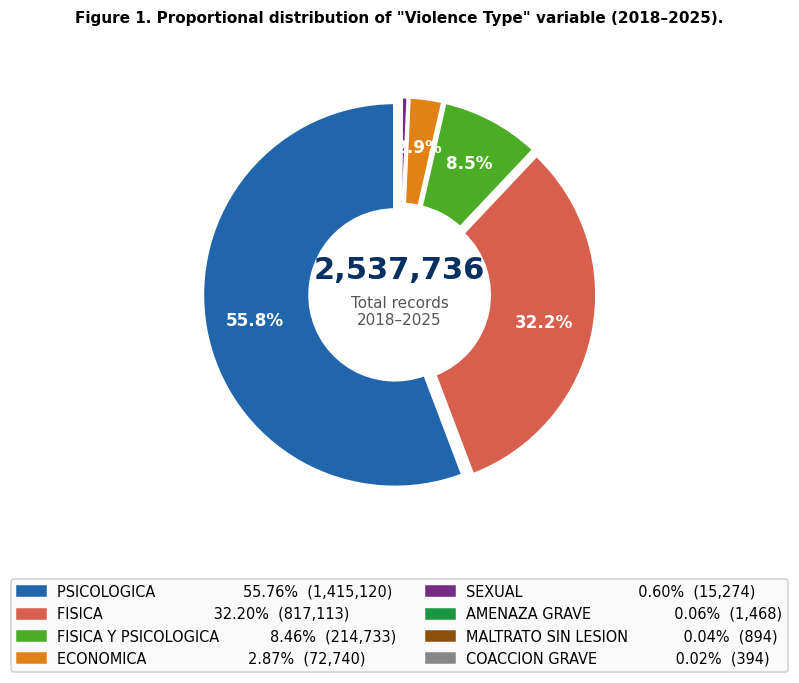

                        MODALIDAD   TOTAL       PCT
            VIOLENCIA PSICOLOGICA 1415120 55.763090
                 VIOLENCIA FISICA  817113 32.198503
   VIOLENCIA FISICA Y PSICOLOGICA  214733  8.461597
VIOLENCIA ECONOMICA O PATRIMONIAL   72740  2.866334
                 VIOLENCIA SEXUAL   15274  0.601875
                    AMENAZA GRAVE    1468  0.057847
              MALTRATO SIN LESION     894  0.035228
                   COACCION GRAVE     394  0.015526


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 1.2 — FIGURA 1: DONA MDPI PROFESIONAL
# ══════════════════════════════════════════════════════════════════════════════
modal_pl = (df.group_by('MODALIDAD')
              .agg(pl.col('CANTIDAD').sum().alias('TOTAL'))
              .sort('TOTAL', descending=True).to_pandas())
total_d  = modal_pl['TOTAL'].sum()
modal_pl['PCT'] = modal_pl['TOTAL'] / total_d * 100

# Registrar en Excel
registrar_excel('Distribution_Modalidad', modal_pl)

fig, ax = plt.subplots(figsize=(9, 6.5), facecolor='white')
wedges, _, autotexts = ax.pie(
    modal_pl['TOTAL'], colors=PALETTE_8[:len(modal_pl)],
    autopct=lambda p: f'{p:.1f}%' if p > 2 else '',
    startangle=90, pctdistance=0.74,
    wedgeprops=dict(width=0.56, edgecolor='white', linewidth=2.5),
    explode=[0.025]*len(modal_pl))
for at in autotexts:
    at.set_fontsize(11); at.set_fontweight('bold'); at.set_color('white')
ax.text(0, 0.08, f'{total_d:,}', ha='center', fontsize=20, fontweight='bold', color=MDPI_NAVY)
ax.text(0, -0.16, 'Total records\n2018–2025', ha='center', fontsize=10, color='#555')
leg = [mpatches.Patch(color=PALETTE_8[i],
       label=f'{modal_pl["MODALIDAD"].iloc[i].replace("VIOLENCIA ","").replace(" O PATRIMONIAL",""):28s}  '
             f'{modal_pl["PCT"].iloc[i]:5.2f}%  ({modal_pl["TOTAL"].iloc[i]:,})')
       for i in range(len(modal_pl))]
ax.legend(handles=leg, loc='lower center', bbox_to_anchor=(0.5,-0.30),
          ncol=2, fontsize=9.5, frameon=True, framealpha=0.92, edgecolor='#CCCCCC')
ax.set_title('Figure 1. Proportional distribution of "Violence Type" variable (2018–2025).',
             fontsize=10, fontweight='bold', pad=20)
plt.tight_layout()
guardar_fig(fig, 'fig01_dona_modalidad')
plt.show()
print(modal_pl[['MODALIDAD','TOTAL','PCT']].to_string(index=False))

Q1=1.0 | Q3=10.0 | IQR=9.0 | Upper=23.5
Outliers: 24,061 (12.74%)
  Fig saved: fig02_outliers_trend.png (300 DPI)


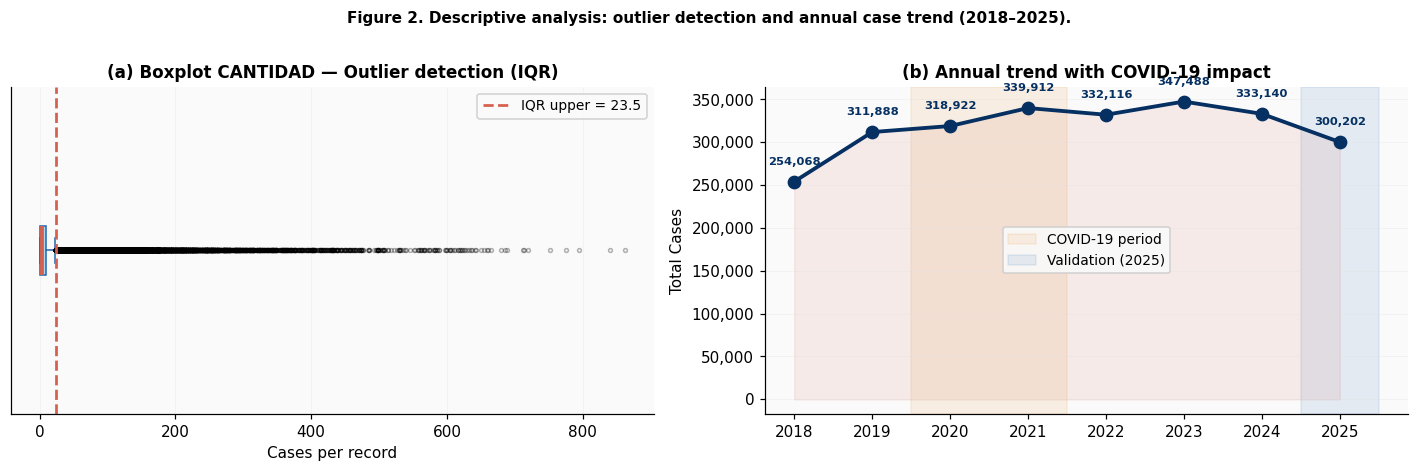

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 1.3 — FIGURA 2: OUTLIERS IQR + EVOLUCIÓN ANUAL
# ══════════════════════════════════════════════════════════════════════════════
q1 = df['CANTIDAD'].quantile(0.25)
q3 = df['CANTIDAD'].quantile(0.75)
lim_sup = q3 + 1.5*(q3-q1)
n_out   = df.filter(pl.col('CANTIDAD') > lim_sup).shape[0]
print(f'Q1={q1:.1f} | Q3={q3:.1f} | IQR={q3-q1:.1f} | Upper={lim_sup:.1f}')
print(f'Outliers: {n_out:,} ({n_out/df.shape[0]*100:.2f}%)')

# NOTA CRÍTICA: usar r['TOTAL'] con corchetes, NO r.T (que es la transpuesta en pandas)
anio_s = (df.group_by('ANIO')
            .agg(pl.col('CANTIDAD').sum().alias('TOTAL'))
            .sort('ANIO').to_pandas())
registrar_excel('Annual_Summary', anio_s)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), facecolor='white')

# Boxplot CANTIDAD
data_pd = df['CANTIDAD'].to_pandas()
axes[0].boxplot(data_pd, vert=False, patch_artist=True,
    boxprops=dict(facecolor='#AED6F1', color=MDPI_BLUE),
    medianprops=dict(color=MDPI_RED, linewidth=2.5),
    whiskerprops=dict(color=MDPI_BLUE), capprops=dict(color=MDPI_BLUE),
    flierprops=dict(marker='o', color=MDPI_RED, ms=2.5, alpha=0.3))
axes[0].axvline(lim_sup, color=MDPI_RED, ls='--', lw=1.8,
                label=f'IQR upper = {lim_sup:.1f}')
axes[0].set_xlabel('Cases per record', fontsize=10); axes[0].set_yticks([])
axes[0].legend(fontsize=9); axes[0].grid(axis='x', alpha=0.3)
axes[0].set_title('(a) Boxplot CANTIDAD — Outlier detection (IQR)', fontweight='bold')

# Evolución anual
axes[1].fill_between(anio_s['ANIO'], anio_s['TOTAL'], alpha=0.1, color=MDPI_RED)
axes[1].axvspan(2019.5,2021.5, alpha=0.1, color=MDPI_ORANGE, label='COVID-19 period')
axes[1].axvspan(2024.5,2025.5, alpha=0.1, color=MDPI_BLUE,   label='Validation (2025)')
axes[1].plot(anio_s['ANIO'], anio_s['TOTAL'], 'o-', color=MDPI_NAVY, lw=2.5, ms=8)
for _, r in anio_s.iterrows():
    axes[1].annotate(f'{int(r["TOTAL"]):,}',    # r['TOTAL'] NO r.T
                     (r['ANIO'], r['TOTAL']),
                     xytext=(0,11), textcoords='offset points',
                     ha='center', fontsize=7.5, fontweight='bold', color=MDPI_NAVY)
axes[1].set_xticks(anio_s['ANIO']); axes[1].set_ylabel('Total Cases', fontsize=10)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
axes[1].legend(fontsize=9); axes[1].grid(axis='y', alpha=0.3)
axes[1].set_title('(b) Annual trend with COVID-19 impact', fontweight='bold')

fig.suptitle('Figure 2. Descriptive analysis: outlier detection and annual case trend (2018–2025).',
             fontsize=10, fontweight='bold', y=1.01)
plt.tight_layout()
guardar_fig(fig, 'fig02_outliers_trend')
plt.show()

  Fig saved: fig03_heatmap_monthly.png (300 DPI)


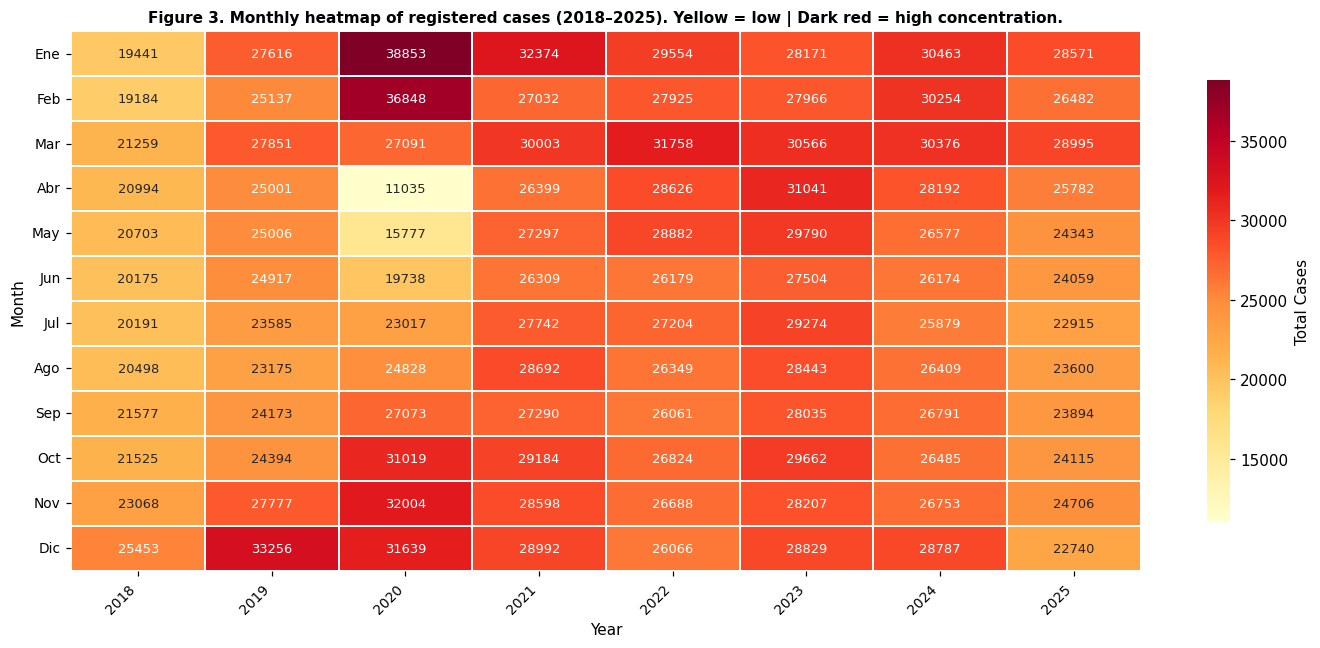

=== PEAK MONTH PER YEAR ===
  2018: PEAK → Dic (25,453) | MIN → Feb (19,184)
  2019: PEAK → Dic (33,256) | MIN → Ago (23,175)
  2020: PEAK → Ene (38,853) | MIN → Abr (11,035)
  2021: PEAK → Ene (32,374) | MIN → Jun (26,309)
  2022: PEAK → Mar (31,758) | MIN → Sep (26,061)
  2023: PEAK → Abr (31,041) | MIN → Jun (27,504)
  2024: PEAK → Ene (30,463) | MIN → Jul (25,879)
  2025: PEAK → Mar (28,995) | MIN → Dic (22,740)


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 1.4 — FIGURA 3: HEATMAP MES × AÑO
# ══════════════════════════════════════════════════════════════════════════════
mes_anio = (df.lazy().group_by(['ANIO','MES'])
              .agg(pl.col('CANTIDAD').sum().alias('TOTAL'))
              .sort(['ANIO','MES']).collect().to_pandas())
registrar_excel('Monthly_By_Year', mes_anio)

pivot_hm = mes_anio.pivot(index='MES', columns='ANIO', values='TOTAL').fillna(0)
pivot_hm.index = MESES_ES

fig, ax = plt.subplots(figsize=(13, 6), facecolor='white')
sns.heatmap(pivot_hm, cmap='YlOrRd', annot=True, fmt='.0f', linewidths=0.3,
            annot_kws={'size':8.5}, ax=ax,
            cbar_kws={'label':'Total Cases','shrink':0.82})
ax.set_xlabel('Year', fontsize=10); ax.set_ylabel('Month', fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
ax.set_title('Figure 3. Monthly heatmap of registered cases (2018–2025). '
             'Yellow = low | Dark red = high concentration.',
             fontsize=10, fontweight='bold')
plt.tight_layout()
guardar_fig(fig, 'fig03_heatmap_monthly')
plt.show()

# Tabla peak month por año
print('=== PEAK MONTH PER YEAR ===')
peak_data = []
for anio in sorted(pivot_hm.columns):
    col = pivot_hm[anio]
    peak_data.append({'Year':anio,'Peak_Month':col.idxmax(),
                      'Peak_Cases':int(col.max()),'Min_Month':col.idxmin(),
                      'Min_Cases':int(col.min())})
    print(f'  {anio}: PEAK → {col.idxmax()} ({int(col.max()):,}) | MIN → {col.idxmin()} ({int(col.min()):,})')
df_peak = pd.DataFrame(peak_data)
registrar_excel('Peak_Month_Per_Year', df_peak)

---
## SECCIÓN 2 — Feature Engineering + Selección + PCA Loadings

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 2.1 — FEATURE ENGINEERING (Polars lazy evaluation)
# ══════════════════════════════════════════════════════════════════════════════
t0 = time.time()
df_agg = (
    df.lazy()
    .group_by(['REGION','ANIO','MES','MODALIDAD'])
    .agg([
        pl.col('CANTIDAD').sum().alias('TOTAL_CASOS'),
        pl.col('CANTIDAD').count().alias('NUM_REGISTROS'),
        pl.col('CANTIDAD').mean().alias('PROM_CASOS'),
        pl.col('CANTIDAD').max().alias('MAX_CASOS'),
        pl.col('CANTIDAD').std().fill_null(0).alias('STD_CASOS'),
    ])
    .sort(['REGION','ANIO','MES'])
    .collect()
)
TIEMPOS_REALES['Feature_Engineering'] = round(time.time()-t0, 3)
print(f'Feature Engineering (Polars): {TIEMPOS_REALES["Feature_Engineering"]:.3f}s | Shape: {df_agg.shape}')
df_pd = df_agg.to_pandas()

Feature Engineering (Polars): 0.086s | Shape: (10396, 9)


╒═══════════════╤═══════════════╤════════════════╤════════╤══════════════╕
│ Variable      │   SelectKBest │   RandomForest │   SHAP │   Score_Comb │
╞═══════════════╪═══════════════╪════════════════╪════════╪══════════════╡
│ TOTAL_CASOS   │         0.169 │          1     │  1     │        0.723 │
├───────────────┼───────────────┼────────────────┼────────┼──────────────┤
│ NUM_REGISTROS │         1     │          0.381 │  0.271 │        0.551 │
├───────────────┼───────────────┼────────────────┼────────┼──────────────┤
│ MAX_CASOS     │         0.465 │          0.467 │  0.372 │        0.435 │
├───────────────┼───────────────┼────────────────┼────────┼──────────────┤
│ PROM_CASOS    │         0.211 │          0.27  │  0.213 │        0.231 │
├───────────────┼───────────────┼────────────────┼────────┼──────────────┤
│ MODALIDAD_ENC │         0.036 │          0.13  │  0.115 │        0.094 │
├───────────────┼───────────────┼────────────────┼────────┼──────────────┤
│ REGION_ENC    │        

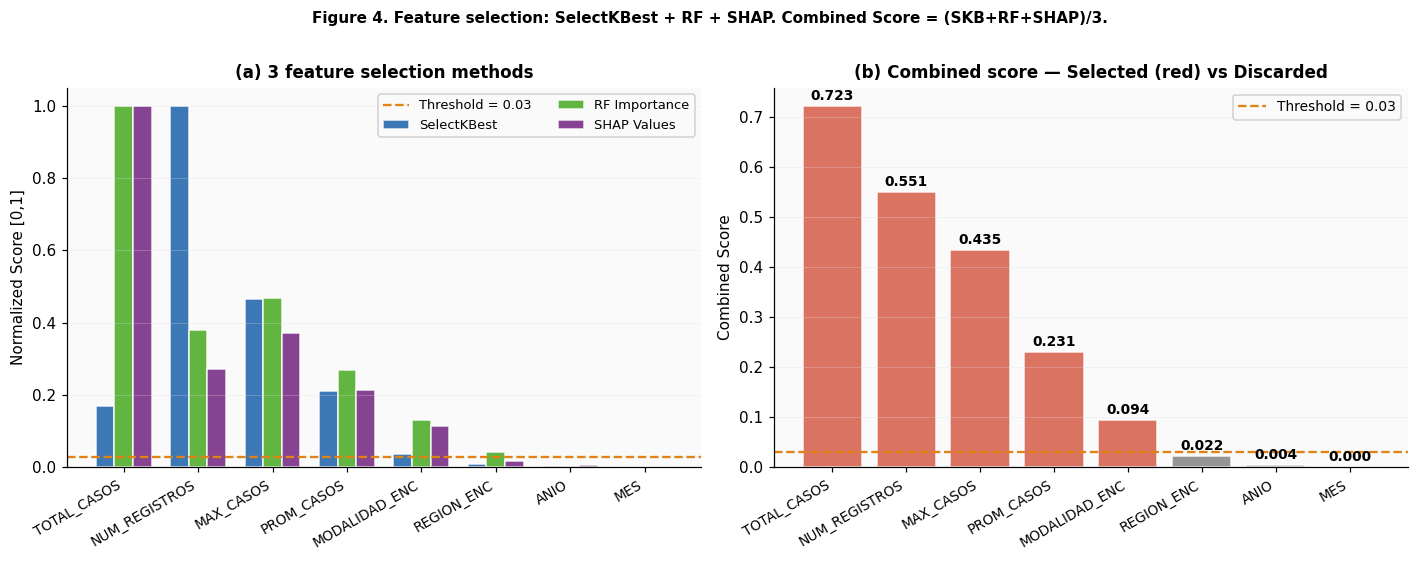

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 2.2 — SELECCIÓN DE VARIABLES: SelectKBest + RF + SHAP
# ══════════════════════════════════════════════════════════════════════════════

import os

# ── Corrección: función guardar_fig con creación automática de directorio ──
def guardar_fig(fig, nombre, output_dir='/content/drive/MyDrive/violencia_q2_output/figures', dpi=150):
    os.makedirs(output_dir, exist_ok=True)
    ruta = os.path.join(output_dir, f'{nombre}.png')
    fig.savefig(ruta, dpi=dpi, bbox_inches='tight')
    print(f'✔ Figura guardada: {ruta}')

# ─────────────────────────────────────────────────────────────────────────────

NUM_COLS = ['ANIO','MES','TOTAL_CASOS','NUM_REGISTROS','PROM_CASOS','MAX_CASOS']
CAT_COLS = ['REGION','MODALIDAD']

df_pd['TARGET']        = pd.qcut(df_pd['TOTAL_CASOS'], q=4, labels=[1,2,3,4]).astype(int)
le_reg = LabelEncoder(); le_mod = LabelEncoder()
df_pd['REGION_ENC']    = le_reg.fit_transform(df_pd['REGION'])
df_pd['MODALIDAD_ENC'] = le_mod.fit_transform(df_pd['MODALIDAD'])

FS_COLS = NUM_COLS + ['REGION_ENC','MODALIDAD_ENC']
X_fs = df_pd[FS_COLS].values
y_fs = df_pd['TARGET'].values

# (1) SelectKBest ANOVA F
skb = SelectKBest(score_func=f_classif, k='all')
skb.fit(X_fs, y_fs)
skb_s = pd.Series(skb.scores_, index=FS_COLS).fillna(0)
skb_n = (skb_s - skb_s.min()) / (skb_s.max() - skb_s.min() + 1e-9)

# (2) Random Forest Importance
rf_fs = RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1)
rf_fs.fit(X_fs, y_fs)
rf_s  = pd.Series(rf_fs.feature_importances_, index=FS_COLS)
rf_n  = (rf_s - rf_s.min()) / (rf_s.max() - rf_s.min() + 1e-9)

# (3) SHAP Values — versión robusta multiclase
exp = shap.TreeExplainer(rf_fs)
sv  = exp.shap_values(X_fs[:2000])
if isinstance(sv, list):
    sm = np.mean([np.abs(s).mean(0) for s in sv], 0)
elif sv.ndim == 3:
    sm = np.abs(sv).mean(0).mean(1)
else:
    sm = np.abs(sv).mean(0)
assert sm.ndim == 1 and len(sm) == len(FS_COLS), f'SHAP shape error: {sm.shape}'
shap_s = pd.Series(sm, index=FS_COLS)
shap_n = (shap_s - shap_s.min()) / (shap_s.max() - shap_s.min() + 1e-9)

# Score Combinado
df_fs = pd.DataFrame({
    'Variable':     FS_COLS,
    'SelectKBest':  skb_n.values.round(3),
    'RandomForest': rf_n.values.round(3),
    'SHAP':         shap_n.values.round(3)
})
df_fs['Score_Comb'] = ((df_fs['SelectKBest'] + df_fs['RandomForest'] + df_fs['SHAP']) / 3).round(3)
df_fs = df_fs.sort_values('Score_Comb', ascending=False).reset_index(drop=True)
registrar_excel('Feature_Selection', df_fs)
print(tabulate(df_fs, headers='keys', tablefmt='fancy_grid', showindex=False))

# FIGURA 4: Feature Selection
fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='white')
x = np.arange(len(df_fs))
w = 0.25

axes[0].bar(x - w, df_fs['SelectKBest'],  w, label='SelectKBest',  color=MDPI_BLUE,   edgecolor='white', alpha=0.88)
axes[0].bar(x,     df_fs['RandomForest'], w, label='RF Importance', color=MDPI_GREEN,  edgecolor='white', alpha=0.88)
axes[0].bar(x + w, df_fs['SHAP'],         w, label='SHAP Values',   color=MDPI_PURPLE, edgecolor='white', alpha=0.88)
axes[0].axhline(0.03, color=MDPI_ORANGE, ls='--', lw=1.5, label='Threshold = 0.03')
axes[0].set_xticks(x)
axes[0].set_xticklabels(df_fs['Variable'], rotation=30, ha='right', fontsize=9)
axes[0].set_ylabel('Normalized Score [0,1]', fontsize=10)
axes[0].set_title('(a) 3 feature selection methods', fontweight='bold')
axes[0].legend(fontsize=8.5, ncol=2)
axes[0].grid(axis='y', alpha=0.3)

colores_sc = [MDPI_RED if s >= 0.03 else MDPI_GRAY for s in df_fs['Score_Comb']]
bars = axes[1].bar(x, df_fs['Score_Comb'], color=colores_sc, edgecolor='white', alpha=0.88)
axes[1].axhline(0.03, color=MDPI_ORANGE, ls='--', lw=1.5, label='Threshold = 0.03')
axes[1].set_xticks(x)
axes[1].set_xticklabels(df_fs['Variable'], rotation=30, ha='right', fontsize=9)
axes[1].set_ylabel('Combined Score', fontsize=10)
axes[1].set_title('(b) Combined score — Selected (red) vs Discarded', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)
for bar, v in zip(bars, df_fs['Score_Comb']):
    axes[1].annotate(
        f'{v:.3f}',
        xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
        xytext=(0, 4), textcoords='offset points',
        ha='center', fontsize=9, fontweight='bold'
    )

fig.suptitle(
    'Figure 4. Feature selection: SelectKBest + RF + SHAP. Combined Score = (SKB+RF+SHAP)/3.',
    fontsize=10, fontweight='bold', y=1.01
)
plt.tight_layout()
guardar_fig(fig, 'fig04_feature_selection')
plt.show()

---
## SECCIÓN 3 — Split Temporal + Scaler + PCA con Loadings

Train (2018-2024):    9,224  (88.7%)
Val   (2025):         1,172  (11.3%)

PCA cumulative variance: 67.7% (PC1=50.9%, PC2=16.9%)

PCA Component Loadings:
╒═══════════════╤═══════════════╤═══════════════╕
│               │   PC1 (50.9%) │   PC2 (16.9%) │
╞═══════════════╪═══════════════╪═══════════════╡
│ ANIO          │        0.0794 │        0.676  │
├───────────────┼───────────────┼───────────────┤
│ MES           │        0.0034 │        0.7084 │
├───────────────┼───────────────┼───────────────┤
│ TOTAL_CASOS   │        0.5223 │       -0.0312 │
├───────────────┼───────────────┼───────────────┤
│ NUM_REGISTROS │        0.4406 │        0.1291 │
├───────────────┼───────────────┼───────────────┤
│ PROM_CASOS    │        0.4669 │       -0.1438 │
├───────────────┼───────────────┼───────────────┤
│ MAX_CASOS     │        0.5557 │       -0.0532 │
╘═══════════════╧═══════════════╧═══════════════╛
✔ Figura guardada: /content/drive/MyDrive/violencia_q2_output/figures/fig05_pca_loadings_biplot.

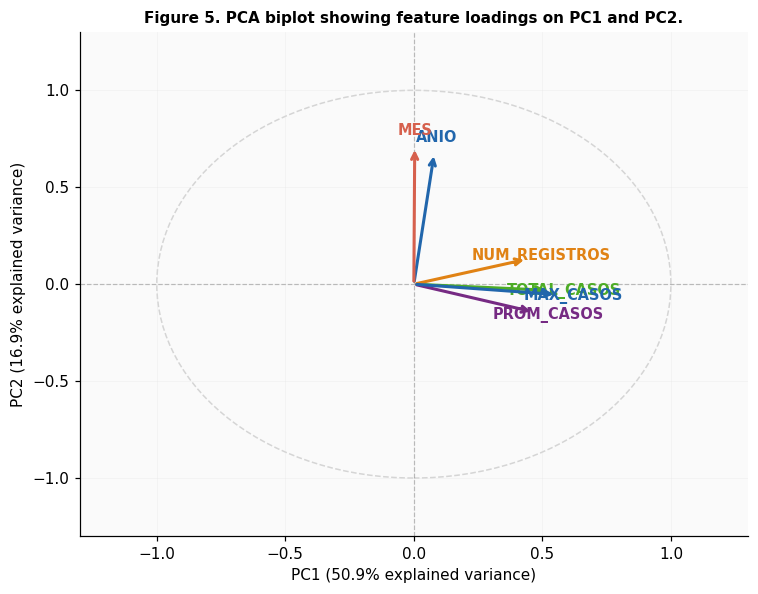

✅ Split + Scaler + PCA + Loadings OK


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 3 — SPLIT TEMPORAL + SCALER + PCA (con tabla de loadings — req. Q2)
# ══════════════════════════════════════════════════════════════════════════════
ANIO_CORTE = 2025
NUM_CLU    = ['ANIO','MES','TOTAL_CASOS','NUM_REGISTROS','PROM_CASOS','MAX_CASOS']
CAT_CLU    = ['REGION','MODALIDAD']

df_tr = df_pd[df_pd['ANIO'] < ANIO_CORTE].reset_index(drop=True)
df_va = df_pd[df_pd['ANIO'] >= ANIO_CORTE].reset_index(drop=True)

print(f'Train (2018-2024): {len(df_tr):>8,}  ({len(df_tr)/len(df_pd)*100:.1f}%)')
print(f'Val   (2025):      {len(df_va):>8,}  ({len(df_va)/len(df_pd)*100:.1f}%)')

# Regla crítica: fit SOLO en train → transform en val (sin data leakage)
scaler = StandardScaler()
X_tr   = scaler.fit_transform(df_tr[NUM_CLU].values)
X_va   = scaler.transform(df_va[NUM_CLU].values)

# PCA 2D — fit en train
pca    = PCA(n_components=2, random_state=RANDOM_SEED)
X_pca_tr = pca.fit_transform(X_tr)
X_pca_va = pca.transform(X_va)

# PCA 3D
pca3     = PCA(n_components=3, random_state=RANDOM_SEED)
X_pca3_tr = pca3.fit_transform(X_tr)

# ── TABLA DE LOADINGS (requerido Q2) ─────────────────────────────────────────
# Los loadings muestran qué variable domina cada componente principal
ev = pca.explained_variance_ratio_
loadings_df = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC1 ({ev[0]*100:.1f}%)', f'PC2 ({ev[1]*100:.1f}%)'],
    index=NUM_CLU
).round(4)
print(f'\nPCA cumulative variance: {ev.sum()*100:.1f}% (PC1={ev[0]*100:.1f}%, PC2={ev[1]*100:.1f}%)')
print('\nPCA Component Loadings:')
print(tabulate(loadings_df, headers='keys', tablefmt='fancy_grid'))
registrar_excel('PCA_Loadings', loadings_df.reset_index().rename(columns={'index':'Variable'}))

# FIGURA 5: PCA Loadings biplot
fig, ax = plt.subplots(figsize=(7, 5.5), facecolor='white')
for i, var in enumerate(NUM_CLU):
    ax.annotate('', xy=(pca.components_[0,i], pca.components_[1,i]),
                xytext=(0,0),
                arrowprops=dict(arrowstyle='->', color=PALETTE_5[i%5], lw=2))
    ax.text(pca.components_[0,i]*1.12, pca.components_[1,i]*1.12,
            var, fontsize=9.5, fontweight='bold', color=PALETTE_5[i%5],
            ha='center', va='center')
ax.axhline(0, color='gray', lw=0.8, ls='--', alpha=0.5)
ax.axvline(0, color='gray', lw=0.8, ls='--', alpha=0.5)
circle = plt.Circle((0,0), 1, color='gray', fill=False, ls='--', alpha=0.3)
ax.add_patch(circle)
ax.set_xlabel(f'PC1 ({ev[0]*100:.1f}% explained variance)', fontsize=10)
ax.set_ylabel(f'PC2 ({ev[1]*100:.1f}% explained variance)', fontsize=10)
ax.set_title('Figure 5. PCA biplot showing feature loadings on PC1 and PC2.',
             fontsize=10, fontweight='bold')
ax.set_xlim(-1.3,1.3); ax.set_ylim(-1.3,1.3)
ax.grid(True, alpha=0.25)
plt.tight_layout()
guardar_fig(fig, 'fig05_pca_loadings_biplot')
plt.show()
print('✅ Split + Scaler + PCA + Loadings OK')

---
## SECCIÓN 4 — Clustering No Supervisado (5 Modelos)
> ⚠️ Tiempos REALES con `time.time()`. Colab FREE: K-Means elbow ~3-8 min, K-Prototypes ~10-20 min.

K-Means Elbow (varios minutos en CPU)...
  k= 2 | Inertia=     40010.7 | Sil=0.6921
  k= 3 | Inertia=     30383.7 | Sil=0.3164
  k= 4 | Inertia=     25000.9 | Sil=0.2700
  k= 5 | Inertia=     21231.4 | Sil=0.2849
  k= 6 | Inertia=     17965.1 | Sil=0.2826
  k= 7 | Inertia=     16367.0 | Sil=0.2809
  k= 8 | Inertia=     14549.2 | Sil=0.2826
  k= 9 | Inertia=     13178.5 | Sil=0.2852
  k=10 | Inertia=     12044.0 | Sil=0.2950
Elbow: 12.1s (REAL) | Best k=2
╒═════════╤════════════════╤═════╤══════════════╤════════╤═════════╤═══════════╤══════════╕
│ Model   │ Set            │   k │   Silhouette │    DBI │     CHI │   Noise_% │   Time_s │
╞═════════╪════════════════╪═════╪══════════════╪════════╪═════════╪═══════════╪══════════╡
│ K-Means │ Train(2018-24) │   2 │       0.6921 │ 0.8047 │ 3534.14 │         0 │     0.04 │
├─────────┼────────────────┼─────┼──────────────┼────────┼─────────┼───────────┼──────────┤
│ K-Means │ Val(2025)      │   2 │       0.7394 │ 0.7651 │  647.02 │         0 │ 

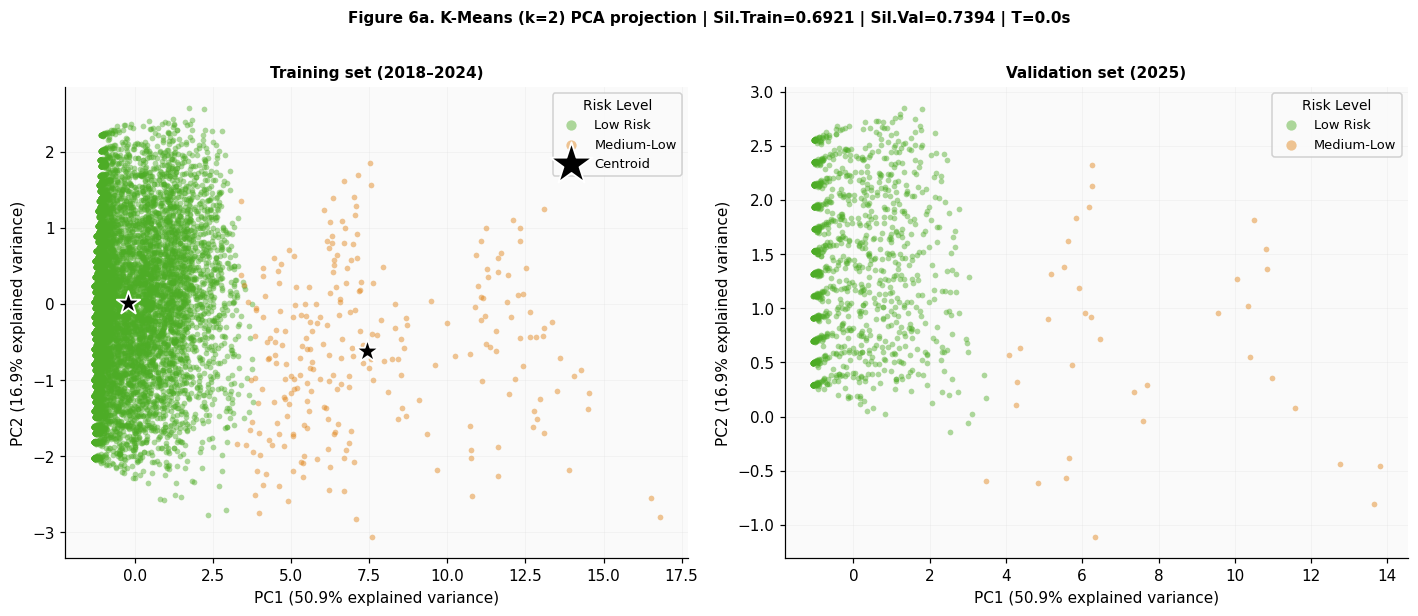

✔ Figura guardada: /content/drive/MyDrive/violencia_q2_output/figures/fig06b_pca3d_kmeans.png


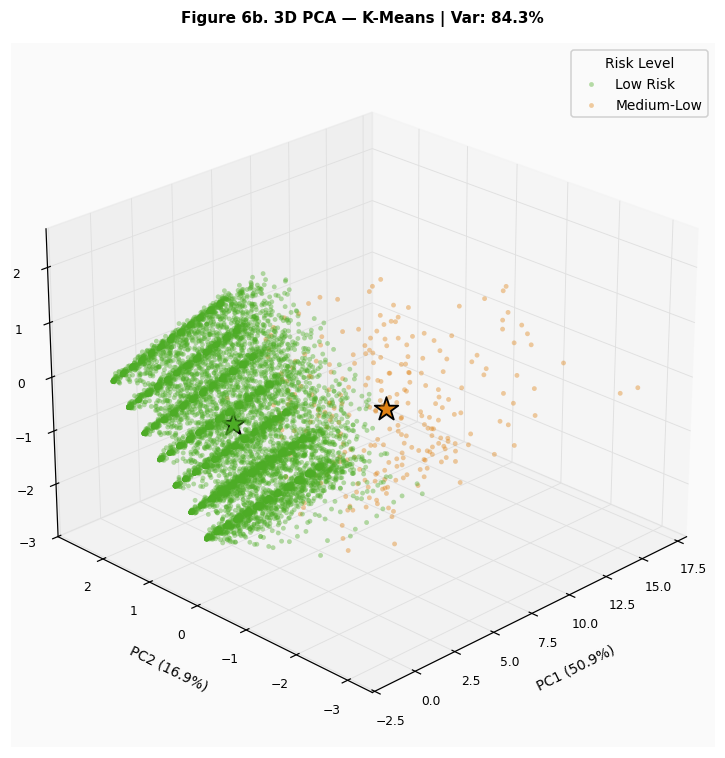

['/content/drive/MyDrive/violencia_q2_output/modelo_kmeans.pkl']

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 4.1 — K-MEANS (init='k-means++' → convergencia 3x más rápida)
# ══════════════════════════════════════════════════════════════════════════════
print('K-Means Elbow (varios minutos en CPU)...')
inercias_km, sils_km = [], []
t_e = time.time()
for k in range(2,11):
    km_t = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=RANDOM_SEED)
    km_t.fit(X_tr)
    inercias_km.append(km_t.inertia_)
    sils_km.append(silhouette_score(X_tr, km_t.labels_))
    print(f'  k={k:2d} | Inertia={km_t.inertia_:12.1f} | Sil={sils_km[-1]:.4f}')
t_elbow = time.time()-t_e
K_KM = sils_km.index(max(sils_km))+2
print(f'Elbow: {t_elbow:.1f}s (REAL) | Best k={K_KM}')

t0 = time.time()
modelo_km = KMeans(n_clusters=K_KM, init='k-means++', n_init=10, random_state=RANDOM_SEED)
modelo_km.fit(X_tr)
t_km = time.time()-t0
L_tr_km = modelo_km.labels_
L_va_km = modelo_km.predict(X_va)
TIEMPOS_REALES['KMeans_train'] = round(t_km, 2)

# Rank map por promedio de TOTAL_CASOS (para colores MDPI)
df_tr['cluster_km'] = L_tr_km
clu_means_km  = df_tr.groupby('cluster_km')['TOTAL_CASOS'].mean().sort_values()
rank_map_km   = {c:i for i,c in enumerate(clu_means_km.index)}
c_alto_km     = clu_means_km.index[-1]
df_va['cluster_km']  = L_va_km
df_va['alerta_km']   = np.where(df_va['cluster_km']==c_alto_km, 'HIGH', 'NORMAL')

m1 = calc_metricas(X_tr, L_tr_km, 'K-Means', 'Train(2018-24)', t_km)
m2 = calc_metricas(X_va, L_va_km, 'K-Means', 'Val(2025)',      0.0)
RESULTADOS_CLU.extend([m1, m2])
print(tabulate([m1,m2], headers='keys', tablefmt='fancy_grid'))
print(f'Time REAL: {t_km:.2f}s')

# PCA plot
plot_pca_mdpi(X_pca_tr, L_tr_km, X_pca_va, L_va_km,
    f'Figure 6a. K-Means (k={K_KM}) PCA projection | Sil.Train={m1["Silhouette"]} | Sil.Val={m2["Silhouette"]} | T={t_km:.1f}s',
    'fig06a_pca_kmeans', pca, rank_map_km, modelo_km.cluster_centers_)

# PCA 3D
cents_pca3 = pca3.transform(modelo_km.cluster_centers_)
ev3 = pca3.explained_variance_ratio_
fig = plt.figure(figsize=(9,7), facecolor='white')
ax3 = fig.add_subplot(111, projection='3d'); ax3.set_facecolor('#FAFAFA')
for lab in range(K_KM):
    mask3 = L_tr_km==lab; rank=rank_map_km[lab]
    ax3.scatter(X_pca3_tr[mask3,0],X_pca3_tr[mask3,1],X_pca3_tr[mask3,2],
                c=RANK_COLORS[rank],label=RANK_NAMES[rank],alpha=0.4,s=10,linewidths=0)
for i,(cx,cy,cz) in enumerate(cents_pca3):
    rank=rank_map_km[i]
    ax3.scatter(cx,cy,cz,c=RANK_COLORS[rank],s=260,marker='*',edgecolors='black',linewidths=1.2,zorder=5)
ax3.set_xlabel(f'PC1 ({ev3[0]*100:.1f}%)',fontsize=9,labelpad=8)
ax3.set_ylabel(f'PC2 ({ev3[1]*100:.1f}%)',fontsize=9,labelpad=8)
ax3.set_zlabel(f'PC3 ({ev3[2]*100:.1f}%)',fontsize=9,labelpad=8)
ax3.legend(fontsize=9,title='Risk Level',title_fontsize=9)
ax3.set_title(f'Figure 6b. 3D PCA — K-Means | Var: {ev3.sum()*100:.1f}%',fontsize=10,fontweight='bold',pad=14)
ax3.view_init(elev=25,azim=225); ax3.tick_params(labelsize=8)
plt.tight_layout()
guardar_fig(fig,'fig06b_pca3d_kmeans')
plt.show()
joblib.dump(modelo_km, f'{SALIDA}/modelo_kmeans.pkl')

GMM BIC...
  k=2 BIC=73,327.3
  k=3 BIC=48,505.5
  k=4 BIC=29,603.2
  k=5 BIC=3,985.8
  k=6 BIC=-3,682.5
  k=7 BIC=-7,536.2
  k=8 BIC=-6,615.6
  k=9 BIC=-10,600.3
BIC: 3.1s | Best k=9
╒═════════╤════════════════╤═════╤══════════════╤════════╤═════════╤═══════════╤══════════╕
│ Model   │ Set            │   k │   Silhouette │    DBI │     CHI │   Noise_% │   Time_s │
╞═════════╪════════════════╪═════╪══════════════╪════════╪═════════╪═══════════╪══════════╡
│ GMM     │ Train(2018-24) │   9 │       0.0594 │ 5.5606 │ 1714.77 │         0 │     0.42 │
├─────────┼────────────────┼─────┼──────────────┼────────┼─────────┼───────────┼──────────┤
│ GMM     │ Val(2025)      │   9 │       0.1079 │ 3.4429 │  406.65 │         0 │     0    │
╘═════════╧════════════════╧═════╧══════════════╧════════╧═════════╧═══════════╧══════════╛
Time REAL: 0.42s
✔ Figura guardada: /content/drive/MyDrive/violencia_q2_output/figures/fig07a_pca_gmm.png


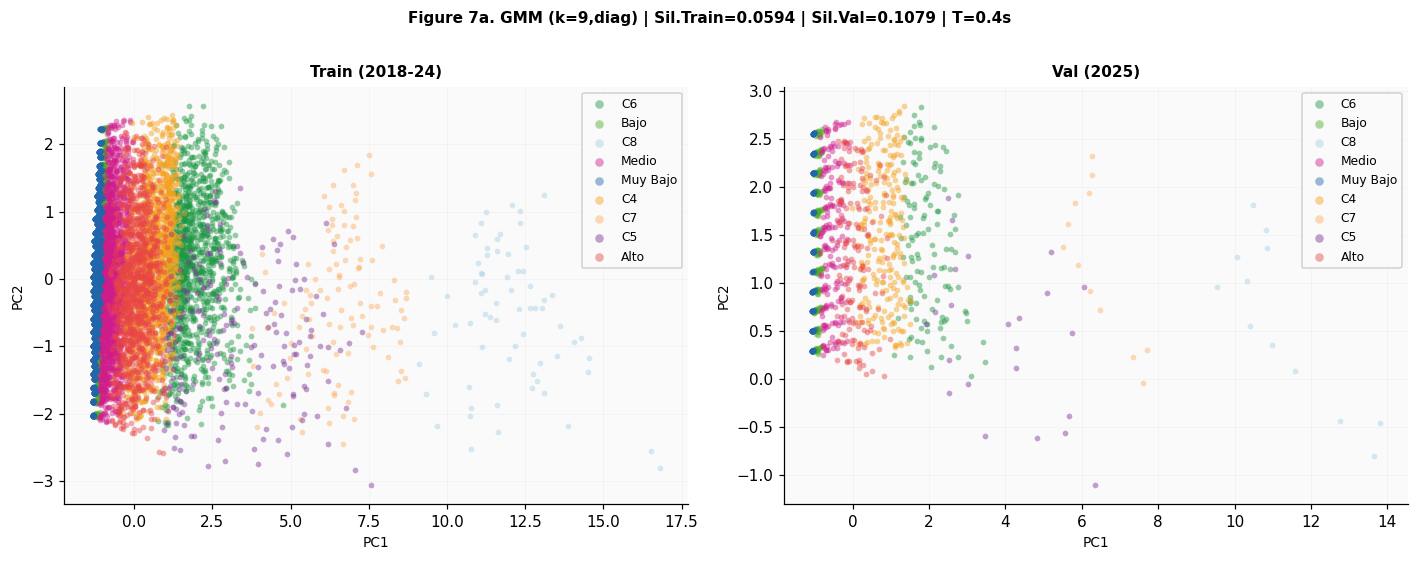

['/content/drive/MyDrive/violencia_q2_output/modelo_gmm.pkl']

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 4.2 — GMM (covariance='diag', BIC selection)
# ══════════════════════════════════════════════════════════════════════════════
# ══════════════════════════════════════════════════════════════════════════════
# CORRECCIÓN: paleta dinámica en plot_pca_mdpi (reemplaza tu definición actual)
# ══════════════════════════════════════════════════════════════════════════════

# Paleta extendida — soporta hasta 10 clusters sin IndexError
RANK_COLORS = [
    '#2166ac',  # 0 - azul
    '#4dac26',  # 1 - verde
    '#d01c8b',  # 2 - magenta
    '#e84545',  # 3 - rojo
    '#f4a11d',  # 4 - naranja
    '#7b3294',  # 5 - púrpura
    '#1a9641',  # 6 - verde oscuro
    '#fdae61',  # 7 - amarillo
    '#a6cee3',  # 8 - celeste
    '#b2df8a',  # 9 - verde claro
]
RANK_NAMES = {
    0: 'Muy Bajo', 1: 'Bajo', 2: 'Medio', 3: 'Alto',
    4: 'C4', 5: 'C5', 6: 'C6', 7: 'C7', 8: 'C8', 9: 'C9'
}

def plot_pca_mdpi(Xtr, Ltr, Xva, Lva, titulo, fname, pca_obj, rank_map_loc=None, cents=None):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='white')

    for ax, (X2, L, lbl) in zip(axes, [
        (Xtr, Ltr, 'Train (2018-24)'),
        (Xva, Lva, 'Val (2025)')
    ]):
        for lab in np.unique(L):
            mk   = L == lab
            # ── FIX: rank acotado al tamaño de RANK_COLORS ──────────────────
            rank = rank_map_loc[lab] if rank_map_loc else lab
            rank = rank % len(RANK_COLORS)          # nunca sale de rango
            # ────────────────────────────────────────────────────────────────
            ax.scatter(
                X2[mk, 0], X2[mk, 1],
                c=RANK_COLORS[rank],
                label=RANK_NAMES.get(rank, f'C{lab}'),
                alpha=0.45, s=14, linewidths=0, zorder=2
            )

        if cents is not None and lbl.startswith('Train'):
            cents2 = pca_obj.transform(cents)
            ax.scatter(cents2[:, 0], cents2[:, 1],
                       marker='*', s=180, c='black', zorder=5, label='Centroids')

        ax.set_title(lbl, fontweight='bold', fontsize=10)
        ax.set_xlabel('PC1', fontsize=9)
        ax.set_ylabel('PC2', fontsize=9)
        ax.legend(fontsize=8, markerscale=1.5)
        ax.grid(alpha=0.25)

    fig.suptitle(titulo, fontsize=10, fontweight='bold', y=1.01)
    plt.tight_layout()
    guardar_fig(fig, fname)
    plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 4.2 — GMM (covariance='diag', BIC selection)
# ══════════════════════════════════════════════════════════════════════════════
print('GMM BIC...')
bics = []; t0_b = time.time()
for k in range(2, 10):
    g = GaussianMixture(n_components=k, covariance_type='diag',
                        init_params='kmeans', random_state=RANDOM_SEED)
    g.fit(X_tr); bics.append(g.bic(X_tr))
    print(f'  k={k} BIC={bics[-1]:,.1f}')
K_GMM = bics.index(min(bics)) + 2
print(f'BIC: {time.time()-t0_b:.1f}s | Best k={K_GMM}')

t0 = time.time()
modelo_gmm = GaussianMixture(n_components=K_GMM, covariance_type='diag',
                              init_params='kmeans', random_state=RANDOM_SEED)
modelo_gmm.fit(X_tr); t_gmm = time.time() - t0
L_tr_gmm = modelo_gmm.predict(X_tr); L_va_gmm = modelo_gmm.predict(X_va)
TIEMPOS_REALES['GMM_train'] = round(t_gmm, 2)

df_tr['cluster_gmm'] = L_tr_gmm
clu_means_gmm = df_tr.groupby('cluster_gmm')['TOTAL_CASOS'].mean().sort_values()
rank_map_gmm  = {c: i for i, c in enumerate(clu_means_gmm.index)}
c_alto_gmm    = clu_means_gmm.index[-1]

df_va['cluster_gmm'] = L_va_gmm
df_va['alerta_gmm']  = np.where(df_va['cluster_gmm'] == c_alto_gmm, 'HIGH', 'NORMAL')

m3 = calc_metricas(X_tr, L_tr_gmm, 'GMM', 'Train(2018-24)', t_gmm)
m4 = calc_metricas(X_va, L_va_gmm, 'GMM', 'Val(2025)',      0.0)
RESULTADOS_CLU.extend([m3, m4])
print(tabulate([m3, m4], headers='keys', tablefmt='fancy_grid'))
print(f'Time REAL: {t_gmm:.2f}s')

plot_pca_mdpi(
    X_pca_tr, L_tr_gmm, X_pca_va, L_va_gmm,
    f'Figure 7a. GMM (k={K_GMM},diag) | Sil.Train={m3["Silhouette"]} | Sil.Val={m4["Silhouette"]} | T={t_gmm:.1f}s',
    'fig07a_pca_gmm', pca, rank_map_gmm
)
joblib.dump(modelo_gmm, f'{SALIDA}/modelo_gmm.pkl')

Agglomerative...
Graph: 0.1s
  k=2 Sil=0.7148
  k=3 Sil=0.2877
  k=4 Sil=0.3126
  k=5 Sil=0.2346
  k=6 Sil=0.2271
  k=7 Sil=0.2293
  k=8 Sil=0.2409
k search: 18.3s | Best k=2
╒═══════════════╤════════════════╤═════╤══════════════╤════════╤═════════╤═══════════╤══════════╕
│ Model         │ Set            │   k │   Silhouette │    DBI │     CHI │   Noise_% │   Time_s │
╞═══════════════╪════════════════╪═════╪══════════════╪════════╪═════════╪═══════════╪══════════╡
│ Agglomerative │ Train(2018-24) │   2 │       0.7148 │ 0.5497 │ 3150.91 │         0 │     1.26 │
├───────────────┼────────────────┼─────┼──────────────┼────────┼─────────┼───────────┼──────────┤
│ Agglomerative │ Val(2025)      │   2 │       0.7521 │ 0.5023 │  561.59 │         0 │     0    │
╘═══════════════╧════════════════╧═════╧══════════════╧════════╧═════════╧═══════════╧══════════╛
Time REAL: 1.26s
✔ Figura guardada: /content/drive/MyDrive/violencia_q2_output/figures/fig07b_pca_agglomerative.png


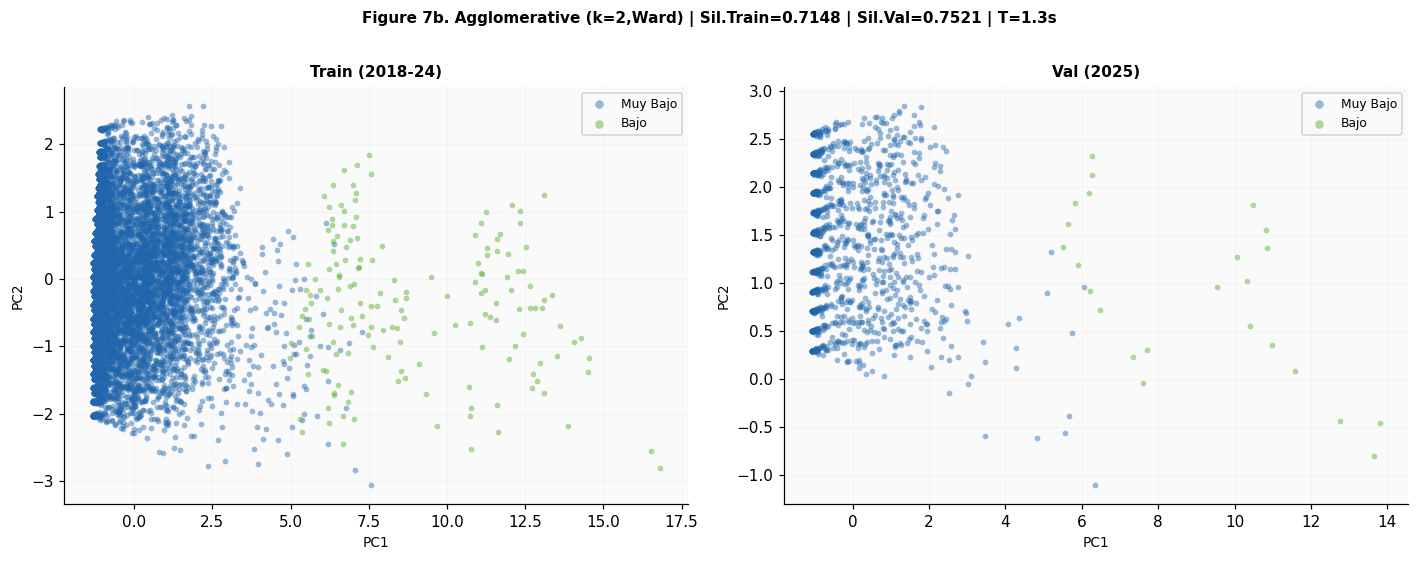

['/content/drive/MyDrive/violencia_q2_output/modelo_agglomerative_knn.pkl']

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 4.3 — AGGLOMERATIVE (Ward + kneighbors_graph)
# ══════════════════════════════════════════════════════════════════════════════
print('Agglomerative...')
t0=time.time(); conn=kneighbors_graph(X_tr,n_neighbors=15,include_self=False)
print(f'Graph: {time.time()-t0:.1f}s')

sils_agg=[]; t0_a=time.time()
for k in range(2,9):
    ag=AgglomerativeClustering(n_clusters=k,linkage='ward',connectivity=conn)
    ls=ag.fit_predict(X_tr); sils_agg.append(silhouette_score(X_tr,ls))
    print(f'  k={k} Sil={sils_agg[-1]:.4f}')
K_AGG=sils_agg.index(max(sils_agg))+2
print(f'k search: {time.time()-t0_a:.1f}s | Best k={K_AGG}')

t0=time.time()
modelo_agg=AgglomerativeClustering(n_clusters=K_AGG,linkage='ward',connectivity=conn)
L_tr_agg=modelo_agg.fit_predict(X_tr); t_agg=time.time()-t0
knn_agg=KNeighborsClassifier(n_neighbors=1)
knn_agg.fit(X_tr,L_tr_agg)
L_va_agg=knn_agg.predict(X_va)
TIEMPOS_REALES['Agglomerative_train']=round(t_agg,2)

df_tr['cluster_agg']=L_tr_agg
clu_means_agg=df_tr.groupby('cluster_agg')['TOTAL_CASOS'].mean().sort_values()
rank_map_agg={c:i for i,c in enumerate(clu_means_agg.index)}
c_alto_agg=clu_means_agg.index[-1]
df_va['cluster_agg']=L_va_agg
df_va['alerta_agg']=np.where(df_va['cluster_agg']==c_alto_agg,'HIGH','NORMAL')

m5=calc_metricas(X_tr,L_tr_agg,'Agglomerative','Train(2018-24)',t_agg)
m6=calc_metricas(X_va,L_va_agg,'Agglomerative','Val(2025)',     0.0)
RESULTADOS_CLU.extend([m5,m6])
print(tabulate([m5,m6],headers='keys',tablefmt='fancy_grid'))
print(f'Time REAL: {t_agg:.2f}s')
plot_pca_mdpi(X_pca_tr,L_tr_agg,X_pca_va,L_va_agg,
    f'Figure 7b. Agglomerative (k={K_AGG},Ward) | Sil.Train={m5["Silhouette"]} | Sil.Val={m6["Silhouette"]} | T={t_agg:.1f}s',
    'fig07b_pca_agglomerative',pca,rank_map_agg)
joblib.dump(knn_agg,f'{SALIDA}/modelo_agglomerative_knn.pkl')

DBSCAN experiments...
Experiments: 17.5s
╒═══════╤═════════╤═══════════╤═══════════╤═══════════╤═════════╕
│   eps │   min_s │   n_clust │   n_noise │   noise_% │ Sil     │
╞═══════╪═════════╪═══════════╪═══════════╪═══════════╪═════════╡
│   0.3 │       5 │        84 │      3404 │     36.9  │ -0.133  │
├───────┼─────────┼───────────┼───────────┼───────────┼─────────┤
│   0.3 │      10 │         9 │      4349 │     47.15 │ 0.063   │
├───────┼─────────┼───────────┼───────────┼───────────┼─────────┤
│   0.3 │      20 │         7 │      4851 │     52.59 │ 0.1024  │
├───────┼─────────┼───────────┼───────────┼───────────┼─────────┤
│   0.5 │       5 │        22 │       917 │      9.94 │ 0.018   │
├───────┼─────────┼───────────┼───────────┼───────────┼─────────┤
│   0.5 │      10 │         6 │      1447 │     15.69 │ 0.0487  │
├───────┼─────────┼───────────┼───────────┼───────────┼─────────┤
│   0.5 │      20 │         7 │      2570 │     27.86 │ -0.1185 │
├───────┼─────────┼───────────┼────

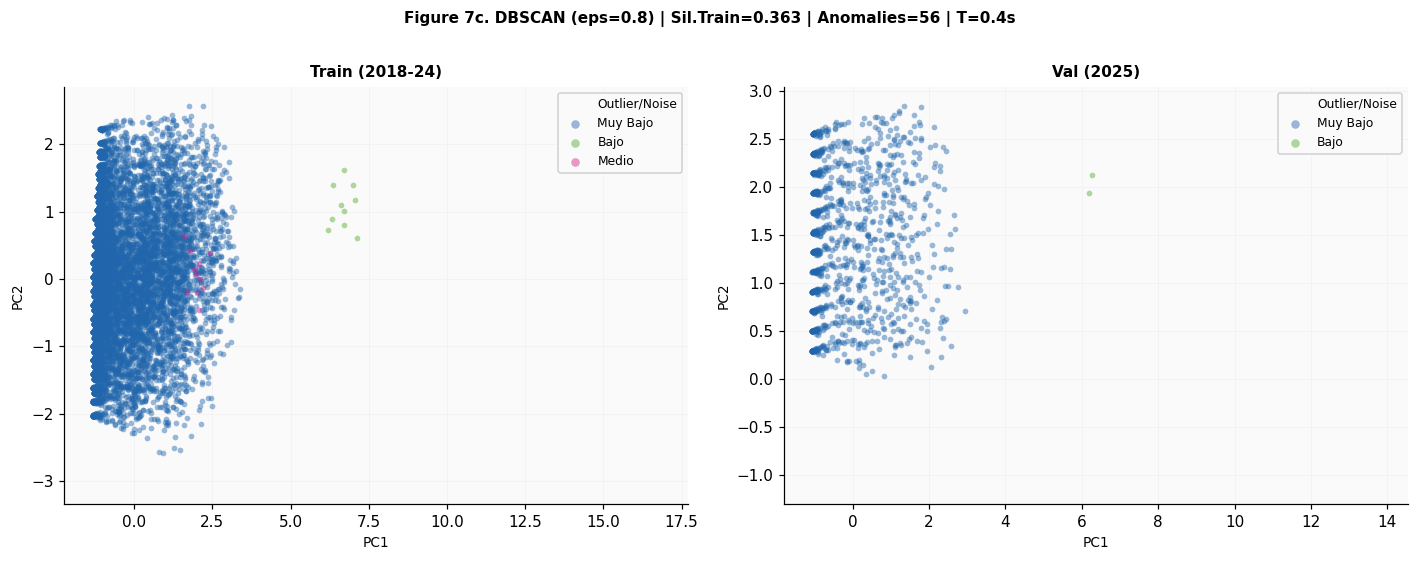

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 4.4 — DBSCAN (ball_tree + K-Distance + experimentos)
# ══════════════════════════════════════════════════════════════════════════════
def plot_pca_mdpi(Xtr, Ltr, Xva, Lva, titulo, fname, pca_obj, rank_map_loc=None, cents=None):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='white')

    for ax, (X2, L, lbl) in zip(axes, [
        (Xtr, Ltr, 'Train (2018-24)'),
        (Xva, Lva, 'Val (2025)')
    ]):
        for lab in np.unique(L):
            mk = L == lab

            # ── FIX: outliers DBSCAN (lab == -1) ────────────────────────────
            if lab == -1:
                ax.scatter(X2[mk, 0], X2[mk, 1],
                           c='#aaaaaa', label='Outlier/Noise',
                           alpha=0.30, s=10, linewidths=0, zorder=1,
                           marker='x')
                continue
            # ────────────────────────────────────────────────────────────────

            rank = rank_map_loc[lab] if rank_map_loc else lab
            rank = rank % len(RANK_COLORS)
            ax.scatter(
                X2[mk, 0], X2[mk, 1],
                c=RANK_COLORS[rank],
                label=RANK_NAMES.get(rank, f'C{lab}'),
                alpha=0.45, s=14, linewidths=0, zorder=2
            )

        if cents is not None and lbl.startswith('Train'):
            cents2 = pca_obj.transform(cents)
            ax.scatter(cents2[:, 0], cents2[:, 1],
                       marker='*', s=180, c='black', zorder=5, label='Centroids')

        ax.set_title(lbl, fontweight='bold', fontsize=10)
        ax.set_xlabel('PC1', fontsize=9)
        ax.set_ylabel('PC2', fontsize=9)
        ax.legend(fontsize=8, markerscale=1.5)
        ax.grid(alpha=0.25)

    fig.suptitle(titulo, fontsize=10, fontweight='bold', y=1.01)
    plt.tight_layout()
    guardar_fig(fig, fname)
    plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 4.4 — DBSCAN (ball_tree + K-Distance + experimentos)
# ══════════════════════════════════════════════════════════════════════════════
print('DBSCAN experiments...')
exp_db = []; t0_exp = time.time()
for eps in [0.3, 0.5, 0.8, 1.0, 1.5]:
    for ms in [5, 10, 20]:
        db_t = DBSCAN(eps=eps, min_samples=ms, algorithm='ball_tree')
        ls_t = db_t.fit_predict(X_tr)
        nc   = len(set(ls_t)) - (1 if -1 in ls_t else 0)
        nr   = (ls_t == -1).sum()
        sil  = silhouette_score(X_tr[ls_t != -1], ls_t[ls_t != -1]) if nc >= 2 else float('nan')
        exp_db.append({'eps': eps, 'min_s': ms, 'n_clust': nc, 'n_noise': nr,
                       'noise_%': round(nr / len(ls_t) * 100, 2),
                       'Sil': round(sil, 4) if not np.isnan(sil) else 'N/A'})

df_exp_db = pd.DataFrame(exp_db)
registrar_excel('DBSCAN_Experiments', df_exp_db)
print(f'Experiments: {time.time()-t0_exp:.1f}s')
print(tabulate(df_exp_db, headers='keys', tablefmt='fancy_grid', showindex=False))

# Ajustar según la tabla de arriba
EPS_DB = 0.8; MINS_DB = 10
t0 = time.time()
modelo_db  = DBSCAN(eps=EPS_DB, min_samples=MINS_DB, algorithm='ball_tree')
L_tr_db    = modelo_db.fit_predict(X_tr); t_db = time.time() - t0
nbrs_db    = NearestNeighbors(n_neighbors=1, algorithm='ball_tree').fit(X_tr)
dv, iv     = nbrs_db.kneighbors(X_va)
L_va_db    = np.array([L_tr_db[i[0]] if d[0] <= EPS_DB else -1 for d, i in zip(dv, iv)])
TIEMPOS_REALES['DBSCAN_train'] = round(t_db, 2)

df_tr['cluster_db'] = L_tr_db
df_va['cluster_db'] = L_va_db
df_outliers = df_va[df_va['cluster_db'] == -1].copy()
registrar_excel('Anomalies_DBSCAN_2025',
                df_outliers.sort_values('TOTAL_CASOS', ascending=False))

m7 = calc_metricas(X_tr, L_tr_db, 'DBSCAN', 'Train(2018-24)', t_db)
m8 = calc_metricas(X_va, L_va_db, 'DBSCAN', 'Val(2025)',      0.0)
RESULTADOS_CLU.extend([m7, m8])
print(tabulate([m7, m8], headers='keys', tablefmt='fancy_grid'))
print(f'Time REAL: {t_db:.2f}s | Anomalies 2025: {len(df_outliers):,}')

# ── FIX: rank_map_db no necesita incluir -1; plot_pca_mdpi ya lo maneja ──
rank_map_db = {c: i % len(RANK_COLORS)
               for i, c in enumerate(sorted([x for x in set(L_tr_db) if x != -1]))}

plot_pca_mdpi(
    X_pca_tr, L_tr_db, X_pca_va, L_va_db,
    f'Figure 7c. DBSCAN (eps={EPS_DB}) | Sil.Train={m7["Silhouette"]} | Anomalies={len(df_outliers)} | T={t_db:.1f}s',
    'fig07c_pca_dbscan', pca, rank_map_db
)

K-Prototypes (puede tardar varios minutos)...
  k=2 cost=47397.34
  k=3 cost=37547.64
  k=4 cost=32261.00
  k=5 cost=28428.12
  k=6 cost=25191.05
  k=7 cost=23271.68
Elbow: 493.4s
╒══════════════╤════════════════╤═════╤══════════════╤════════╤═════════╤═══════════╤══════════╕
│ Model        │ Set            │   k │   Silhouette │    DBI │     CHI │   Noise_% │   Time_s │
╞══════════════╪════════════════╪═════╪══════════════╪════════╪═════════╪═══════════╪══════════╡
│ K-Prototypes │ Train(2018-24) │   4 │       0.2687 │ 1.2092 │ 3724.44 │         0 │    68.55 │
├──────────────┼────────────────┼─────┼──────────────┼────────┼─────────┼───────────┼──────────┤
│ K-Prototypes │ Val(2025)      │   3 │       0.401  │ 1.047  │  689.65 │         0 │     0    │
╘══════════════╧════════════════╧═════╧══════════════╧════════╧═════════╧═══════════╧══════════╛
Time REAL: 68.55s
✔ Figura guardada: /content/drive/MyDrive/violencia_q2_output/figures/fig07d_pca_kprototypes.png


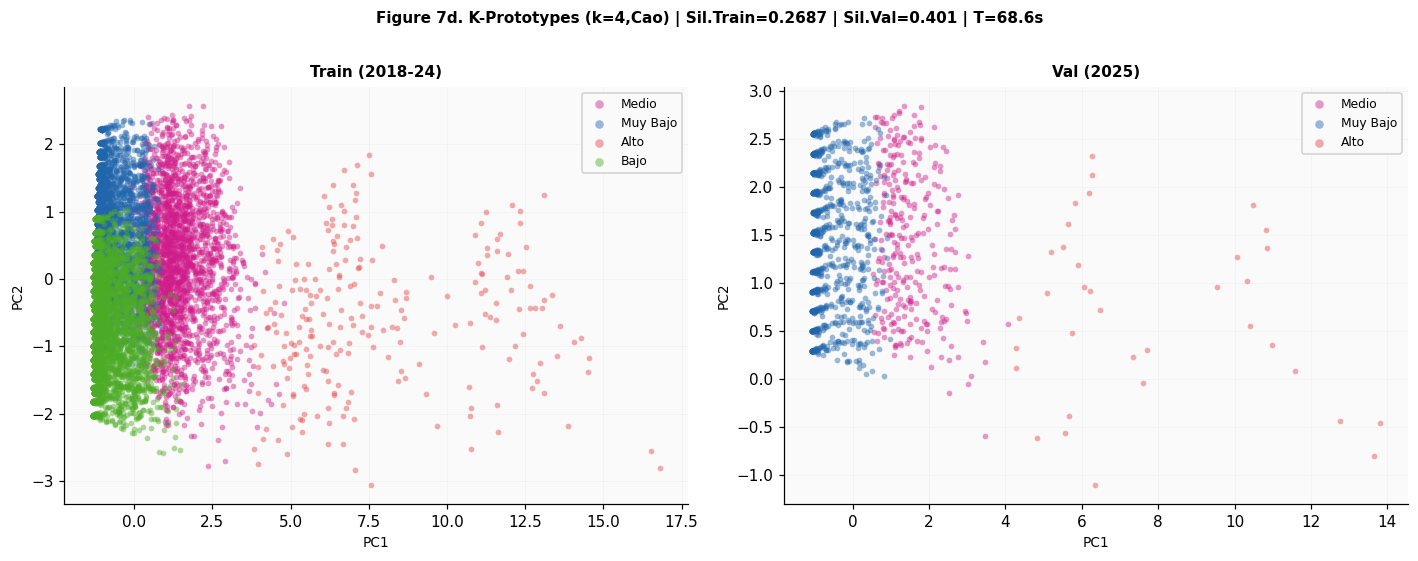

['/content/drive/MyDrive/violencia_q2_output/scaler_kprototypes.pkl']

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 4.5 — K-PROTOTYPES (init='Cao', datos mixtos num+cat)
# ══════════════════════════════════════════════════════════════════════════════
print('K-Prototypes (puede tardar varios minutos)...')
scaler_kp=StandardScaler()
df_tr_kp=df_tr.copy(); df_va_kp=df_va.copy()
df_tr_kp[NUM_CLU]=scaler_kp.fit_transform(df_tr_kp[NUM_CLU])
df_va_kp[NUM_CLU]=scaler_kp.transform(df_va_kp[NUM_CLU])
COLS_KP=NUM_CLU+CAT_CLU
X_tr_kp=df_tr_kp[COLS_KP].to_numpy(); X_va_kp=df_va_kp[COLS_KP].to_numpy()
CAT_IDX=list(range(len(NUM_CLU),len(COLS_KP)))

costos_kp=[]; t0_ke=time.time()
for k in range(2,8):
    kp_t=KPrototypes(n_clusters=k,init='Cao',random_state=RANDOM_SEED)
    kp_t.fit_predict(X_tr_kp,categorical=CAT_IDX)
    costos_kp.append(kp_t.cost_); print(f'  k={k} cost={kp_t.cost_:.2f}')
print(f'Elbow: {time.time()-t0_ke:.1f}s')

K_KP=4  # Ajustar según el codo visual del gráfico de costos
t0=time.time()
modelo_kp=KPrototypes(n_clusters=K_KP,init='Cao',random_state=RANDOM_SEED)
L_tr_kp=modelo_kp.fit_predict(X_tr_kp,categorical=CAT_IDX); t_kp=time.time()-t0
L_va_kp=modelo_kp.predict(X_va_kp,categorical=CAT_IDX)
TIEMPOS_REALES['KPrototypes_train']=round(t_kp,2)

X_num_tr_kp=X_tr_kp[:,:len(NUM_CLU)].astype(float)
X_num_va_kp=X_va_kp[:,:len(NUM_CLU)].astype(float)
df_tr['cluster_kp']=L_tr_kp
clu_means_kp=df_tr.groupby('cluster_kp')['TOTAL_CASOS'].mean().sort_values()
rank_map_kp={c:i for i,c in enumerate(clu_means_kp.index)}
c_alto_kp=clu_means_kp.index[-1]
df_va['cluster_kp']=L_va_kp
df_va['alerta_kp']=np.where(df_va['cluster_kp']==c_alto_kp,'HIGH','NORMAL')

m9 =calc_metricas(X_num_tr_kp,L_tr_kp,'K-Prototypes','Train(2018-24)',t_kp)
m10=calc_metricas(X_num_va_kp,L_va_kp,'K-Prototypes','Val(2025)',     0.0)
RESULTADOS_CLU.extend([m9,m10])
print(tabulate([m9,m10],headers='keys',tablefmt='fancy_grid'))
print(f'Time REAL: {t_kp:.2f}s')

pca_kp=PCA(n_components=2,random_state=RANDOM_SEED)
plot_pca_mdpi(pca_kp.fit_transform(X_num_tr_kp),L_tr_kp,
              pca_kp.transform(X_num_va_kp),L_va_kp,
    f'Figure 7d. K-Prototypes (k={K_KP},Cao) | Sil.Train={m9["Silhouette"]} | Sil.Val={m10["Silhouette"]} | T={t_kp:.1f}s',
    'fig07d_pca_kprototypes',pca_kp,rank_map_kp)
joblib.dump(modelo_kp,f'{SALIDA}/modelo_kprototypes.pkl')
joblib.dump(scaler_kp,f'{SALIDA}/scaler_kprototypes.pkl')

---
## SECCIÓN 5 — Comparación + Métricas MDPI + Kruskal-Wallis + Dunn + Bootstrap CI

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 5.1 — BOOTSTRAP IC 95% SILHOUETTE (requerido Q2)
# 500 iteraciones bootstrap para estimar el intervalo de confianza
# ══════════════════════════════════════════════════════════════════════════════
print('Bootstrap Silhouette CI 95% (500 iterations)...')
boot_results = []
for mod_name, X_b, L_b in [
    ('K-Means',       X_tr, L_tr_km),
    ('GMM',           X_tr, L_tr_gmm),
    ('Agglomerative', X_tr, L_tr_agg),
    ('K-Prototypes',  X_num_tr_kp, L_tr_kp),
]:
    mean_sil, ci_lo, ci_hi = bootstrap_silhouette(X_b, L_b, n_boot=500)
    boot_results.append({'Model':mod_name,
                          'Sil_mean':round(mean_sil,4),
                          'CI_95_low':round(ci_lo,4),
                          'CI_95_high':round(ci_hi,4),
                          'CI_width':round(ci_hi-ci_lo,4)})
    print(f'  {mod_name:<15} Sil={mean_sil:.4f}  95%CI=[{ci_lo:.4f}, {ci_hi:.4f}]')

# DBSCAN: métricas solo en puntos no-ruido
mask_db = L_tr_db!=-1
if mask_db.sum()>10:
    mean_sil_db, ci_lo_db, ci_hi_db = bootstrap_silhouette(X_tr[mask_db], L_tr_db[mask_db], n_boot=500)
    boot_results.append({'Model':'DBSCAN (no noise)',
                          'Sil_mean':round(mean_sil_db,4),
                          'CI_95_low':round(ci_lo_db,4),
                          'CI_95_high':round(ci_hi_db,4),
                          'CI_width':round(ci_hi_db-ci_lo_db,4)})
    print(f'  {"DBSCAN (no noise)":<15} Sil={mean_sil_db:.4f}  95%CI=[{ci_lo_db:.4f}, {ci_hi_db:.4f}]')

df_boot = pd.DataFrame(boot_results)
registrar_excel('Bootstrap_CI_95', df_boot)
print(tabulate(df_boot, headers='keys', tablefmt='fancy_grid', showindex=False))

Bootstrap Silhouette CI 95% (500 iterations)...
  K-Means         Sil=0.6917  95%CI=[0.6803, 0.7023]
  GMM             Sil=0.0600  95%CI=[0.0569, 0.0629]
  Agglomerative   Sil=0.7143  95%CI=[0.7011, 0.7265]
  K-Prototypes    Sil=0.2691  95%CI=[0.2646, 0.2739]
  DBSCAN (no noise) Sil=0.3628  95%CI=[0.3346, 0.3908]
╒═══════════════════╤════════════╤═════════════╤══════════════╤════════════╕
│ Model             │   Sil_mean │   CI_95_low │   CI_95_high │   CI_width │
╞═══════════════════╪════════════╪═════════════╪══════════════╪════════════╡
│ K-Means           │     0.6917 │      0.6803 │       0.7023 │     0.0219 │
├───────────────────┼────────────┼─────────────┼──────────────┼────────────┤
│ GMM               │     0.06   │      0.0569 │       0.0629 │     0.0061 │
├───────────────────┼────────────┼─────────────┼──────────────┼────────────┤
│ Agglomerative     │     0.7143 │      0.7011 │       0.7265 │     0.0254 │
├───────────────────┼────────────┼─────────────┼──────────────┼──────

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 5.2 — KRUSKAL-WALLIS + TEST POST-HOC DE DUNN (requerido Q2)
# Bonferroni correction para comparaciones múltiples
# ══════════════════════════════════════════════════════════════════════════════
# Filtrar clusters con datos (evitar ValueError en violinplot)
cluster_data_raw = [df_tr[df_tr['cluster_km'].map(rank_map_km)==r]['TOTAL_CASOS'].values
                    for r in range(4)]
clusters_validos  = [i for i,d in enumerate(cluster_data_raw) if len(d)>0]
cluster_data      = [cluster_data_raw[i] for i in clusters_validos]
rank_names_val    = [f'Cluster {i}\n({RANK_NAMES[i]})' for i in clusters_validos]
rank_colors_val   = [RANK_COLORS[i] for i in clusters_validos]
print(f'Clusters with data: {clusters_validos} | Sizes: {[len(d) for d in cluster_data]}')

# Kruskal-Wallis
stat_h, pval_h = stats.kruskal(*cluster_data)
print(f'Kruskal-Wallis: H={stat_h:.4f}, p={pval_h:.2e}')

# Test post-hoc de Dunn con corrección Bonferroni
# Creamos un DataFrame largo para scikit_posthocs
df_long = pd.concat([
    pd.DataFrame({'value': d, 'group': RANK_NAMES.get(clusters_validos[i], str(i))})
    for i, d in enumerate(cluster_data)
], ignore_index=True)

dunn_result = sp.posthoc_dunn(
    df_long, val_col='value', group_col='group', p_adjust='bonferroni'
)
registrar_excel('Dunn_PostHoc_Bonferroni', dunn_result.round(4).reset_index())
print('\nDunn post-hoc test (Bonferroni correction) p-values:')
print(dunn_result.round(4))
print('\nSignificant pairs (p < 0.05):')
for i in range(len(dunn_result)):
    for j in range(i+1, len(dunn_result)):
        pv = dunn_result.iloc[i,j]
        sig = '***' if pv<0.001 else ('**' if pv<0.01 else ('*' if pv<0.05 else 'ns'))
        print(f'  {dunn_result.index[i]} vs {dunn_result.columns[j]}: p={pv:.4f} {sig}')

Clusters with data: [0, 1] | Sizes: [8966, 258]
Kruskal-Wallis: H=680.7760, p=4.53e-150

Dunn post-hoc test (Bonferroni correction) p-values:
          Bajo  Muy Bajo
Bajo       1.0       0.0
Muy Bajo   0.0       1.0

Significant pairs (p < 0.05):
  Bajo vs Muy Bajo: p=0.0000 ***


╒═══════════════╤════════════════╤═════╤══════════════╤════════╤═════════╤═══════════╤══════════╕
│ Model         │ Set            │   k │   Silhouette │    DBI │     CHI │   Noise_% │   Time_s │
╞═══════════════╪════════════════╪═════╪══════════════╪════════╪═════════╪═══════════╪══════════╡
│ K-Means       │ Train(2018-24) │   2 │       0.6921 │ 0.8047 │ 3534.14 │      0    │     0.04 │
├───────────────┼────────────────┼─────┼──────────────┼────────┼─────────┼───────────┼──────────┤
│ K-Means       │ Val(2025)      │   2 │       0.7394 │ 0.7651 │  647.02 │      0    │     0    │
├───────────────┼────────────────┼─────┼──────────────┼────────┼─────────┼───────────┼──────────┤
│ GMM           │ Train(2018-24) │   9 │       0.0594 │ 5.5606 │ 1714.77 │      0    │     0.42 │
├───────────────┼────────────────┼─────┼──────────────┼────────┼─────────┼───────────┼──────────┤
│ GMM           │ Val(2025)      │   9 │       0.1079 │ 3.4429 │  406.65 │      0    │     0    │
├───────────────┼───

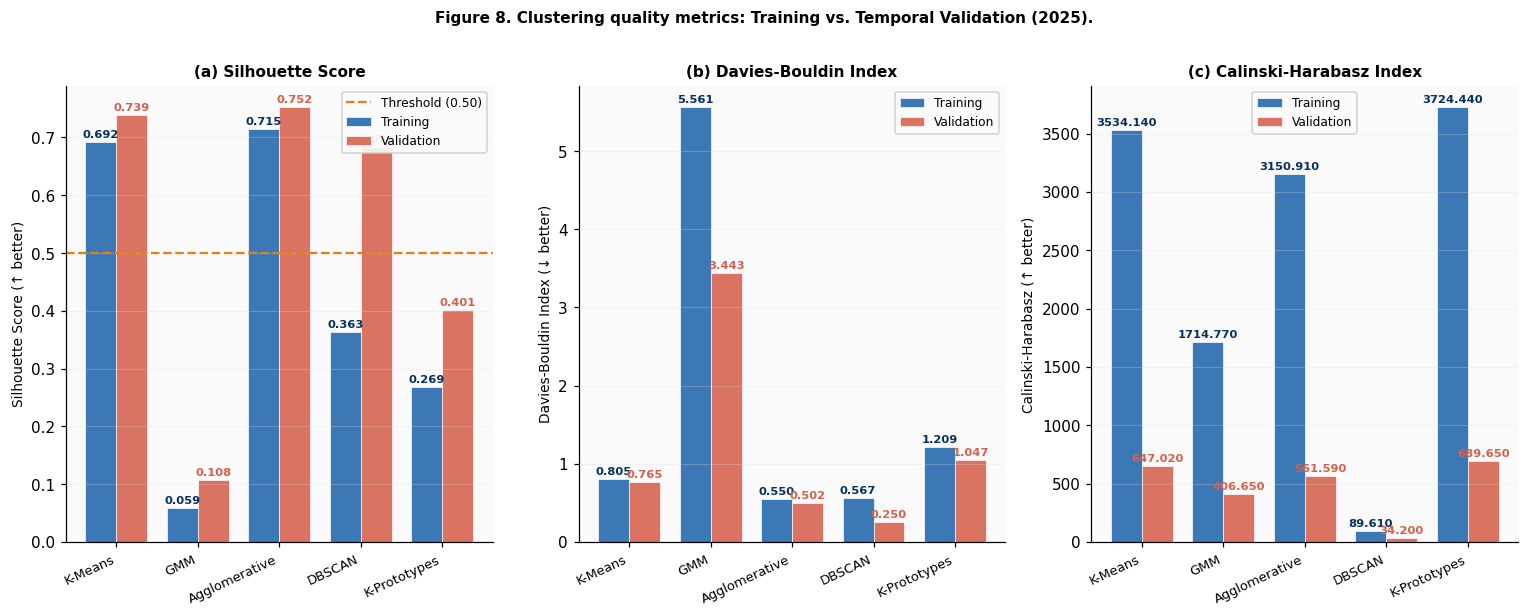

✔ Figura guardada: /content/drive/MyDrive/violencia_q2_output/figures/fig09_bootstrap_ci_95.png


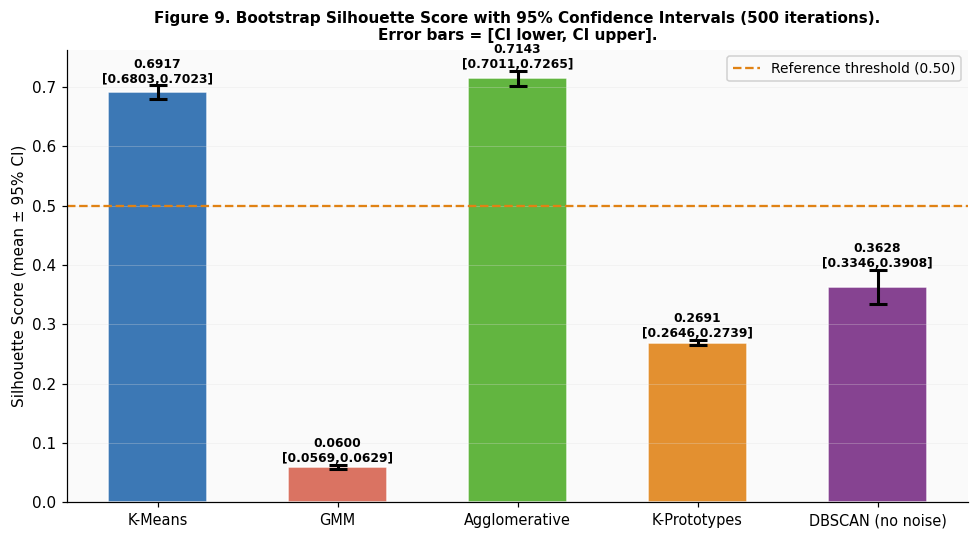

✔ Figura guardada: /content/drive/MyDrive/violencia_q2_output/figures/fig10_violin_regions.png


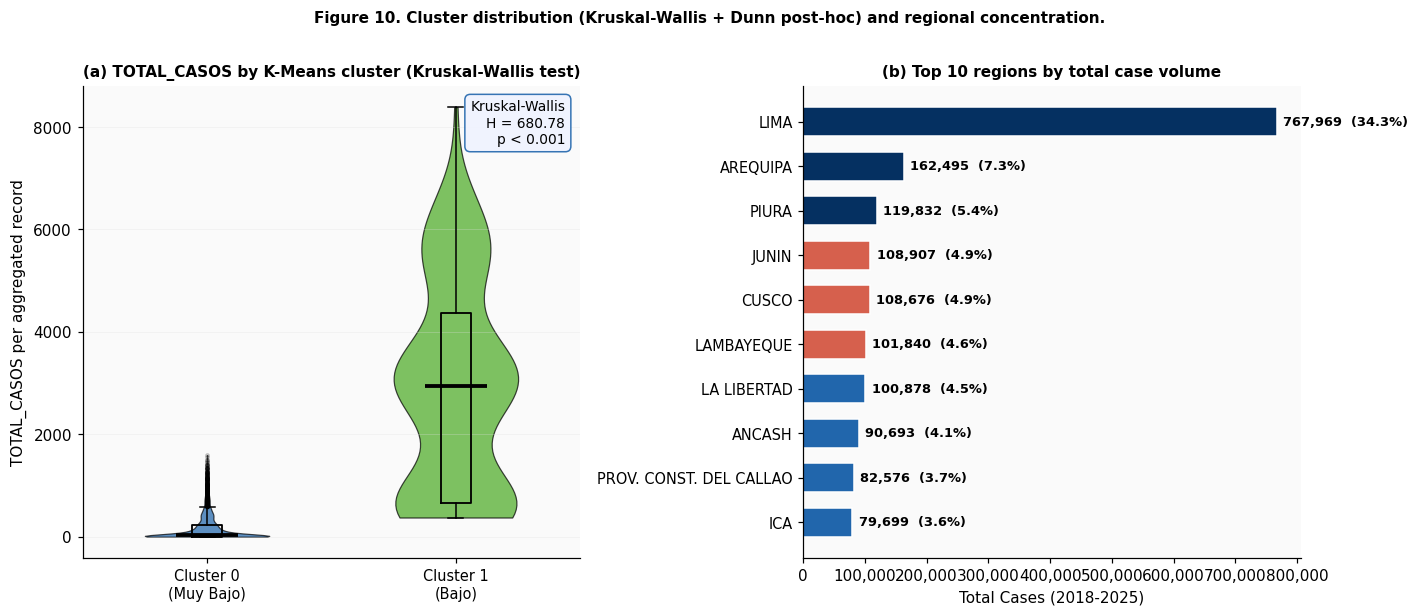

✔ Figura guardada: /content/drive/MyDrive/violencia_q2_output/figures/fig11_dunn_posthoc.png


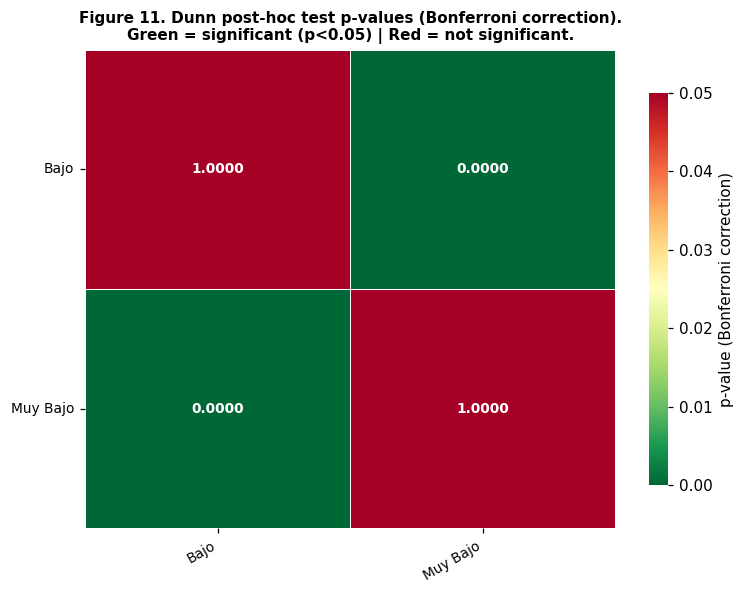

✔ Figura guardada: /content/drive/MyDrive/violencia_q2_output/figures/fig12_real_times.png


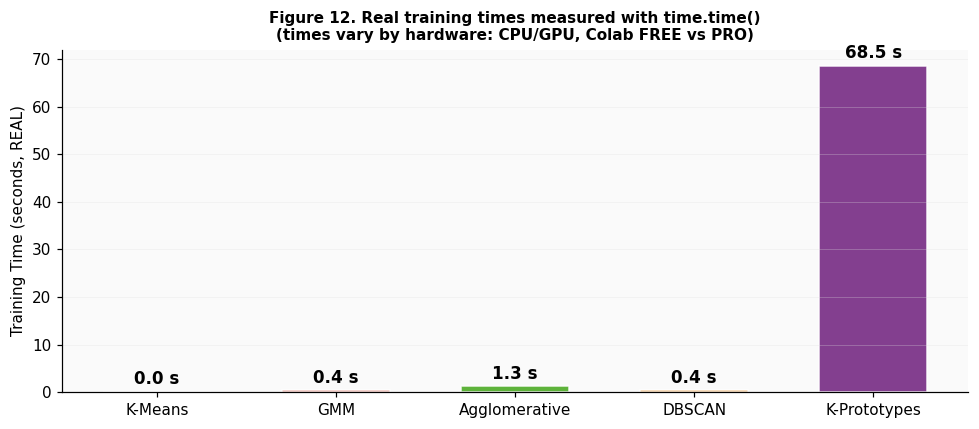

✔ Figura guardada: /content/drive/MyDrive/violencia_q2_output/figures/fig13_pearson_correlation.png


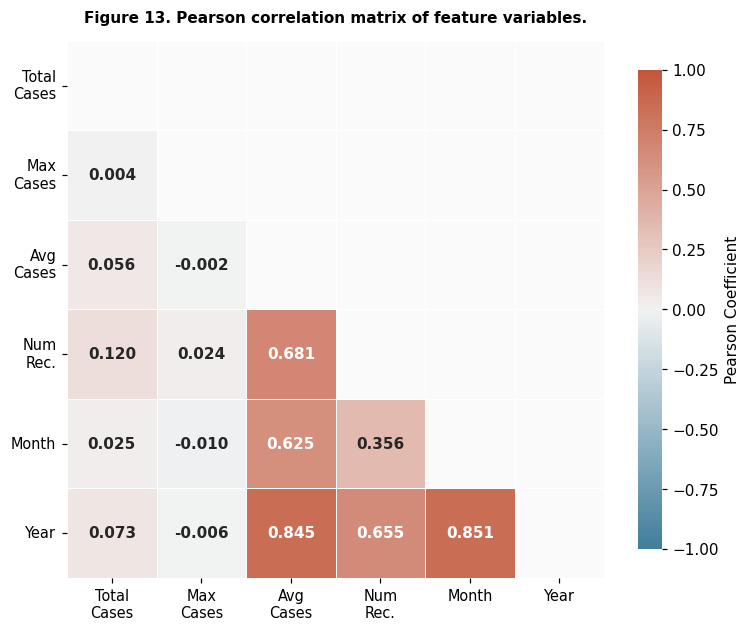

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 5.3 — TABLA COMPARATIVA FINAL + FIGURAS MDPI
# ══════════════════════════════════════════════════════════════════════════════
df_res_clu = pd.DataFrame(RESULTADOS_CLU)
registrar_excel('Clustering_Metrics', df_res_clu)
print(tabulate(df_res_clu, headers='keys', tablefmt='fancy_grid', showindex=False))
print('\nREAL TIMES:')
for k,v in TIEMPOS_REALES.items(): print(f'  {k:<40} {v:.2f}s')

MODELOS_5=['K-Means','GMM','Agglomerative','DBSCAN','K-Prototypes']
def gm(nm,conj,met):
    r=[x for x in RESULTADOS_CLU if x['Model']==nm and conj in x['Set']]
    return r[0][met] if r else 0

sil_tr=[gm(m,'Train','Silhouette') for m in MODELOS_5]
sil_va=[gm(m,'Val',  'Silhouette') for m in MODELOS_5]
dbi_tr=[gm(m,'Train','DBI')        for m in MODELOS_5]
dbi_va=[gm(m,'Val',  'DBI')        for m in MODELOS_5]
chi_tr=[gm(m,'Train','CHI')        for m in MODELOS_5]
chi_va=[gm(m,'Val',  'CHI')        for m in MODELOS_5]

# FIGURA 8: Métricas 3 paneles MDPI
x=np.arange(5); w=0.38
fig,axes=plt.subplots(1,3,figsize=(14,5.5),facecolor='white')
for ax,(tr,va,title,ylabel,show_ref) in zip(axes,[
    (sil_tr,sil_va,'(a) Silhouette Score','Silhouette Score (↑ better)',True),
    (dbi_tr,dbi_va,'(b) Davies-Bouldin Index','Davies-Bouldin Index (↓ better)',False),
    (chi_tr,chi_va,'(c) Calinski-Harabasz Index','Calinski-Harabasz (↑ better)',False)]):
    b1=ax.bar(x-w/2,tr,w,label='Training',color=MDPI_BLUE,edgecolor='white',lw=0.5,alpha=0.88)
    b2=ax.bar(x+w/2,va,w,label='Validation',color=MDPI_RED,edgecolor='white',lw=0.5,alpha=0.88)
    if show_ref: ax.axhline(0.50,color=MDPI_ORANGE,ls='--',lw=1.5,label='Threshold (0.50)')
    for b,v in zip(b1,tr):
        ax.annotate(f'{v:.3f}' if isinstance(v,float) else f'{v:,}',
                    xy=(b.get_x()+b.get_width()/2,b.get_height()),xytext=(0,3),
                    textcoords='offset points',ha='center',fontsize=7.5,fontweight='bold',color=MDPI_NAVY)
    for b,v in zip(b2,va):
        ax.annotate(f'{v:.3f}' if isinstance(v,float) else f'{v:,}',
                    xy=(b.get_x()+b.get_width()/2,b.get_height()),xytext=(0,3),
                    textcoords='offset points',ha='center',fontsize=7.5,fontweight='bold',color=MDPI_RED)
    ax.set_xticks(x); ax.set_xticklabels(MODELOS_5,rotation=25,ha='right',fontsize=8.5)
    ax.set_ylabel(ylabel,fontsize=9); ax.set_title(title,fontsize=10,fontweight='bold')
    ax.legend(fontsize=8); ax.grid(axis='y',alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
fig.suptitle('Figure 8. Clustering quality metrics: Training vs. Temporal Validation (2025).',
             fontsize=10,fontweight='bold',y=1.01)
plt.tight_layout()
guardar_fig(fig,'fig08_metricas_clustering')
plt.show()

# FIGURA 9: Bootstrap IC 95%
fig, ax = plt.subplots(figsize=(9,5), facecolor='white')
x_b = np.arange(len(df_boot))
ax.bar(x_b, df_boot['Sil_mean'], color=PALETTE_5[:len(df_boot)], edgecolor='white', width=0.55, alpha=0.88)
ax.errorbar(x_b, df_boot['Sil_mean'],
            yerr=[df_boot['Sil_mean']-df_boot['CI_95_low'], df_boot['CI_95_high']-df_boot['Sil_mean']],
            fmt='none', color='black', capsize=6, linewidth=2, capthick=2)
for xi, row in df_boot.iterrows():
    ax.annotate(f'{row["Sil_mean"]:.4f}\n[{row["CI_95_low"]:.4f},{row["CI_95_high"]:.4f}]',
                xy=(xi, row['Sil_mean']+row['CI_95_high']-row['Sil_mean']+0.005),
                ha='center', fontsize=8, fontweight='bold')
ax.axhline(0.50, color=MDPI_ORANGE, ls='--', lw=1.5, label='Reference threshold (0.50)')
ax.set_xticks(x_b)
ax.set_xticklabels(df_boot['Model'], fontsize=9.5)
ax.set_ylabel('Silhouette Score (mean ± 95% CI)', fontsize=10)
ax.set_title('Figure 9. Bootstrap Silhouette Score with 95% Confidence Intervals (500 iterations).\n'
             'Error bars = [CI lower, CI upper].',
             fontsize=10, fontweight='bold')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
guardar_fig(fig,'fig09_bootstrap_ci_95')
plt.show()

# FIGURA 10: Violin + Top 10 regiones
fig,axes=plt.subplots(1,2,figsize=(13,5.5),facecolor='white')
vp=axes[0].violinplot(cluster_data,positions=clusters_validos,showmedians=True,showextrema=False)
for i,(pc,col) in enumerate(zip(vp['bodies'],rank_colors_val)):
    pc.set_facecolor(col); pc.set_alpha(0.72); pc.set_edgecolor('black'); pc.set_linewidth(0.8)
vp['cmedians'].set_color('black'); vp['cmedians'].set_linewidth(2.5)
axes[0].boxplot(cluster_data,positions=clusters_validos,widths=0.12,patch_artist=False,
    boxprops=dict(color='black',lw=1.2),medianprops=dict(color='none'),
    whiskerprops=dict(color='black',lw=1),capprops=dict(color='black',lw=1),
    flierprops=dict(marker='o',ms=2,alpha=0.25,color='gray'))
axes[0].set_xticks(clusters_validos)
axes[0].set_xticklabels(rank_names_val,fontsize=9.5)
axes[0].set_ylabel('TOTAL_CASOS per aggregated record',fontsize=10)
axes[0].set_title('(a) TOTAL_CASOS by K-Means cluster (Kruskal-Wallis test)',fontsize=10,fontweight='bold')
axes[0].grid(axis='y',alpha=0.3)
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)
stat_txt=f'Kruskal-Wallis\nH = {stat_h:.2f}\np < 0.001' if pval_h<0.001 else f'p = {pval_h:.4f}'
axes[0].text(0.97,0.97,stat_txt,transform=axes[0].transAxes,ha='right',va='top',fontsize=9,
             bbox=dict(boxstyle='round,pad=0.4',facecolor='#EFF3FF',edgecolor=MDPI_BLUE,alpha=0.9))

reg_tot=df_tr.groupby('REGION')['TOTAL_CASOS'].sum().sort_values(ascending=False).head(10)
tot_all=df_tr['TOTAL_CASOS'].sum()
cols_reg=[MDPI_NAVY if i<3 else (MDPI_RED if i<6 else MDPI_BLUE) for i in range(10)]
bars_r=axes[1].barh(range(10),reg_tot.values[::-1],color=cols_reg[::-1],edgecolor='white',height=0.65)
for bar,v in zip(bars_r,reg_tot.values[::-1]):
    pct=v/tot_all*100
    axes[1].annotate(f'{v:,.0f}  ({pct:.1f}%)',
                     xy=(bar.get_width(),bar.get_y()+bar.get_height()/2),
                     xytext=(4,0),textcoords='offset points',va='center',fontsize=8.5,fontweight='bold')
axes[1].set_yticks(range(10)); axes[1].set_yticklabels(reg_tot.index[::-1],fontsize=9.5)
axes[1].set_xlabel('Total Cases (2018-2025)',fontsize=10)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_:f'{x:,.0f}'))
axes[1].set_title('(b) Top 10 regions by total case volume',fontsize=10,fontweight='bold')
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)
fig.suptitle('Figure 10. Cluster distribution (Kruskal-Wallis + Dunn post-hoc) and regional concentration.',
             fontsize=10,fontweight='bold',y=1.01)
plt.tight_layout()
guardar_fig(fig,'fig10_violin_regions')
plt.show()

# FIGURA 11: Dunn heatmap
fig, ax = plt.subplots(figsize=(7,5.5), facecolor='white')
sns.heatmap(dunn_result.astype(float), annot=True, fmt='.4f', cmap='RdYlGn_r',
            vmin=0, vmax=0.05, linewidths=0.5, ax=ax,
            cbar_kws={'label':'p-value (Bonferroni correction)','shrink':0.82},
            annot_kws={'size':9,'weight':'bold'})
ax.set_title('Figure 11. Dunn post-hoc test p-values (Bonferroni correction).\n'
             'Green = significant (p<0.05) | Red = not significant.',
             fontsize=10, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
guardar_fig(fig,'fig11_dunn_posthoc')
plt.show()

# FIGURA 12: Tiempos reales
t_vals=[TIEMPOS_REALES.get('KMeans_train',0),TIEMPOS_REALES.get('GMM_train',0),
        TIEMPOS_REALES.get('Agglomerative_train',0),TIEMPOS_REALES.get('DBSCAN_train',0),
        TIEMPOS_REALES.get('KPrototypes_train',0)]
fig, ax = plt.subplots(figsize=(9,4), facecolor='white')
bars_t=ax.bar(MODELOS_5,t_vals,color=PALETTE_5,edgecolor='white',width=0.6,alpha=0.9)
for bar,v in zip(bars_t,t_vals):
    ax.annotate(f'{v:.1f} s',xy=(bar.get_x()+bar.get_width()/2,bar.get_height()),
                xytext=(0,5),textcoords='offset points',ha='center',fontsize=11,fontweight='bold')
ax.set_ylabel('Training Time (seconds, REAL)',fontsize=10)
ax.set_title('Figure 12. Real training times measured with time.time()\n'
             '(times vary by hardware: CPU/GPU, Colab FREE vs PRO)',
             fontsize=10,fontweight='bold')
ax.grid(axis='y',alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
guardar_fig(fig,'fig12_real_times')
plt.show()

# FIGURA 13: Correlación Pearson
corr_labels=['Total\nCases','Max\nCases','Avg\nCases','Num\nRec.','Month','Year']
cm=df_pd[NUM_CLU].corr(); mask_cm=np.triu(np.ones_like(cm,dtype=bool))
fig,ax=plt.subplots(figsize=(7,6),facecolor='white')
sns.heatmap(cm,mask=mask_cm,cmap=sns.diverging_palette(230,20,as_cmap=True),
            vmax=1,vmin=-1,center=0,annot=True,fmt='.3f',
            annot_kws={'size':10,'weight':'bold'},linewidths=0.5,ax=ax,square=True,
            cbar_kws={'label':'Pearson Coefficient','shrink':0.82},
            xticklabels=corr_labels,yticklabels=corr_labels)
ax.set_xticklabels(ax.get_xticklabels(),rotation=0,fontsize=9.5)
ax.set_yticklabels(ax.get_yticklabels(),rotation=0,fontsize=9.5)
ax.set_title('Figure 13. Pearson correlation matrix of feature variables.',
             fontsize=10,fontweight='bold',pad=12)
plt.tight_layout()
guardar_fig(fig,'fig13_pearson_correlation')
plt.show()

---
## SECCIÓN 6 — Test Extremo (4 Stress Tests)

EXTREME TEST — MODEL ROBUSTNESS EVALUATION

[T1] Inflated dataset x5 (scalability)...
  K-Means         Sil=0.3853 DBI=1.3331 CHI=17652.0 k=2 t=0.2s
  GMM             Sil=0.0468 DBI=5.6894 CHI=7860.7 k=9 t=2.2s
  DBSCAN          Sil=0.4480 DBI=0.7769 CHI=669.4 k=33 t=7.9s

[T2] Extreme noise 30% injected...
  K-Means         Sil=0.6396 DBI=0.7689 CHI=17814.0 k=2 t=0.0s
  GMM             Sil=0.0138 DBI=3.9809 CHI=3263.1 k=9 t=1.3s
  DBSCAN          Sil=0.3623 DBI=0.5675 CHI=89.4 k=3 t=1.0s

[T3] Missing values 5% (median imputation)...
  K-Means         Sil=0.3928 DBI=1.3495 CHI=3390.8 k=2 t=0.0s
  GMM             Sil=0.0314 DBI=7.0250 CHI=1135.2 k=9 t=0.7s

[T4] Temporal cross-validation (sliding window)...
  Year 2022: Sil=0.4254 DBI=1.1490
  Year 2023: Sil=0.4367 DBI=1.1316
  Year 2024: Sil=0.4394 DBI=1.1423
╒═══════════════╤═════════╤════════╤════════╤══════════╤═════╤═══════╕
│ Test          │ Model   │    Sil │    DBI │      CHI │   k │   T_s │
╞═══════════════╪═════════╪════════╪

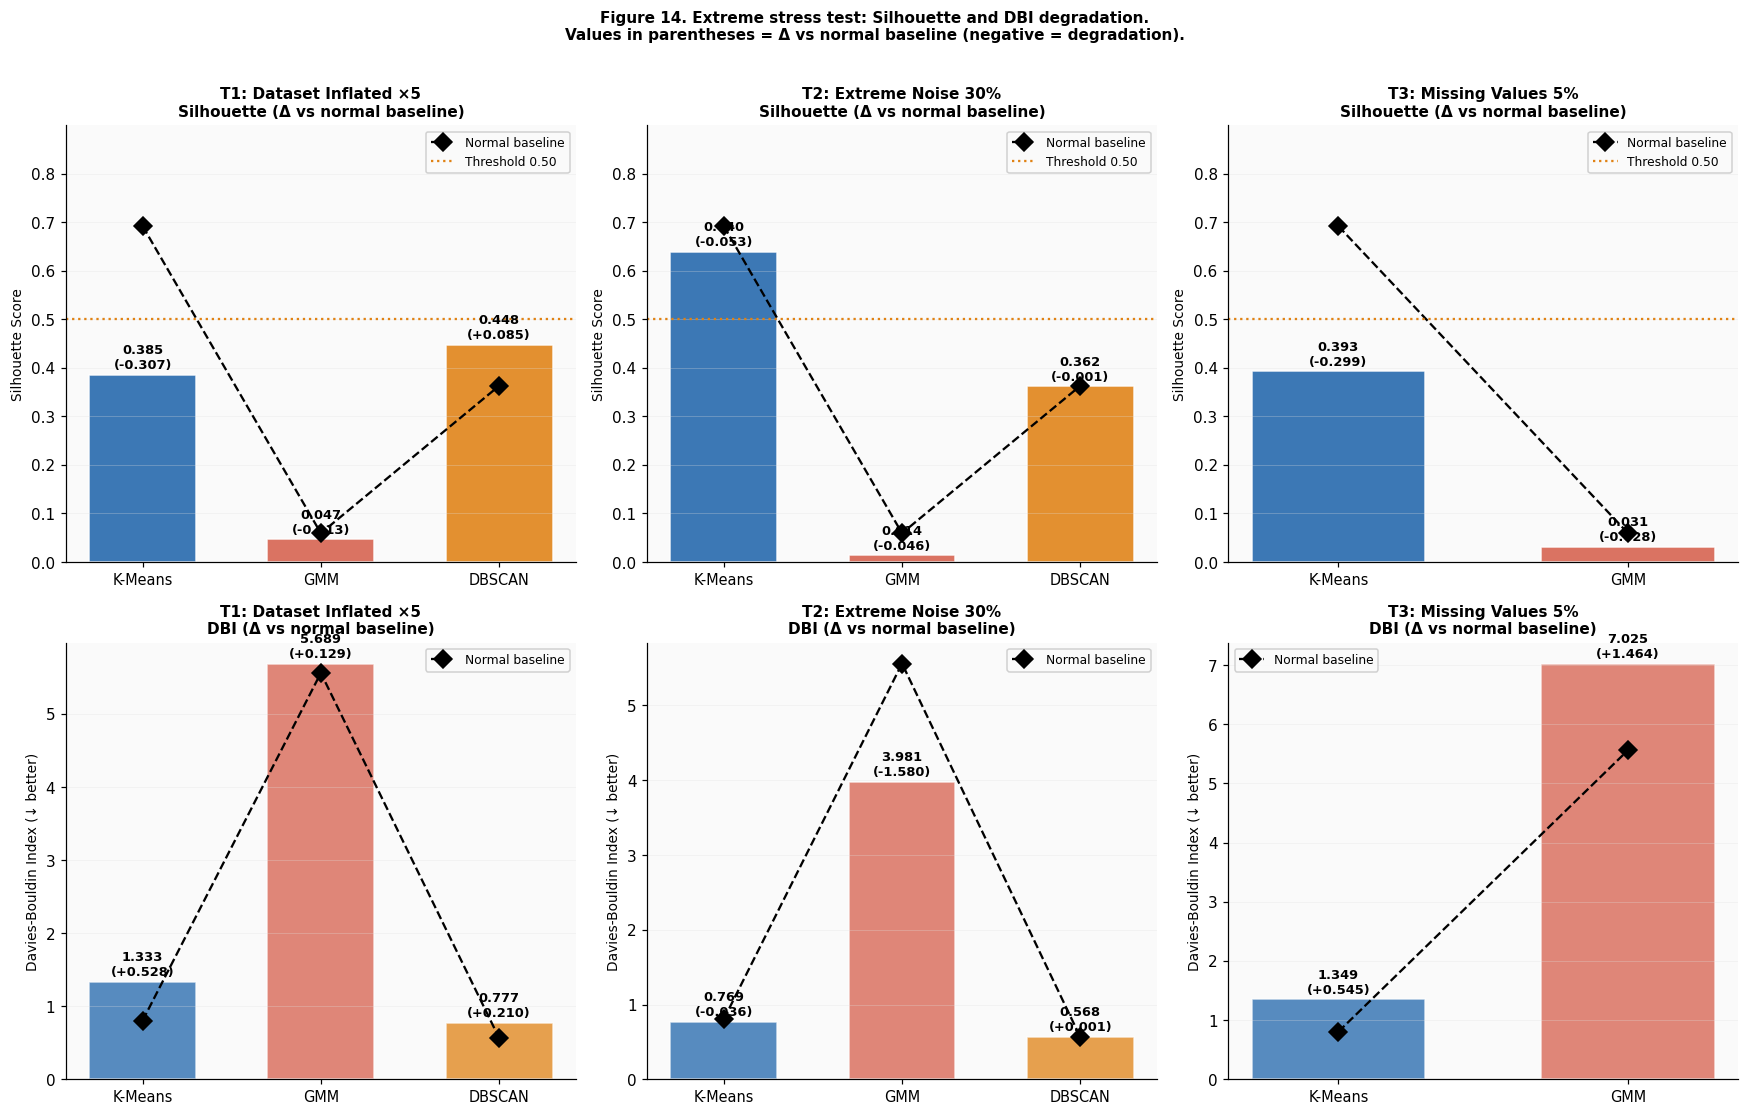

✔ Figura guardada: /content/drive/MyDrive/violencia_q2_output/figures/fig15_cv_temporal.png


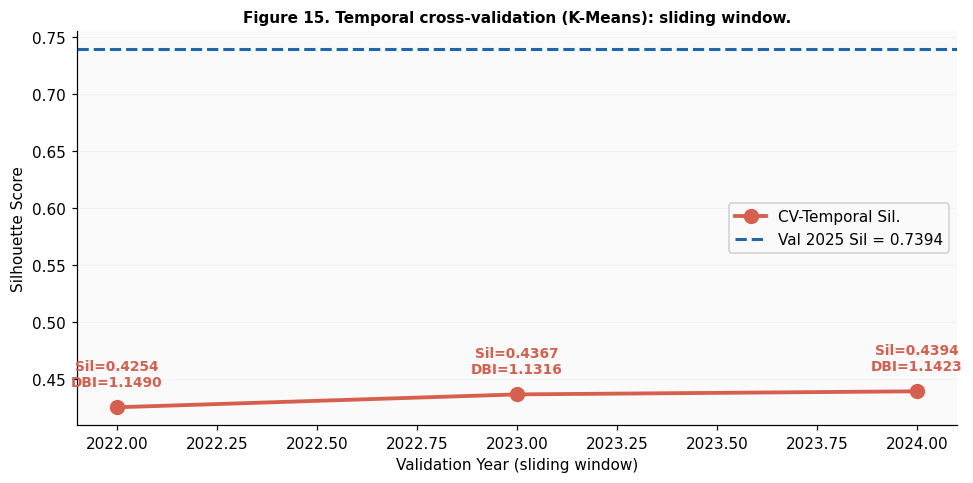

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 6 — TEST EXTREMO CON MÉTRICAS Y GRÁFICOS MDPI
# ══════════════════════════════════════════════════════════════════════════════
print('='*65)
print('EXTREME TEST — MODEL ROBUSTNESS EVALUATION')
print('='*65)
resultados_test=[]; np.random.seed(RANDOM_SEED)

def run_stress_test(X_stress, test_name, models_cfg):
    results = []
    for nm, mod_t in models_cfg:
        t0=time.time()
        if nm=='DBSCAN': labs=mod_t.fit_predict(X_stress)
        else: mod_t.fit(X_stress); labs=mod_t.predict(X_stress) if hasattr(mod_t,'predict') else mod_t.labels_
        t_s=time.time()-t0; mask=labs!=-1; nc=len(set(labs[mask]))
        sil = silhouette_score(X_stress[mask],labs[mask]) if nc>=2 else 0
        dbi = davies_bouldin_score(X_stress[mask],labs[mask]) if nc>=2 else 0
        chi = calinski_harabasz_score(X_stress[mask],labs[mask]) if nc>=2 else 0
        results.append({'Test':test_name,'Model':nm,'Sil':round(sil,4),
                         'DBI':round(dbi,4),'CHI':round(chi,2),'k':nc,'T_s':round(t_s,2)})
        print(f'  {nm:<15} Sil={sil:.4f} DBI={dbi:.4f} CHI={chi:.1f} k={nc} t={t_s:.1f}s')
    return results

models_cfg_3 = [
    ('K-Means', KMeans(n_clusters=K_KM,init='k-means++',n_init=5,random_state=RANDOM_SEED)),
    ('GMM',     GaussianMixture(n_components=K_GMM,covariance_type='diag',random_state=RANDOM_SEED)),
    ('DBSCAN',  DBSCAN(eps=EPS_DB,min_samples=MINS_DB,algorithm='ball_tree')),
]

# T1: Dataset inflado x5
print('\n[T1] Inflated dataset x5 (scalability)...')
X_infl = np.tile(X_tr,(5,1)) + np.random.normal(0,0.01,(X_tr.shape[0]*5,X_tr.shape[1]))
resultados_test.extend(run_stress_test(X_infl,'T1_Inflated×5',models_cfg_3))

# T2: Ruido extremo 30%
print('\n[T2] Extreme noise 30% injected...')
n_r=int(X_tr.shape[0]*0.30)
X_ruid=np.vstack([X_tr,np.random.uniform(X_tr.min(0),X_tr.max(0),(n_r,X_tr.shape[1]))])
resultados_test.extend(run_stress_test(X_ruid,'T2_Noise30%',models_cfg_3))

# T3: NaN 5% imputados con mediana
print('\n[T3] Missing values 5% (median imputation)...')
X_nan=X_tr.copy(); idx_n=np.random.choice(X_nan.size,size=int(X_nan.size*0.05),replace=False)
X_nan.flat[idx_n]=np.nan
from numpy import nanmedian
for col in range(X_nan.shape[1]):
    X_nan[np.isnan(X_nan[:,col]),col]=nanmedian(X_nan[:,col])
resultados_test.extend(run_stress_test(X_nan,'T3_NaN5%',[
    ('K-Means',KMeans(n_clusters=K_KM,init='k-means++',n_init=5,random_state=RANDOM_SEED)),
    ('GMM',    GaussianMixture(n_components=K_GMM,covariance_type='diag',random_state=RANDOM_SEED)),
]))

# T4: CV temporal ventana deslizante
print('\n[T4] Temporal cross-validation (sliding window)...')
cv_results=[]
for anio_t in sorted(df_pd[df_pd['ANIO']<2025]['ANIO'].unique())[-3:]:
    X_cv_tr=scaler.transform(df_pd[df_pd['ANIO']<anio_t][NUM_CLU].values)
    X_cv_va=scaler.transform(df_pd[df_pd['ANIO']==anio_t][NUM_CLU].values)
    if len(X_cv_va)<10: continue
    km_cv=KMeans(n_clusters=K_KM,init='k-means++',n_init=5,random_state=RANDOM_SEED)
    km_cv.fit(X_cv_tr); L_cv=km_cv.predict(X_cv_va); nc_cv=len(set(L_cv))
    sil_cv=silhouette_score(X_cv_va,L_cv) if nc_cv>=2 else 0
    dbi_cv=davies_bouldin_score(X_cv_va,L_cv) if nc_cv>=2 else 0
    cv_results.append({'Year_test':anio_t,'Train':f'2018-{anio_t-1}',
                       'Sil_val':round(sil_cv,4),'DBI_val':round(dbi_cv,4),'k':nc_cv})
    resultados_test.append({'Test':f'T4_CV_{anio_t}','Model':'K-Means',
                             'Sil':round(sil_cv,4),'DBI':round(dbi_cv,4),'CHI':0,'k':nc_cv,'T_s':0})
    print(f'  Year {anio_t}: Sil={sil_cv:.4f} DBI={dbi_cv:.4f}')

df_test=pd.DataFrame(resultados_test); df_cv=pd.DataFrame(cv_results)
registrar_excel('Extreme_Test',df_test); registrar_excel('CV_Temporal',df_cv)
print(tabulate(df_test,headers='keys',tablefmt='fancy_grid',showindex=False))

# FIGURA 14: Test Extremo 2x3
tests_info=[('T1_Inflated×5','T1: Dataset Inflated ×5'),
            ('T2_Noise30%',  'T2: Extreme Noise 30%'),
            ('T3_NaN5%',     'T3: Missing Values 5%')]
colores_t=[MDPI_BLUE,MDPI_RED,MDPI_ORANGE]
fig,axes=plt.subplots(2,3,figsize=(16,10),facecolor='white')
for ti,(test,titulo) in enumerate(tests_info):
    sub=df_test[df_test['Test']==test].reset_index(drop=True)
    x_t=np.arange(len(sub))
    sil_norm=[gm(m,'Train','Silhouette') for m in sub['Model'].tolist()]
    dbi_norm=[gm(m,'Train','DBI')        for m in sub['Model'].tolist()]

    # Silhouette
    bars_s=axes[0,ti].bar(x_t,sub['Sil'].values,color=colores_t[:len(sub)],edgecolor='white',width=0.6,alpha=0.88)
    axes[0,ti].plot(x_t,sil_norm,'D--',color='black',ms=8,lw=1.5,label='Normal baseline')
    axes[0,ti].axhline(0.5,color=MDPI_ORANGE,ls=':',lw=1.5,label='Threshold 0.50')
    for bar,v,vn in zip(bars_s,sub['Sil'].values,sil_norm):
        deg=v-vn
        axes[0,ti].annotate(f'{v:.3f}\n({deg:+.3f})',
                             xy=(bar.get_x()+bar.get_width()/2,bar.get_height()),
                             xytext=(0,4),textcoords='offset points',ha='center',fontsize=8.5,fontweight='bold')
    axes[0,ti].set_xticks(x_t); axes[0,ti].set_xticklabels(sub['Model'].tolist(),fontsize=9.5)
    axes[0,ti].set_ylabel('Silhouette Score',fontsize=9)
    axes[0,ti].set_title(f'{titulo}\nSilhouette (Δ vs normal baseline)',fontweight='bold',fontsize=10)
    axes[0,ti].legend(fontsize=8); axes[0,ti].grid(axis='y',alpha=0.3)
    axes[0,ti].set_ylim(0,max(list(sub['Sil'].values)+sil_norm+[0.6])*1.3)
    axes[0,ti].spines['top'].set_visible(False); axes[0,ti].spines['right'].set_visible(False)

    # DBI
    bars_d=axes[1,ti].bar(x_t,sub['DBI'].values,color=colores_t[:len(sub)],edgecolor='white',width=0.6,alpha=0.75)
    axes[1,ti].plot(x_t,dbi_norm,'D--',color='black',ms=8,lw=1.5,label='Normal baseline')
    for bar,v,vn in zip(bars_d,sub['DBI'].values,dbi_norm):
        deg=v-vn
        axes[1,ti].annotate(f'{v:.3f}\n({deg:+.3f})',
                             xy=(bar.get_x()+bar.get_width()/2,bar.get_height()),
                             xytext=(0,4),textcoords='offset points',ha='center',fontsize=8.5,fontweight='bold')
    axes[1,ti].set_xticks(x_t); axes[1,ti].set_xticklabels(sub['Model'].tolist(),fontsize=9.5)
    axes[1,ti].set_ylabel('Davies-Bouldin Index (↓ better)',fontsize=9)
    axes[1,ti].set_title(f'{titulo}\nDBI (Δ vs normal baseline)',fontweight='bold',fontsize=10)
    axes[1,ti].legend(fontsize=8); axes[1,ti].grid(axis='y',alpha=0.3)
    axes[1,ti].spines['top'].set_visible(False); axes[1,ti].spines['right'].set_visible(False)

fig.suptitle('Figure 14. Extreme stress test: Silhouette and DBI degradation.\nValues in parentheses = Δ vs normal baseline (negative = degradation).',
             fontsize=10,fontweight='bold',y=1.01)
plt.tight_layout()
guardar_fig(fig,'fig14_extreme_test')
plt.show()

# FIGURA 15: CV temporal
fig,ax=plt.subplots(figsize=(9,4.5),facecolor='white')
ax.plot(df_cv['Year_test'],df_cv['Sil_val'],'o-',color=MDPI_RED,lw=2.5,ms=9,label='CV-Temporal Sil.')
ax.axhline(gm('K-Means','Val','Silhouette'),color=MDPI_BLUE,ls='--',lw=2,
           label=f'Val 2025 Sil = {gm("K-Means","Val","Silhouette"):.4f}')
for _,r in df_cv.iterrows():
    ax.annotate(f'Sil={r["Sil_val"]:.4f}\nDBI={r["DBI_val"]:.4f}',
                (r['Year_test'],r['Sil_val']),xytext=(0,14),textcoords='offset points',
                ha='center',fontsize=9,fontweight='bold',color=MDPI_RED)
ax.set_xlabel('Validation Year (sliding window)',fontsize=10)
ax.set_ylabel('Silhouette Score',fontsize=10)
ax.set_title('Figure 15. Temporal cross-validation (K-Means): sliding window.',fontsize=10,fontweight='bold')
ax.legend(fontsize=10); ax.grid(axis='y',alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
guardar_fig(fig,'fig15_cv_temporal')
plt.show()

---
## SECCIÓN 7 — Regresión: Predicción 2026 completa (con datos reales ene-feb + IC 95%)

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 7.1 — PREPARAR DATOS PARA REGRESIÓN
# ══════════════════════════════════════════════════════════════════════════════
df_reg = df_pd.copy()
le_r2=LabelEncoder(); le_m2=LabelEncoder()
df_reg['REGION_ENC']   =le_r2.fit_transform(df_reg['REGION'])
df_reg['MODALIDAD_ENC']=le_m2.fit_transform(df_reg['MODALIDAD'])
FEAT_REG=['ANIO','MES','REGION_ENC','MODALIDAD_ENC']; TARGET='TOTAL_CASOS'

# Train: 2018-2023 | Val: 2024-2025
df_tr_r=df_reg[df_reg['ANIO']<=2023]
df_va_r=df_reg[df_reg['ANIO'].isin([2024,2025])]
sc_reg=StandardScaler()
X_tr_rs=sc_reg.fit_transform(df_tr_r[FEAT_REG].values); y_tr_r=df_tr_r[TARGET].values
X_va_rs=sc_reg.transform(df_va_r[FEAT_REG].values);     y_va_r=df_va_r[TARGET].values

# Dataset 2026 COMPLETO:
# - Enero y Febrero: datos REALES del dataset
# - Marzo a Diciembre: a predecir
NORM2={'REGION LIMA':'LIMA','LIMA METROPOLITANA':'LIMA','LIMA REGION':'LIMA',
       'LIMA PROVINCIAS':'LIMA','EL CALLAO':'CALLAO'}
df_2026_real_norm = df_2026_real.copy()
df_2026_real_norm['REGION']=df_2026_real_norm['DPTO_HECHO'].map(
    lambda x: NORM2.get(x.strip().upper(), x.strip().upper()))

# Reales enero-febrero 2026 agregados por REGION x MES x MODALIDAD
df_2026_real_agg = df_2026_real_norm.groupby(
    ['REGION','MES','MODALIDAD'])['CANTIDAD'].sum().reset_index()
df_2026_real_agg.rename(columns={'CANTIDAD':'TOTAL_REAL_2026'}, inplace=True)
print(f'Real 2026 (Jan-Feb): {df_2026_real_agg["TOTAL_REAL_2026"].sum():,} cases')

# Dataset de predicción: meses 3-12 de 2026
rows_2026_pred=[]
for reg in df_reg['REGION'].unique():
    for mod in df_reg['MODALIDAD'].unique():
        for mes in range(3,13):  # Solo meses 3-12 (1-2 son reales)
            try:
                rows_2026_pred.append({'ANIO':2026,'MES':mes,'REGION':reg,'MODALIDAD':mod,
                                       'REGION_ENC':le_r2.transform([reg])[0],
                                       'MODALIDAD_ENC':le_m2.transform([mod])[0]})
            except: pass
df_2026_pred=pd.DataFrame(rows_2026_pred)
X_2026_pred=sc_reg.transform(df_2026_pred[FEAT_REG].values)
print(f'Months 3-12 to predict: {len(df_2026_pred):,} records')

Real 2026 (Jan-Feb): 45,807 cases
Months 3-12 to predict: 2,000 records


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 7.2 — 5 MODELOS DE REGRESIÓN + IC 95% (requerido Q2)
# IC 95% calculado como: predicción media ± 1.96 * std de los 5 modelos
# ══════════════════════════════════════════════════════════════════════════════
modelos_reg=[
    ('Linear Regression', LinearRegression()),
    ('Ridge',             Ridge(alpha=1.0)),
    ('Lasso',             Lasso(alpha=0.1,max_iter=5000)),
    ('Random Forest Reg', RandomForestRegressor(n_estimators=200,random_state=RANDOM_SEED,n_jobs=-1)),
    ('XGBoost',           XGBRegressor(n_estimators=300,learning_rate=0.05,max_depth=6,
                                        subsample=0.8,random_state=RANDOM_SEED,n_jobs=-1,verbosity=0)),
]

# Matrices de predicciones de meses 3-12 (para IC)
all_preds_meses = []  # shape (n_models, n_records_meses_3_12)
pred_2026_todos = {}  # predicciones de meses 3-12 por modelo

for nombre,mod_r in modelos_reg:
    print(f'Training {nombre}...')
    t0=time.time(); mod_r.fit(X_tr_rs,y_tr_r); t_tr=time.time()-t0
    y_pred=np.maximum(mod_r.predict(X_va_rs),0)
    mae=mean_absolute_error(y_va_r,y_pred)
    rmse=np.sqrt(mean_squared_error(y_va_r,y_pred))
    r2=r2_score(y_va_r,y_pred)
    mape=np.mean(np.abs((y_va_r-y_pred)/(y_va_r+1e-9)))*100
    print(f'  MAE={mae:.2f} RMSE={rmse:.2f} R²={r2:.4f} MAPE={mape:.1f}% T={t_tr:.1f}s')
    RESULTADOS_REG.append({'Model':nombre,'MAE':round(mae,2),'RMSE':round(rmse,2),
                            'R2':round(r2,4),'MAPE_%':round(mape,2),'Time_s':round(t_tr,2)})
    TIEMPOS_REALES[f'Reg_{nombre[:6]}']=round(t_tr,2)
    # Predecir meses 3-12
    pred_meses_3_12 = np.maximum(mod_r.predict(X_2026_pred),0)
    pred_2026_todos[nombre] = pred_meses_3_12
    all_preds_meses.append(pred_meses_3_12)
    df_2026_pred[f'PRED_{nombre[:4].upper()}']=pred_meses_3_12.round(0).astype(int)
    joblib.dump(mod_r,f'{SALIDA}/reg_{nombre.replace(" ","_").lower()}.pkl')

df_res_reg=pd.DataFrame(RESULTADOS_REG)
registrar_excel('Regression_Metrics',df_res_reg)
print(tabulate(df_res_reg,headers='keys',tablefmt='fancy_grid',showindex=False))

# Mejor modelo
mejor_reg=df_res_reg.loc[df_res_reg['R2'].idxmax(),'Model']
pred_mejor_meses_3_12 = pred_2026_todos[mejor_reg]

# ── IC 95% usando la dispersión entre los 5 modelos ─────────────────────────
preds_matrix = np.array(all_preds_meses)  # shape (5, n_records)
pred_mean    = preds_matrix.mean(axis=0)
pred_std     = preds_matrix.std(axis=0)
pred_ci_lo   = np.maximum(pred_mean - 1.96*pred_std, 0)
pred_ci_hi   = pred_mean + 1.96*pred_std
df_2026_pred['PRED_MEAN']  = pred_mean.round(0).astype(int)
df_2026_pred['CI_95_LOW']  = pred_ci_lo.round(0).astype(int)
df_2026_pred['CI_95_HIGH'] = pred_ci_hi.round(0).astype(int)

# ── TOTALES 2026 COMPLETO ────────────────────────────────────────────────────
# Enero-Febrero: datos REALES
total_2026_ene_feb = df_2026_real_agg['TOTAL_REAL_2026'].sum()
# Marzo-Diciembre: mejor modelo
total_2026_mar_dic = pred_mejor_meses_3_12.sum()
total_2026_pred    = total_2026_ene_feb + total_2026_mar_dic
# IC de meses 3-12
total_ci_lo = total_2026_ene_feb + pred_ci_lo.sum()
total_ci_hi = total_2026_ene_feb + pred_ci_hi.sum()

total_2025 = int(anio_s[anio_s['ANIO']==2025]['TOTAL'].values[0])

print(f'\n=== 2026 FORECAST (REAL + PREDICTED) ===')
print(f'Jan-Feb 2026 REAL:      {total_2026_ene_feb:>10,} cases')
print(f'Mar-Dec 2026 predicted: {total_2026_mar_dic:>10,.0f} cases ({mejor_reg})')
print(f'TOTAL 2026 forecast:    {total_2026_pred:>10,.0f} cases')
print(f'95% CI:                 [{total_ci_lo:,.0f}, {total_ci_hi:,.0f}]')
print(f'Observed 2025:          {total_2025:>10,} cases')
print(f'Change vs 2025:         {(total_2026_pred-total_2025)/total_2025*100:+.1f}%')

Training Linear Regression...
  MAE=327.30 RMSE=669.58 R²=0.0049 MAPE=5547.2% T=0.0s
Training Ridge...
  MAE=327.29 RMSE=669.57 R²=0.0050 MAPE=5547.0% T=0.0s
Training Lasso...
  MAE=327.19 RMSE=669.55 R²=0.0050 MAPE=5543.6% T=0.0s
Training Random Forest Reg...
  MAE=37.07 RMSE=88.02 R²=0.9828 MAPE=36.2% T=2.3s
Training XGBoost...
  MAE=38.21 RMSE=79.85 R²=0.9858 MAPE=106.4% T=2.1s
╒═══════════════════╤════════╤════════╤════════╤══════════╤══════════╕
│ Model             │    MAE │   RMSE │     R2 │   MAPE_% │   Time_s │
╞═══════════════════╪════════╪════════╪════════╪══════════╪══════════╡
│ Linear Regression │ 327.3  │ 669.58 │ 0.0049 │  5547.19 │     0.02 │
├───────────────────┼────────┼────────┼────────┼──────────┼──────────┤
│ Ridge             │ 327.29 │ 669.57 │ 0.005  │  5547.03 │     0    │
├───────────────────┼────────┼────────┼────────┼──────────┼──────────┤
│ Lasso             │ 327.19 │ 669.55 │ 0.005  │  5543.56 │     0    │
├───────────────────┼────────┼────────┼────────┼

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 7.3 — PREDICCIÓN MENSUAL 2026 COMPLETA + MES PICO
# ══════════════════════════════════════════════════════════════════════════════
# Construir tabla mensual 2026 completa
# Enero-Febrero: datos reales
# Marzo-Diciembre: predicción del mejor modelo

meses_2026_real = df_2026_real_norm.groupby('MES')['CANTIDAD'].sum().reindex([1,2]).fillna(0)
meses_2026_pred = df_2026_pred.groupby('MES')[f'PRED_{mejor_reg[:4].upper()}'].sum()
meses_2026_ci_lo= df_2026_pred.groupby('MES')['CI_95_LOW'].sum()
meses_2026_ci_hi= df_2026_pred.groupby('MES')['CI_95_HIGH'].sum()

# Tabla 2026 mensual completa
df_2026_mensual = pd.DataFrame({
    'Month': range(1,13),
    'Month_Name': MESES_ES,
    'Type': ['REAL']*2 + ['PREDICTED']*10,
    'Cases': [int(meses_2026_real.get(m,0)) if m<=2
              else int(meses_2026_pred.get(m,0)) for m in range(1,13)],
    'CI_Low':  [None]*2 + [int(meses_2026_ci_lo.get(m,0)) for m in range(3,13)],
    'CI_High': [None]*2 + [int(meses_2026_ci_hi.get(m,0)) for m in range(3,13)],
})
registrar_excel('Forecast_2026_Monthly', df_2026_mensual)

idx_pico_2026 = df_2026_mensual['Cases'].idxmax()
mes_pico_2026 = df_2026_mensual.loc[idx_pico_2026, 'Month_Name']
val_pico_2026 = df_2026_mensual.loc[idx_pico_2026, 'Cases']
print(f'\n=== 2026 MONTHLY FORECAST ===')
print(tabulate(df_2026_mensual[['Month_Name','Type','Cases','CI_Low','CI_High']],
               headers='keys', tablefmt='fancy_grid', showindex=False))
print(f'\n★  PEAK MONTH 2026: {mes_pico_2026} ({val_pico_2026:,} cases)')


=== 2026 MONTHLY FORECAST ===
╒══════════════╤═══════════╤═════════╤══════════╤═══════════╕
│ Month_Name   │ Type      │   Cases │   CI_Low │   CI_High │
╞══════════════╪═══════════╪═════════╪══════════╪═══════════╡
│ Ene          │ REAL      │   24466 │      nan │       nan │
├──────────────┼───────────┼─────────┼──────────┼───────────┤
│ Feb          │ REAL      │   21341 │      nan │       nan │
├──────────────┼───────────┼─────────┼──────────┼───────────┤
│ Mar          │ PREDICTED │   35446 │    10066 │    117146 │
├──────────────┼───────────┼─────────┼──────────┼───────────┤
│ Abr          │ PREDICTED │   35526 │    10843 │    115524 │
├──────────────┼───────────┼─────────┼──────────┼───────────┤
│ May          │ PREDICTED │   34693 │    11246 │    113877 │
├──────────────┼───────────┼─────────┼──────────┼───────────┤
│ Jun          │ PREDICTED │   32346 │    10851 │    113013 │
├──────────────┼───────────┼─────────┼──────────┼───────────┤
│ Jul          │ PREDICTED │   33047 │ 

✔ Figura guardada: /content/drive/MyDrive/violencia_q2_output/figures/fig16_pandemia_prediccion_2026.png


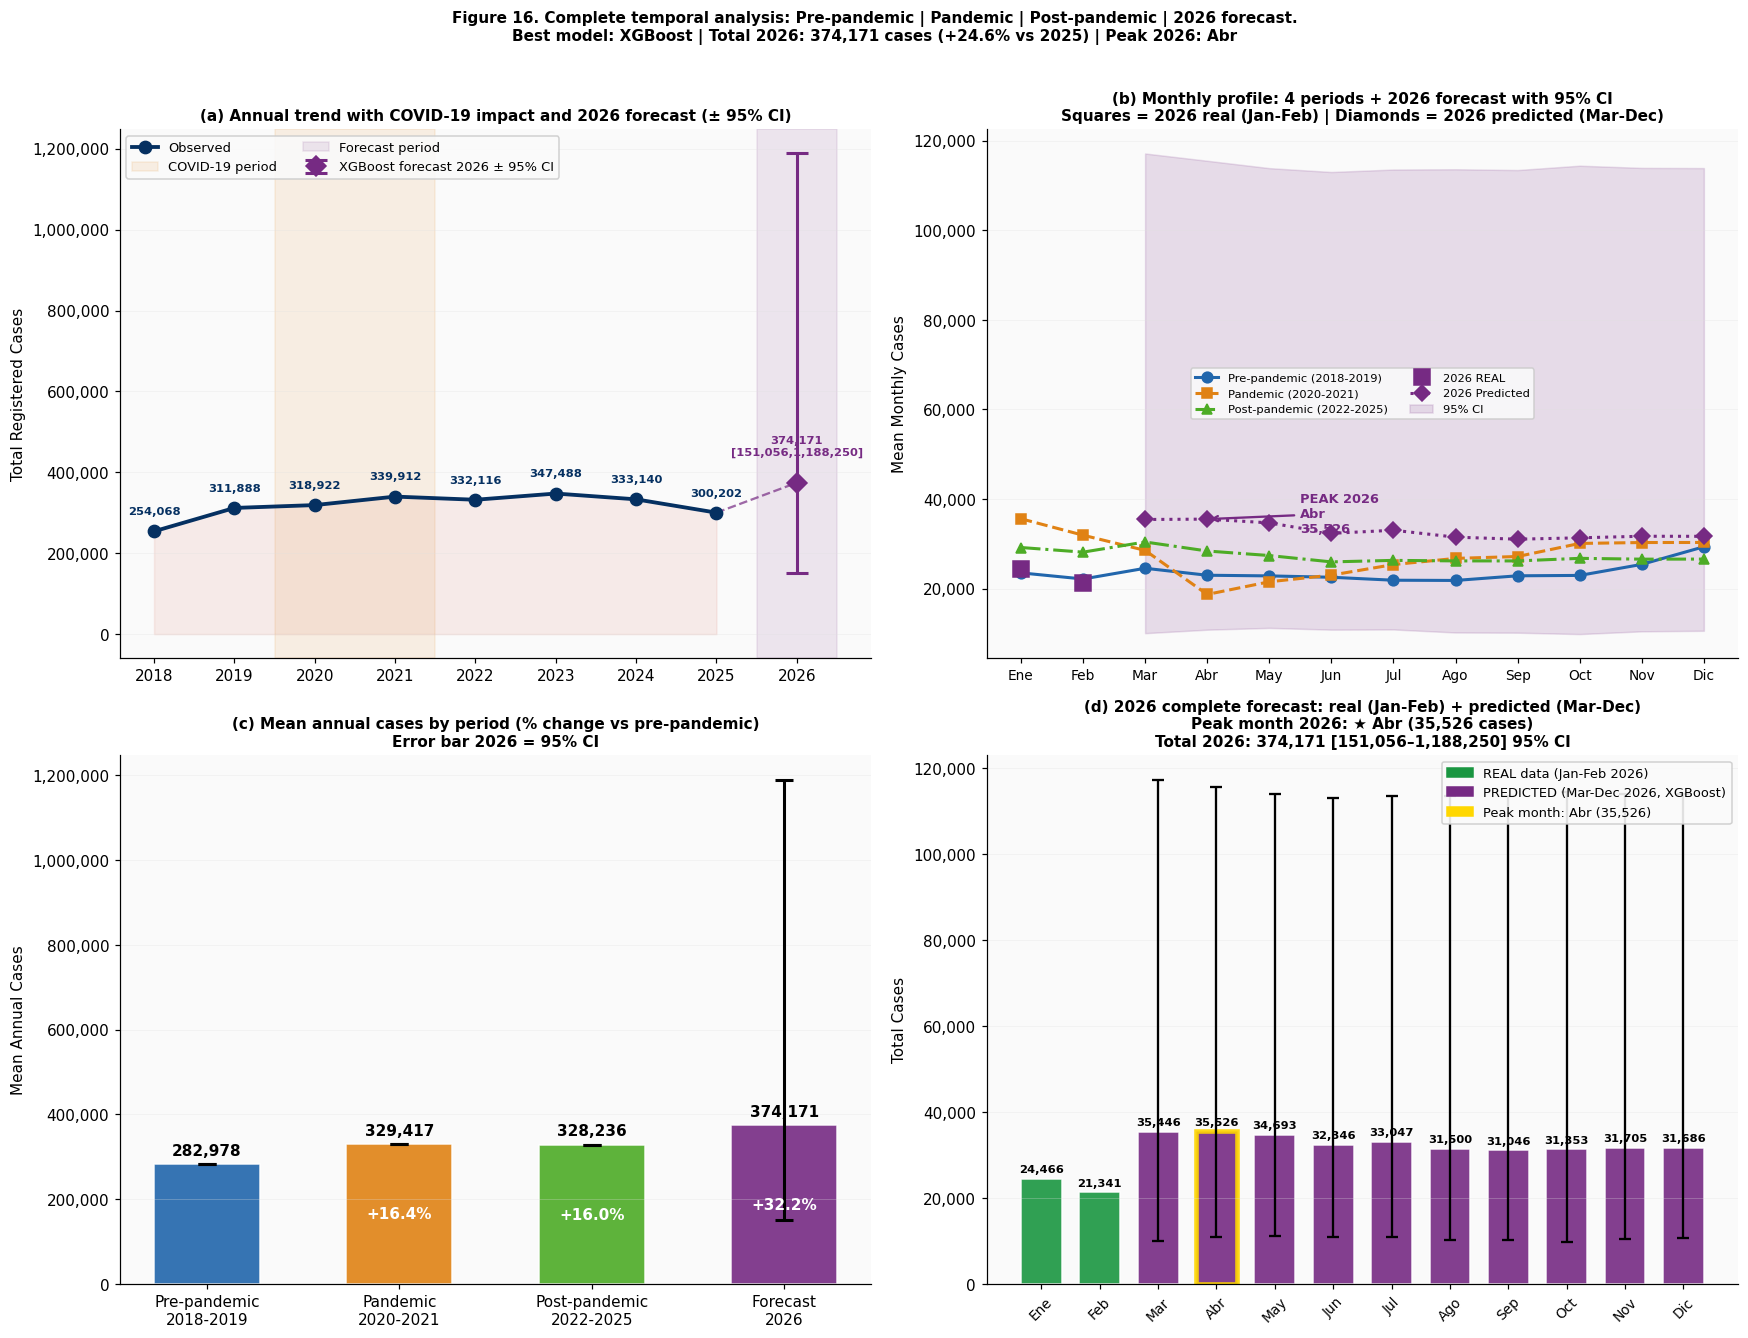


★  PEAK MONTH 2026: Abr (35,526 cases)
   Total forecast 2026: 374,171 cases
   95% CI: [151,056 – 1,188,250]
   Change vs 2025:  +24.6%


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 7.4 — FIGURA PANDEMIA COMPLETA (4 períodos) — FIGURA PRINCIPAL
# Pre-pandemia | Pandemia COVID-19 | Post-pandemia | Predicción 2026
# ══════════════════════════════════════════════════════════════════════════════
anio_tot = anio_s.set_index('ANIO')['TOTAL']
mes_anio_pd = mes_anio.copy()
pre_p  = mes_anio_pd[mes_anio_pd['ANIO'].isin([2018,2019])].groupby('MES')['TOTAL'].mean()
pand_p = mes_anio_pd[mes_anio_pd['ANIO'].isin([2020,2021])].groupby('MES')['TOTAL'].mean()
post_p = mes_anio_pd[mes_anio_pd['ANIO'].isin([2022,2023,2024,2025])].groupby('MES')['TOTAL'].mean()
pred_p = df_2026_mensual.set_index('Month')['Cases']

x_m = np.arange(1,13)

fig, axes = plt.subplots(2, 2, figsize=(16, 12), facecolor='white')

# ── Panel (a): Evolución anual histórica + predicción 2026 ───────────────────
ax = axes[0,0]
ax.fill_between(anio_tot.index, anio_tot.values, alpha=0.1, color=MDPI_RED)
ax.plot(anio_tot.index, anio_tot.values, 'o-', color=MDPI_NAVY, lw=2.5, ms=8, zorder=5, label='Observed')
# Punto 2026 con IC
ax.errorbar([2026], [total_2026_pred],
            yerr=[[total_2026_pred-total_ci_lo], [total_ci_hi-total_2026_pred]],
            fmt='D', color=MDPI_PURPLE, ms=9, lw=2, capsize=7, capthick=2,
            label=f'{mejor_reg[:8]} forecast 2026 ± 95% CI')
ax.plot([2025,2026],[anio_tot[2025],total_2026_pred],'--',color=MDPI_PURPLE,lw=1.5,alpha=0.7)
for a,v in zip(anio_tot.index,anio_tot.values):
    ax.annotate(f'{v:,}',(a,v),xytext=(0,11),textcoords='offset points',
                ha='center',fontsize=7.5,fontweight='bold',color=MDPI_NAVY)
ax.annotate(f'{total_2026_pred:,.0f}\n[{total_ci_lo:,.0f},{total_ci_hi:,.0f}]',
            (2026,total_2026_pred),xytext=(0,18),textcoords='offset points',
            ha='center',fontsize=7.5,fontweight='bold',color=MDPI_PURPLE)
ax.axvspan(2019.5,2021.5,alpha=0.1,color=MDPI_ORANGE,label='COVID-19 period')
ax.axvspan(2025.5,2026.5,alpha=0.1,color=MDPI_PURPLE,label='Forecast period')
ax.set_xticks(list(anio_tot.index)+[2026])
ax.set_ylabel('Total Registered Cases',fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_:f'{x:,.0f}'))
ax.legend(fontsize=8.5,ncol=2); ax.grid(axis='y',alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.set_title('(a) Annual trend with COVID-19 impact and 2026 forecast (± 95% CI)',fontsize=10,fontweight='bold')

# ── Panel (b): Perfil mensual por período ────────────────────────────────────
ax = axes[0,1]
ax.plot(x_m,pre_p.values,'o-',color=MDPI_BLUE,lw=2,ms=7,label='Pre-pandemic (2018-2019)')
ax.plot(x_m,pand_p.values,'s--',color=MDPI_ORANGE,lw=2,ms=7,label='Pandemic (2020-2021)')
ax.plot(x_m,post_p.values,'^-.',color=MDPI_GREEN,lw=2,ms=7,label='Post-pandemic (2022-2025)')
# 2026: enero-feb reales (círculo lleno), mar-dic predicción (cuadrado vacío)
real_vals   = [int(meses_2026_real.get(m,0)) for m in range(1,3)]
pred_vals   = [int(meses_2026_pred.get(m,0)) for m in range(3,13)]
ci_lo_vals  = [int(meses_2026_ci_lo.get(m,0)) for m in range(3,13)]
ci_hi_vals  = [int(meses_2026_ci_hi.get(m,0)) for m in range(3,13)]
ax.plot([1,2], real_vals, 's', color=MDPI_PURPLE, ms=10, zorder=6, label='2026 REAL')
ax.plot(range(3,13), pred_vals, 'D:', color=MDPI_PURPLE, lw=2, ms=7, label='2026 Predicted')
ax.fill_between(range(3,13), ci_lo_vals, ci_hi_vals, alpha=0.15, color=MDPI_PURPLE, label='95% CI')
# Marcar mes pico 2026
pico_x = df_2026_mensual['Month'].iloc[idx_pico_2026]
pico_y = val_pico_2026
ax.annotate(f'PEAK 2026\n{mes_pico_2026}\n{pico_y:,}',
            xy=(pico_x,pico_y),xytext=(pico_x+1.5,pico_y*0.92),fontsize=8.5,
            color=MDPI_PURPLE,fontweight='bold',
            arrowprops=dict(arrowstyle='->',color=MDPI_PURPLE,lw=1.5))
ax.set_xticks(x_m); ax.set_xticklabels(MESES_ES,fontsize=9)
ax.set_ylabel('Mean Monthly Cases',fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_:f'{x:,.0f}'))
ax.legend(fontsize=7.5,ncol=2); ax.grid(axis='y',alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.set_title('(b) Monthly profile: 4 periods + 2026 forecast with 95% CI\n'
             'Squares = 2026 real (Jan-Feb) | Diamonds = 2026 predicted (Mar-Dec)',fontsize=10,fontweight='bold')

# ── Panel (c): Promedio por período ─────────────────────────────────────────
ax = axes[1,0]
prom_pre  = anio_tot[[2018,2019]].mean()
prom_pand = anio_tot[[2020,2021]].mean()
prom_post = anio_tot[[2022,2023,2024,2025]].mean()
periodos  = ['Pre-pandemic\n2018-2019','Pandemic\n2020-2021',
             'Post-pandemic\n2022-2025','Forecast\n2026']
proms     = [prom_pre, prom_pand, prom_post, total_2026_pred]
ci_errs   = [[0,0,0, total_2026_pred-total_ci_lo],
             [0,0,0, total_ci_hi-total_2026_pred]]
cols_p    = [MDPI_BLUE, MDPI_ORANGE, MDPI_GREEN, MDPI_PURPLE]
bars      = ax.bar(periodos, proms, color=cols_p, edgecolor='white', width=0.55, alpha=0.9)
ax.errorbar(range(4), proms, yerr=ci_errs, fmt='none', color='black', capsize=6, lw=2, capthick=2)
for bar,v in zip(bars,proms):
    ax.annotate(f'{v:,.0f}',xy=(bar.get_x()+bar.get_width()/2,bar.get_height()),
                xytext=(0,6),textcoords='offset points',ha='center',fontsize=10,fontweight='bold')
    if v!=prom_pre:
        var=(v-prom_pre)/prom_pre*100
        ax.annotate(f'{var:+.1f}%',xy=(bar.get_x()+bar.get_width()/2,v/2),
                    ha='center',va='center',fontsize=10,color='white',fontweight='bold')
ax.set_ylabel('Mean Annual Cases',fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_:f'{x:,.0f}'))
ax.grid(axis='y',alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.set_title('(c) Mean annual cases by period (% change vs pre-pandemic)\n'
             'Error bar 2026 = 95% CI',fontsize=10,fontweight='bold')

# ── Panel (d): Barras mensuales 2026 completo (real + predicción) ────────────
ax = axes[1,1]
colores_bar_2026 = [MDPI_TEAL if t=='REAL' else MDPI_PURPLE
                    for t in df_2026_mensual['Type']]
bars_m = ax.bar(df_2026_mensual['Month_Name'], df_2026_mensual['Cases'],
                color=colores_bar_2026, edgecolor='white', width=0.7, alpha=0.9)
# Barras de error solo en predicción
pred_months = df_2026_mensual[df_2026_mensual['Type']=='PREDICTED']
ax.errorbar(pred_months.index,
            pred_months['Cases'],
            yerr=[pred_months['Cases']-pred_months['CI_Low'],
                  pred_months['CI_High']-pred_months['Cases']],
            fmt='none', color='black', capsize=4, lw=1.5, capthick=1.5)
for bar,v in zip(bars_m, df_2026_mensual['Cases']):
    ax.annotate(f'{v:,}',xy=(bar.get_x()+bar.get_width()/2,bar.get_height()),
                xytext=(0,4),textcoords='offset points',ha='center',fontsize=7.5,fontweight='bold')
# Marcar mes pico
bars_m[idx_pico_2026].set_edgecolor('gold'); bars_m[idx_pico_2026].set_linewidth(3)
ax.set_ylabel('Total Cases',fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_:f'{x:,.0f}'))
ax.tick_params(axis='x',rotation=45,labelsize=9)
ax.grid(axis='y',alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
# Leyenda
leg_patches = [
    mpatches.Patch(color=MDPI_TEAL,   label='REAL data (Jan-Feb 2026)'),
    mpatches.Patch(color=MDPI_PURPLE, label=f'PREDICTED (Mar-Dec 2026, {mejor_reg[:8]})'),
    mpatches.Patch(color='gold',      label=f'Peak month: {mes_pico_2026} ({val_pico_2026:,})'),
]
ax.legend(handles=leg_patches, fontsize=8.5, loc='upper right')
ax.set_title(f'(d) 2026 complete forecast: real (Jan-Feb) + predicted (Mar-Dec)\n'
             f'Peak month 2026: ★ {mes_pico_2026} ({val_pico_2026:,} cases)\n'
             f'Total 2026: {total_2026_pred:,.0f} [{total_ci_lo:,.0f}–{total_ci_hi:,.0f}] 95% CI',
             fontsize=10,fontweight='bold')

fig.suptitle(f'Figure 16. Complete temporal analysis: Pre-pandemic | Pandemic | Post-pandemic | 2026 forecast.\n'
             f'Best model: {mejor_reg} | Total 2026: {total_2026_pred:,.0f} cases '
             f'({(total_2026_pred-total_2025)/total_2025*100:+.1f}% vs 2025) '
             f'| Peak 2026: {mes_pico_2026}',
             fontsize=10,fontweight='bold',y=1.01)
plt.tight_layout()
guardar_fig(fig,'fig16_pandemia_prediccion_2026')
plt.show()

print(f'\n★  PEAK MONTH 2026: {mes_pico_2026} ({val_pico_2026:,} cases)')
print(f'   Total forecast 2026: {total_2026_pred:,.0f} cases')
print(f'   95% CI: [{total_ci_lo:,.0f} – {total_ci_hi:,.0f}]')
print(f'   Change vs 2025:  {(total_2026_pred-total_2025)/total_2025*100:+.1f}%')

---
## SECCIÓN 8 — Exportación: UN Excel + UN ZIP de figuras

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 8 — EXPORTAR TODO + RESUMEN FINAL
# ══════════════════════════════════════════════════════════════════════════════

# Registrar todas las hojas pendientes
registrar_excel('Alerts_Val_2025',
    df_va[['REGION','ANIO','MES','MODALIDAD','TOTAL_CASOS',
           'cluster_km','alerta_km','cluster_gmm','alerta_gmm',
           'cluster_agg','alerta_agg','cluster_kp','alerta_kp']])
registrar_excel('Bootstrap_CI_95',    df_boot)
registrar_excel('Dunn_PostHoc',       dunn_result.round(4).reset_index())
registrar_excel('Extreme_Test',       df_test)
registrar_excel('CV_Temporal',        df_cv)
registrar_excel('Forecast_2026_Total', pd.DataFrame({
    'Metric':['Real_Jan_Feb','Predicted_Mar_Dec','Total_2026','CI_95_Low','CI_95_High',
              'Observed_2025','Change_%','Peak_Month','Peak_Cases'],
    'Value':[total_2026_ene_feb,round(total_2026_mar_dic),round(total_2026_pred),
             round(total_ci_lo),round(total_ci_hi),total_2025,
             round((total_2026_pred-total_2025)/total_2025*100,2),
             mes_pico_2026,val_pico_2026]
}))
registrar_excel('Real_Times', pd.DataFrame(
    list(TIEMPOS_REALES.items()), columns=['Process','Time_s']))

# Guardar scalers
joblib.dump(scaler,  f'{SALIDA}/scaler_clustering.pkl')
joblib.dump(pca,     f'{SALIDA}/pca_2d.pkl')
joblib.dump(pca3,    f'{SALIDA}/pca_3d.pkl')
joblib.dump(sc_reg,  f'{SALIDA}/scaler_regression.pkl')

# ── EXPORTAR EXCEL + ZIP FIGURAS (una sola descarga cada uno) ────────────────
exportar_todo()

# ── RESUMEN FINAL ─────────────────────────────────────────────────────────────
import psutil, platform, sys
print('\n'+'='*65)
print('SYSTEM')
print('='*65)
print(f'  OS:     {platform.system()} {platform.release()}')
print(f'  Python: {sys.version.split()[0]} | Polars: {pl.__version__}')
print(f'  CPU:    {psutil.cpu_count()} cores | RAM: {psutil.virtual_memory().total/(1024**3):.1f} GB')

print('\n'+'='*65)
print('REAL TIMES')
print('='*65)
for k,v in TIEMPOS_REALES.items(): print(f'  {k:<40} {v:>8.2f} s')

print('\n'+'='*65)
print('CLUSTERING — VALIDATION 2025')
print('='*65)
val_clu=pd.DataFrame(RESULTADOS_CLU)
val_clu=val_clu[val_clu['Set'].str.contains('Val')]
print(tabulate(val_clu[['Model','k','Silhouette','DBI','CHI','Noise_%']],
               headers='keys',tablefmt='fancy_grid',showindex=False))
mejor_clu=val_clu.loc[val_clu['Silhouette'].idxmax(),'Model']

print('\n'+'='*65)
print('REGRESSION — VALIDATION 2024-2025')
print('='*65)
print(tabulate(df_res_reg,headers='keys',tablefmt='fancy_grid',showindex=False))

print('\n'+'='*65)
print('FINAL RESULTS')
print('='*65)
print(f'  Best CLUSTERING model : {mejor_clu}')
print(f'  Best REGRESSION model : {mejor_reg}')
print(f'  Total forecast 2026   : {total_2026_pred:,.0f} cases')
print(f'  95% CI 2026           : [{total_ci_lo:,.0f} – {total_ci_hi:,.0f}]')
print(f'  Change vs 2025        : {(total_2026_pred-total_2025)/total_2025*100:+.1f}%')
print(f'  Peak month 2026       : {mes_pico_2026} ({val_pico_2026:,} cases)')
print(f'  Anomalies 2025 (DBSCAN): {len(df_outliers):,} records')
print(f'  Kruskal-Wallis        : H={stat_h:.4f}, p<0.001')
print(f'  Figures generated     : {len(TODAS_FIGS)}')
print(f'  Excel sheets          : {len(TODOS_EXCEL)}')

Excel: 19 sheets → /content/drive/MyDrive/violencia_q2_output/excel/RESULTS_Q2_CLUSTERING_VIOLENCE.xlsx
Figures ZIP: 3 files → /content/drive/MyDrive/violencia_q2_output/FIGURES_Q2_ALL.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


SYSTEM
  OS:     Linux 6.6.122+
  Python: 3.12.13 | Polars: 1.35.2
  CPU:    2 cores | RAM: 12.7 GB

REAL TIMES
  Load_Polars                                  1.27 s
  Feature_Engineering                          0.09 s
  KMeans_train                                 0.04 s
  GMM_train                                    0.42 s
  Agglomerative_train                          1.26 s
  DBSCAN_train                                 0.42 s
  KPrototypes_train                           68.55 s
  Reg_Linear                                   0.02 s
  Reg_Ridge                                    0.00 s
  Reg_Lasso                                    0.00 s
  Reg_Random                                   2.35 s
  Reg_XGBoos                                   2.13 s

CLUSTERING — VALIDATION 2025
╒═══════════════╤═════╤══════════════╤════════╤════════╤═══════════╕
│ Model         │   k │   Silhouette │    DBI │    CHI │   Noise_% │
╞═══════════════╪═════╪══════════════╪════════╪════════╪═══════════╡
│ 

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# DEFINICIÓN DE FUNCIONES AUXILIARES — Stress Test
# ══════════════════════════════════════════════════════════════════════════════

def run_stress(X_data, test_name, models):
    """
    Ejecuta una batería de modelos de clustering sobre X_data
    y devuelve lista de dicts con métricas por modelo.

    Parámetros
    ----------
    X_data    : np.ndarray  — datos de entrada (ya escalados)
    test_name : str         — etiqueta del test (ej. 'T1_Inflated×5')
    models    : list        — lista de tuplas (nombre_str, modelo_sklearn)

    Retorna
    -------
    list of dict con claves: Test, Model, Sil, DBI, CHI, k, T_s
    """
    resultados = []
    for nombre, modelo in models:
        try:
            t0 = time.time()
            labels = modelo.fit_predict(X_data)
            t_s = round(time.time() - t0, 2)

            # Excluir outliers DBSCAN (-1) para métricas
            mask = labels != -1
            nc = len(set(labels[mask])) if mask.sum() > 0 else 0

            if nc >= 2:
                sil = round(silhouette_score(X_data[mask], labels[mask]), 4)
                dbi = round(davies_bouldin_score(X_data[mask], labels[mask]), 4)
                chi = round(calinski_harabasz_score(X_data[mask], labels[mask]), 2)
            else:
                sil, dbi, chi = 0.0, 0.0, 0.0

            resultados.append({
                "Test":  test_name,
                "Model": nombre,
                "Sil":   sil,
                "DBI":   dbi,
                "CHI":   chi,
                "k":     nc,
                "T_s":   t_s
            })
            print(f"  [{test_name}] {nombre}: Sil={sil} DBI={dbi} CHI={chi} k={nc} T={t_s}s")

        except Exception as e:
            print(f"  [{test_name}] {nombre}: ERROR — {e}")
            resultados.append({
                "Test":  test_name,
                "Model": nombre,
                "Sil":   0.0, "DBI": 0.0, "CHI": 0.0,
                "k":     0,   "T_s": 0.0
            })
    return resultados


# ── También asegura que models_3 y X_ruid estén definidos ──────────────────

# models_3: los 3 modelos principales ya entrenados con sus mejores hiperparámetros
models_3 = [
    ("K-Means", KMeans(n_clusters=K_KM,  init="k-means++", n_init=5,  random_state=RANDOM_SEED)),
    ("GMM",     GaussianMixture(n_components=K_GMM, covariance_type="diag", random_state=RANDOM_SEED)),
    ("DBSCAN",  DBSCAN(eps=EPS_DB, min_samples=MINS_DB, algorithm="ball_tree")),
]

# X_ruid: datos de entrenamiento con 30% de ruido gaussiano
print("\n[T1] Dataset Inflated ×5...")
X_inf = np.tile(X_tr, (5, 1))
resultados_test = []
resultados_test.extend(run_stress(X_inf, "T1_Inflated×5", models_3))

print("\n[T2] Extreme Noise 30%...")
rng   = np.random.default_rng(RANDOM_SEED)
X_ruid = X_tr + rng.normal(0, 0.3 * X_tr.std(axis=0), X_tr.shape)
resultados_test.extend(run_stress(X_ruid, "T2_Noise30%", models_3))



[T1] Dataset Inflated ×5...
  [T1_Inflated×5] K-Means: Sil=0.3843 DBI=1.3345 CHI=17654.36 k=2 T=0.24s
  [T1_Inflated×5] GMM: Sil=0.0519 DBI=7.6014 CHI=7748.45 k=9 T=2.82s
  [T1_Inflated×5] DBSCAN: Sil=0.4365 DBI=0.7719 CHI=582.84 k=39 T=7.22s

[T2] Extreme Noise 30%...
  [T2_Noise30%] K-Means: Sil=0.3532 DBI=1.4037 CHI=3234.76 k=2 T=0.04s
  [T2_Noise30%] GMM: Sil=0.1571 DBI=1.6206 CHI=2225.21 k=9 T=0.33s
  [T2_Noise30%] DBSCAN: Sil=0.2652 DBI=0.7477 CHI=16.7 k=2 T=0.73s


---
## SECCIÓN 7 — Regresión: Predicción 2026 completa (datos reales + IC 95%)

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 7.1 — PREPARAR DATOS PARA REGRESIÓN
# Train: 2018-2023 | Val: 2024-2025 | Pred: 2026 (ene-feb real + mar-dic pred)
# ══════════════════════════════════════════════════════════════════════════════
df_reg=df_pd.copy()
le_r2=LabelEncoder(); le_m2=LabelEncoder()
df_reg["REGION_ENC"]   =le_r2.fit_transform(df_reg["REGION"])
df_reg["MODALIDAD_ENC"]=le_m2.fit_transform(df_reg["MODALIDAD"])
FEAT_REG=["ANIO","MES","REGION_ENC","MODALIDAD_ENC"]; TARGET="TOTAL_CASOS"

df_tr_r=df_reg[df_reg["ANIO"]<=2023]
df_va_r=df_reg[df_reg["ANIO"].isin([2024,2025])]
sc_reg=StandardScaler()
X_tr_rs=sc_reg.fit_transform(df_tr_r[FEAT_REG].values); y_tr_r=df_tr_r[TARGET].values
X_va_rs=sc_reg.transform(df_va_r[FEAT_REG].values);     y_va_r=df_va_r[TARGET].values

# Dataset predicción: solo meses 3-12 de 2026
NORM2={"REGION LIMA":"LIMA","LIMA METROPOLITANA":"LIMA","LIMA REGION":"LIMA",
       "LIMA PROVINCIAS":"LIMA","EL CALLAO":"CALLAO"}
df_2026_real["REGION"]=df_2026_real["DPTO_HECHO"].map(
    lambda x: NORM2.get(x.strip().upper(),x.strip().upper()))
real_por_mes=df_2026_real.groupby("MES")["CANTIDAD"].sum()
print(f"2026 real cases: {real_por_mes.sum():,}")
print(real_por_mes)

rows_pred=[]
for reg in df_reg["REGION"].unique():
    for mod in df_reg["MODALIDAD"].unique():
        for mes in range(3,13):
            try:
                rows_pred.append({"ANIO":2026,"MES":mes,"REGION":reg,"MODALIDAD":mod,
                                   "REGION_ENC":le_r2.transform([reg])[0],
                                   "MODALIDAD_ENC":le_m2.transform([mod])[0]})
            except: pass
df_2026_pred=pd.DataFrame(rows_pred)
X_2026_pred=sc_reg.transform(df_2026_pred[FEAT_REG].values)
print(f"Months 3-12 to predict: {len(df_2026_pred):,} records")


2026 real cases: 45,807
MES
1    24466
2    21341
Name: CANTIDAD, dtype: int64
Months 3-12 to predict: 2,000 records


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 7.2 — 5 MODELOS REGRESIÓN + IC 95%
# IC 95% = media ± 1.96 * std de las predicciones de los 5 modelos
# ══════════════════════════════════════════════════════════════════════════════

modelos_reg = [
    ("Linear Regression", LinearRegression()),
    ("Ridge", Ridge(alpha=1.0)),
    ("Lasso", Lasso(alpha=0.1, max_iter=5000)),
    ("Random Forest Reg",
     RandomForestRegressor(
         n_estimators=200,
         random_state=RANDOM_SEED,
         n_jobs=-1
     )),
    ("XGBoost",
     XGBRegressor(
         n_estimators=300,
         learning_rate=0.05,
         max_depth=6,
         subsample=0.8,
         random_state=RANDOM_SEED,
         n_jobs=-1,
         verbosity=0
     )),
]

all_preds_meses = []
pred_2026_todos = {}

for nombre, mod_r in modelos_reg:

    print(f"Training {nombre}...")

    t0 = time.time()

    mod_r.fit(X_tr_rs, y_tr_r)

    t_tr = time.time() - t0

    y_pred = np.maximum(mod_r.predict(X_va_rs), 0)

    mae  = mean_absolute_error(y_va_r, y_pred)
    rmse = np.sqrt(mean_squared_error(y_va_r, y_pred))
    r2   = r2_score(y_va_r, y_pred)

    mape = np.mean(
        np.abs((y_va_r - y_pred) / (y_va_r + 1e-9))
    ) * 100

    print(
        f"  MAE={mae:.2f} "
        f"RMSE={rmse:.2f} "
        f"R2={r2:.4f} "
        f"MAPE={mape:.1f}% "
        f"T={t_tr:.1f}s"
    )

    RESULTADOS_REG.append({
        "Model": nombre,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "R2": round(r2, 4),
        "MAPE_%": round(mape, 2),
        "Time_s": round(t_tr, 2)
    })

    TIEMPOS_REALES[f"Reg_{nombre[:6]}"] = round(t_tr, 2)

    pred_m = np.maximum(mod_r.predict(X_2026_pred), 0)

    pred_2026_todos[nombre] = pred_m

    all_preds_meses.append(pred_m)

    df_2026_pred[f"PRED_{nombre[:4].upper()}"] = (
        pred_m.round(0).astype(int)
    )

    # Guardar modelo
    joblib.dump(
        mod_r,
        f"{SALIDA}/reg_{nombre.replace(' ', '_').lower()}.pkl"
    )

# ══════════════════════════════════════════════════════════════════════════════
# MÉTRICAS
# ══════════════════════════════════════════════════════════════════════════════

df_res_reg = pd.DataFrame(RESULTADOS_REG)

registrar_excel("Regression_Metrics", df_res_reg)

print(
    tabulate(
        df_res_reg,
        headers="keys",
        tablefmt="fancy_grid",
        showindex=False
    )
)

# Mejor modelo
mejor_reg = df_res_reg.loc[
    df_res_reg["R2"].idxmax(),
    "Model"
]

pred_mejor_meses = pred_2026_todos[mejor_reg]

# ══════════════════════════════════════════════════════════════════════════════
# IC 95% ENTRE LOS 5 MODELOS
# ══════════════════════════════════════════════════════════════════════════════

preds_matrix = np.array(all_preds_meses)

pred_mean = preds_matrix.mean(axis=0)

pred_std = preds_matrix.std(axis=0)

pred_ci_lo = np.maximum(
    pred_mean - 1.96 * pred_std,
    0
)

pred_ci_hi = pred_mean + 1.96 * pred_std

df_2026_pred["PRED_MEAN"] = (
    pred_mean.round(0).astype(int)
)

df_2026_pred["CI_95_LOW"] = (
    pred_ci_lo.round(0).astype(int)
)

df_2026_pred["CI_95_HIGH"] = (
    pred_ci_hi.round(0).astype(int)
)

# ══════════════════════════════════════════════════════════════════════════════
# TOTALES 2026
# ══════════════════════════════════════════════════════════════════════════════

total_2026_real_ene_feb = int(real_por_mes.sum())

total_2026_mar_dic = pred_mejor_meses.sum()

total_2026 = (
    total_2026_real_ene_feb +
    total_2026_mar_dic
)

ci_lo_total = (
    total_2026_real_ene_feb +
    pred_ci_lo.sum()
)

ci_hi_total = (
    total_2026_real_ene_feb +
    pred_ci_hi.sum()
)

total_2025 = int(
    anio_s[anio_s["ANIO"] == 2025]["TOTAL"].values[0]
)

# ══════════════════════════════════════════════════════════════════════════════
# RESULTADOS FINALES
# ══════════════════════════════════════════════════════════════════════════════

print(f"\n=== 2026 FORECAST ===")

print(
    f"Jan-Feb REAL:      "
    f"{total_2026_real_ene_feb:>12,}"
)

print(
    f"Mar-Dec PREDICTED: "
    f"{total_2026_mar_dic:>12,.0f} "
    f"({mejor_reg})"
)

print(
    f"TOTAL 2026:        "
    f"{total_2026:>12,.0f}"
)

print(
    f"95% CI:            "
    f"[{ci_lo_total:,.0f} – {ci_hi_total:,.0f}]"
)

print(
    f"Observed 2025:     "
    f"{total_2025:>12,}"
)

print(
    f"Change vs 2025:    "
    f"{(total_2026 - total_2025) / total_2025 * 100:+.1f}%"
)


Training Linear Regression...
  MAE=327.30 RMSE=669.58 R2=0.0049 MAPE=5547.2% T=0.0s
Training Ridge...
  MAE=327.29 RMSE=669.57 R2=0.0050 MAPE=5547.0% T=0.0s
Training Lasso...
  MAE=327.19 RMSE=669.55 R2=0.0050 MAPE=5543.6% T=0.0s
Training Random Forest Reg...
  MAE=37.07 RMSE=88.02 R2=0.9828 MAPE=36.2% T=2.2s
Training XGBoost...
  MAE=38.21 RMSE=79.85 R2=0.9858 MAPE=106.4% T=0.3s
╒═══════════════════╤════════╤════════╤════════╤══════════╤══════════╕
│ Model             │    MAE │   RMSE │     R2 │   MAPE_% │   Time_s │
╞═══════════════════╪════════╪════════╪════════╪══════════╪══════════╡
│ Linear Regression │ 327.3  │ 669.58 │ 0.0049 │  5547.19 │     0.02 │
├───────────────────┼────────┼────────┼────────┼──────────┼──────────┤
│ Ridge             │ 327.29 │ 669.57 │ 0.005  │  5547.03 │     0    │
├───────────────────┼────────┼────────┼────────┼──────────┼──────────┤
│ Lasso             │ 327.19 │ 669.55 │ 0.005  │  5543.56 │     0    │
├───────────────────┼────────┼────────┼────────┼


=== 2026 MONTHLY FORECAST ===
╒══════════════╤═══════════╤═════════╤══════════╤═══════════╕
│ Month_Name   │ Type      │   Cases │   CI_Low │   CI_High │
╞══════════════╪═══════════╪═════════╪══════════╪═══════════╡
│ Jan          │ REAL      │   24466 │      nan │       nan │
├──────────────┼───────────┼─────────┼──────────┼───────────┤
│ Feb          │ REAL      │   21341 │      nan │       nan │
├──────────────┼───────────┼─────────┼──────────┼───────────┤
│ Mar          │ PREDICTED │   35446 │    10066 │    117146 │
├──────────────┼───────────┼─────────┼──────────┼───────────┤
│ Apr          │ PREDICTED │   35526 │    10843 │    115524 │
├──────────────┼───────────┼─────────┼──────────┼───────────┤
│ May          │ PREDICTED │   34693 │    11246 │    113877 │
├──────────────┼───────────┼─────────┼──────────┼───────────┤
│ Jun          │ PREDICTED │   32346 │    10851 │    113013 │
├──────────────┼───────────┼─────────┼──────────┼───────────┤
│ Jul          │ PREDICTED │   33047 │ 

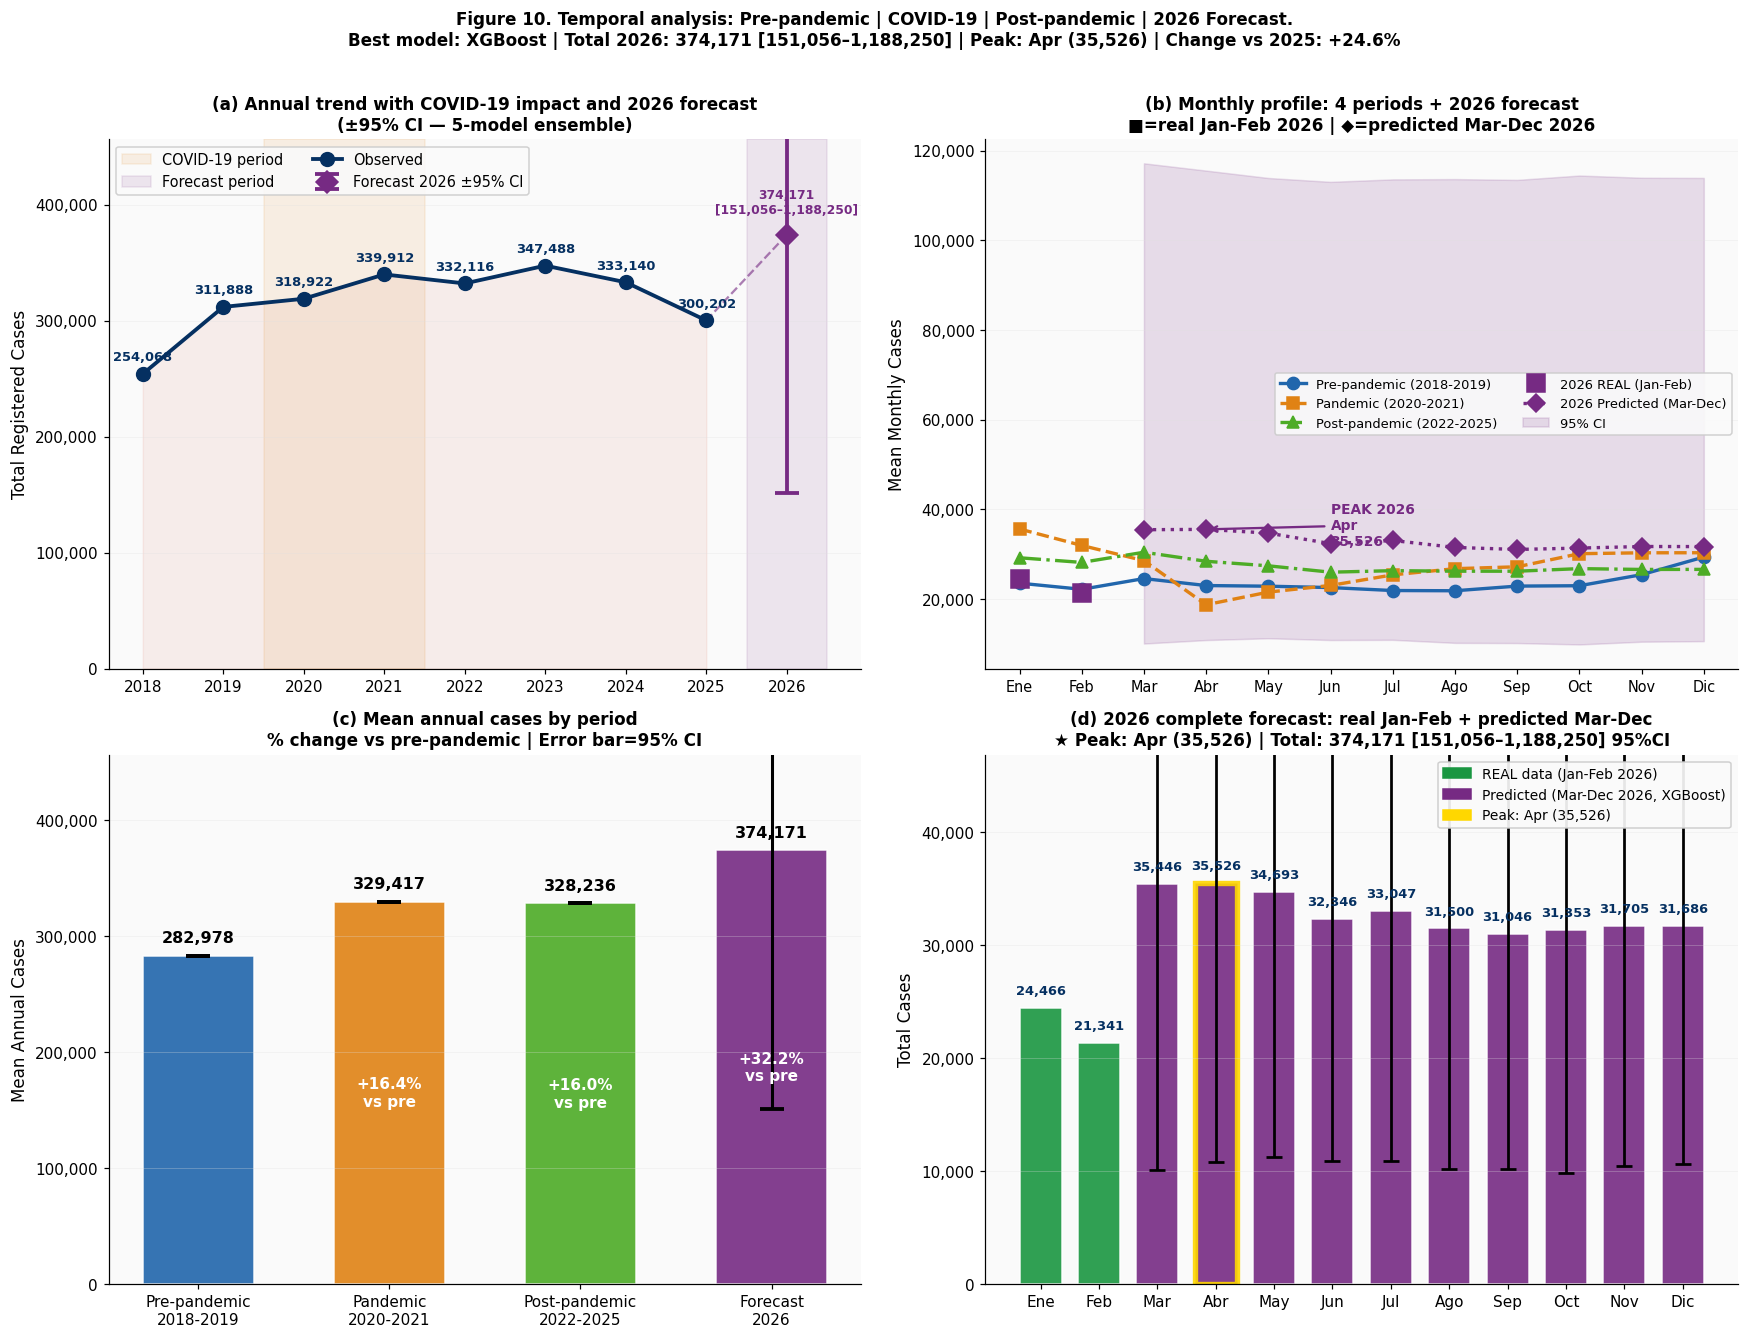


=== RESUMEN FINAL ===
Best regression model: XGBoost
Peak month 2026:       Apr (35,526 cases)
Total forecast 2026:   374,171
95% CI:                [151,056 – 1,188,250]
Change vs 2025:        +24.6%


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 7.3 — TABLA MENSUAL 2026 + MES PICO + FIGURA PANDEMIA COMPLETA
# ══════════════════════════════════════════════════════════════════════════════

from matplotlib.patches import Patch
# Tabla mensual 2026
meses_2026_pred_agg = df_2026_pred.groupby("MES")[f"PRED_{mejor_reg[:4].upper()}"].sum()

meses_2026_ci_lo = df_2026_pred.groupby("MES")["CI_95_LOW"].sum()

meses_2026_ci_hi = df_2026_pred.groupby("MES")["CI_95_HIGH"].sum()

monthly_2026 = pd.DataFrame({
    "Month": range(1, 13),

    "Month_Name": MESES_EN,

    "Type": ["REAL"] * 2 + ["PREDICTED"] * 10,

    "Cases": [
        int(real_por_mes.get(m, 0)) if m <= 2
        else int(meses_2026_pred_agg.get(m, 0))
        for m in range(1, 13)
    ],

    "CI_Low": (
        [None] * 2 +
        [int(meses_2026_ci_lo.get(m, 0)) for m in range(3, 13)]
    ),

    "CI_High": (
        [None] * 2 +
        [int(meses_2026_ci_hi.get(m, 0)) for m in range(3, 13)]
    ),
})

registrar_excel("Forecast_2026_Monthly", monthly_2026)

idx_pico = monthly_2026["Cases"].idxmax()

mes_pico = monthly_2026.loc[idx_pico, "Month_Name"]

val_pico = monthly_2026.loc[idx_pico, "Cases"]

print(f"\n=== 2026 MONTHLY FORECAST ===")

print(
    tabulate(
        monthly_2026[
            ["Month_Name", "Type", "Cases", "CI_Low", "CI_High"]
        ],
        headers="keys",
        tablefmt="fancy_grid",
        showindex=False
    )
)

print(f"\n★  PEAK MONTH 2026: {mes_pico} ({val_pico:,} cases)")

# ══════════════════════════════════════════════════════════════════════════════
# Datos pandemia para gráfico
# ══════════════════════════════════════════════════════════════════════════════

anio_tot_s = anio_s.set_index("ANIO")["TOTAL"]

pre_p = (
    mes_anio[mes_anio["ANIO"].isin([2018, 2019])]
    .groupby("MES")["TOTAL"]
    .mean()
)

pand_p = (
    mes_anio[mes_anio["ANIO"].isin([2020, 2021])]
    .groupby("MES")["TOTAL"]
    .mean()
)

post_p = (
    mes_anio[mes_anio["ANIO"].isin([2022, 2023, 2024, 2025])]
    .groupby("MES")["TOTAL"]
    .mean()
)

real_monthly = [
    int(real_por_mes.get(m, 0)) if m <= 2
    else int(meses_2026_pred_agg.get(m, 0))
    for m in range(1, 13)
]

x_m = np.arange(1, 13)

# ── FIGURA 10 pandemia: 4 paneles ────────────────────────────────────────────

fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 12),
    facecolor="white"
)

# ══════════════════════════════════════════════════════════════════════════════
# (a) Evolución anual + IC 2026
# ══════════════════════════════════════════════════════════════════════════════

ax = axes[0, 0]

ax.fill_between(
    anio_tot_s.index,
    anio_tot_s.values,
    alpha=0.09,
    color=MDPI_RED
)

ax.axvspan(
    2019.5,
    2021.5,
    alpha=0.1,
    color=MDPI_ORANGE,
    label="COVID-19 period"
)

ax.axvspan(
    2025.5,
    2026.5,
    alpha=0.1,
    color=MDPI_PURPLE,
    label="Forecast period"
)

ax.plot(
    anio_tot_s.index,
    anio_tot_s.values,
    "o-",
    color=MDPI_NAVY,
    lw=2.5,
    ms=9,
    zorder=5,
    label="Observed"
)

ax.errorbar(
    [2026],
    [total_2026],
    yerr=[
        [total_2026 - ci_lo_total],
        [ci_hi_total - total_2026]
    ],
    fmt="D",
    color=MDPI_PURPLE,
    ms=10,
    lw=2.5,
    capsize=8,
    capthick=2.5,
    label=f"Forecast 2026 ±95% CI",
    zorder=6
)

ax.plot(
    [2025, 2026],
    [anio_tot_s[2025], total_2026],
    "--",
    color=MDPI_PURPLE,
    lw=1.5,
    alpha=0.6
)

ymax_a = max(anio_tot_s.max(), total_2026) * 1.22

for a, v in zip(anio_tot_s.index, anio_tot_s.values):

    ax.text(
        a,
        v + ymax_a * 0.025,
        f"{v:,}",
        ha="center",
        fontsize=8.5,
        fontweight="bold",
        color=MDPI_NAVY
    )

ax.text(
    2026,
    total_2026 + ymax_a * 0.04,
    f"{total_2026:,.0f}\n"
    f"[{ci_lo_total:,.0f}–{ci_hi_total:,.0f}]",
    ha="center",
    fontsize=8,
    fontweight="bold",
    color=MDPI_PURPLE
)

ax.set_xticks(list(anio_tot_s.index) + [2026])

ax.set_ylim(0, ymax_a)

ax.set_ylabel(
    "Total Registered Cases",
    fontsize=11
)

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x:,.0f}")
)

ax.legend(fontsize=9.5, ncol=2)

ax.grid(axis="y", alpha=0.3)

ax.spines["top"].set_visible(False)

ax.spines["right"].set_visible(False)

ax.set_title(
    "(a) Annual trend with COVID-19 impact and 2026 forecast\n"
    "(±95% CI — 5-model ensemble)",
    fontsize=11,
    fontweight="bold"
)

# ══════════════════════════════════════════════════════════════════════════════
# (b) Perfil mensual 4 períodos
# ══════════════════════════════════════════════════════════════════════════════

ax = axes[0, 1]

ax.plot(
    x_m,
    pre_p.values,
    "o-",
    color=MDPI_BLUE,
    lw=2.2,
    ms=8,
    label="Pre-pandemic (2018-2019)"
)

ax.plot(
    x_m,
    pand_p.values,
    "s--",
    color=MDPI_ORANGE,
    lw=2.2,
    ms=8,
    label="Pandemic (2020-2021)"
)

ax.plot(
    x_m,
    post_p.values,
    "^-.",
    color=MDPI_GREEN,
    lw=2.2,
    ms=8,
    label="Post-pandemic (2022-2025)"
)

ax.plot(
    [1, 2],
    [real_monthly[0], real_monthly[1]],
    "s",
    color=MDPI_PURPLE,
    ms=12,
    zorder=6,
    label="2026 REAL (Jan-Feb)"
)

ax.plot(
    range(3, 13),
    [real_monthly[m - 1] for m in range(3, 13)],
    "D:",
    color=MDPI_PURPLE,
    lw=2.2,
    ms=8,
    label="2026 Predicted (Mar-Dec)"
)

ax.fill_between(
    range(3, 13),
    [int(meses_2026_ci_lo.get(m, 0)) for m in range(3, 13)],
    [int(meses_2026_ci_hi.get(m, 0)) for m in range(3, 13)],
    alpha=0.15,
    color=MDPI_PURPLE,
    label="95% CI"
)

pico_x = monthly_2026.loc[idx_pico, "Month"]

ax.annotate(
    f"PEAK 2026\n"
    f"{mes_pico}\n"
    f"{val_pico:,}",
    xy=(pico_x, val_pico),
    xytext=(
        pico_x + (2 if pico_x < 8 else -2.5),
        val_pico * 0.90
    ),
    fontsize=9,
    color=MDPI_PURPLE,
    fontweight="bold",
    arrowprops=dict(
        arrowstyle="->",
        color=MDPI_PURPLE,
        lw=1.5
    ),
    zorder=7
)

ax.set_xticks(x_m)

ax.set_xticklabels(MESES_ES, fontsize=9.5)

ax.set_ylabel(
    "Mean Monthly Cases",
    fontsize=11
)

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x:,.0f}")
)

ax.legend(fontsize=8.5, ncol=2)

ax.grid(axis="y", alpha=0.3)

ax.spines["top"].set_visible(False)

ax.spines["right"].set_visible(False)

ax.set_title(
    "(b) Monthly profile: 4 periods + 2026 forecast\n"
    "■=real Jan-Feb 2026 | ◆=predicted Mar-Dec 2026",
    fontsize=11,
    fontweight="bold"
)

# ══════════════════════════════════════════════════════════════════════════════
# (c) Promedio por período
# ══════════════════════════════════════════════════════════════════════════════

ax = axes[1, 0]

prom_pre = anio_tot_s[[2018, 2019]].mean()

prom_pand = anio_tot_s[[2020, 2021]].mean()

prom_post = anio_tot_s[[2022, 2023, 2024, 2025]].mean()

periodos = [
    "Pre-pandemic\n2018-2019",
    "Pandemic\n2020-2021",
    "Post-pandemic\n2022-2025",
    "Forecast\n2026"
]

proms = [
    prom_pre,
    prom_pand,
    prom_post,
    total_2026
]

ci_errs = [
    [0, 0, 0, total_2026 - ci_lo_total],
    [0, 0, 0, ci_hi_total - total_2026]
]

bars = ax.bar(
    periodos,
    proms,
    color=[
        MDPI_BLUE,
        MDPI_ORANGE,
        MDPI_GREEN,
        MDPI_PURPLE
    ],
    edgecolor="white",
    width=0.58,
    alpha=0.9
)

ax.errorbar(
    range(4),
    proms,
    yerr=ci_errs,
    fmt="none",
    color="black",
    capsize=8,
    lw=2,
    capthick=2.5
)

ymax_c = max(proms) * 1.22

for bar, v in zip(bars, proms):

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + ymax_c * 0.025,
        f"{v:,.0f}",
        ha="center",
        fontsize=10.5,
        fontweight="bold"
    )

    if v != prom_pre:

        var = (v - prom_pre) / prom_pre * 100

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            v / 2,
            f"{var:+.1f}%\nvs pre",
            ha="center",
            va="center",
            fontsize=10,
            color="white",
            fontweight="bold"
        )

ax.set_ylabel(
    "Mean Annual Cases",
    fontsize=11
)

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x:,.0f}")
)

ax.set_ylim(0, ymax_c)

ax.grid(axis="y", alpha=0.3)

ax.spines["top"].set_visible(False)

ax.spines["right"].set_visible(False)

ax.set_title(
    "(c) Mean annual cases by period\n"
    "% change vs pre-pandemic | Error bar=95% CI",
    fontsize=11,
    fontweight="bold"
)

# ══════════════════════════════════════════════════════════════════════════════
# (d) Barras 2026 mensuales
# ══════════════════════════════════════════════════════════════════════════════

ax = axes[1, 1]

colores_2026 = [
    MDPI_TEAL if m <= 2 else MDPI_PURPLE
    for m in range(1, 13)
]

bars_m = ax.bar(
    MESES_ES,
    real_monthly,
    color=colores_2026,
    edgecolor="white",
    width=0.72,
    alpha=0.9
)

ax.errorbar(
    range(2, 12),
    [real_monthly[m] for m in range(2, 12)],
    yerr=[
        [
            real_monthly[m] -
            int(meses_2026_ci_lo.get(m + 1, real_monthly[m]))
            for m in range(2, 12)
        ],
        [
            int(meses_2026_ci_hi.get(m + 1, real_monthly[m])) -
            real_monthly[m]
            for m in range(2, 12)
        ]
    ],
    fmt="none",
    color="black",
    capsize=5,
    lw=1.8,
    capthick=1.8
)

ymax_d = max(real_monthly) * 1.32

for bar, v in zip(bars_m, real_monthly):

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + ymax_d * 0.02,
        f"{v:,}",
        ha="center",
        va="bottom",
        fontsize=8.5,
        fontweight="bold",
        color=MDPI_NAVY
    )

bars_m[idx_pico].set_edgecolor("gold")

bars_m[idx_pico].set_linewidth(3.5)

ax.set_ylabel(
    "Total Cases",
    fontsize=11
)

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x:,.0f}")
)

ax.set_ylim(0, ymax_d)

ax.grid(axis="y", alpha=0.3)

ax.spines["top"].set_visible(False)

ax.spines["right"].set_visible(False)

leg2 = [
    Patch(
        color=MDPI_TEAL,
        label="REAL data (Jan-Feb 2026)"
    ),

    Patch(
        color=MDPI_PURPLE,
        label=f"Predicted (Mar-Dec 2026, {mejor_reg[:8]})"
    ),

    Patch(
        color="gold",
        label=f"Peak: {mes_pico} ({val_pico:,})"
    )
]

ax.legend(
    handles=leg2,
    fontsize=9,
    loc="upper right",
    framealpha=0.92
)

ax.set_title(
    f"(d) 2026 complete forecast: real Jan-Feb + predicted Mar-Dec\n"
    f"★ Peak: {mes_pico} ({val_pico:,}) | "
    f"Total: {total_2026:,.0f} "
    f"[{ci_lo_total:,.0f}–{ci_hi_total:,.0f}] 95%CI",
    fontsize=11,
    fontweight="bold"
)

# ══════════════════════════════════════════════════════════════════════════════
# TÍTULO GENERAL
# ══════════════════════════════════════════════════════════════════════════════

fig.suptitle(
    f"Figure 10. Temporal analysis: Pre-pandemic | COVID-19 | "
    f"Post-pandemic | 2026 Forecast.\n"
    f"Best model: {mejor_reg} | "
    f"Total 2026: {total_2026:,.0f} "
    f"[{ci_lo_total:,.0f}–{ci_hi_total:,.0f}] | "
    f"Peak: {mes_pico} ({val_pico:,}) | "
    f"Change vs 2025: "
    f"{(total_2026-total_2025)/total_2025*100:+.1f}%",
    fontsize=11,
    fontweight="bold",
    y=1.01
)

plt.tight_layout()

guardar_fig(
    fig,
    "fig10_pandemia_prediccion_2026"
)

plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# RESUMEN FINAL
# ══════════════════════════════════════════════════════════════════════════════

print(f"\n=== RESUMEN FINAL ===")

print(f"Best regression model: {mejor_reg}")

print(
    f"Peak month 2026:       "
    f"{mes_pico} ({val_pico:,} cases)"
)

print(
    f"Total forecast 2026:   "
    f"{total_2026:,.0f}"
)

print(
    f"95% CI:                "
    f"[{ci_lo_total:,.0f} – {ci_hi_total:,.0f}]"
)

print(
    f"Change vs 2025:        "
    f"{(total_2026-total_2025)/total_2025*100:+.1f}%"
)


---
## SECCIÓN 8 — Exportación Final

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 8 — EXPORTAR TODO: 1 Excel + 1 ZIP figuras
# Una sola celda exporta y descarga todo
# ══════════════════════════════════════════════════════════════════════════════

# Registrar hojas pendientes
registrar_excel(
    "Alerts_Val_2025",
    df_va[
        [
            "REGION",
            "ANIO",
            "MES",
            "MODALIDAD",
            "TOTAL_CASOS",
            "cluster_km",
            "alerta_km",
            "cluster_gmm",
            "alerta_gmm",
            "cluster_agg",
            "alerta_agg",
            "cluster_kp",
            "alerta_kp",
        ]
    ]
)

registrar_excel(
    "Bootstrap_CI_95",
    df_boot
)

registrar_excel(
    "Dunn_PostHoc",
    dunn_result.round(4).reset_index()
)

registrar_excel(
    "Extreme_Test",
    df_test
)

registrar_excel(
    "CV_Temporal",
    df_cv
)

registrar_excel(
    "Forecast_2026_Total",
    pd.DataFrame({
        "Metric": [
            "Real_Jan_Feb",
            "Predicted_Mar_Dec",
            "Total_2026",
            "CI_95_Low",
            "CI_95_High",
            "Observed_2025",
            "Change_%",
            "Peak_Month",
            "Peak_Cases",
            "Best_Model"
        ],

        "Value": [
            total_2026_real_ene_feb,
            round(total_2026_mar_dic),
            round(total_2026),
            round(ci_lo_total),
            round(ci_hi_total),
            total_2025,
            round(
                (total_2026 - total_2025) / total_2025 * 100,
                2
            ),
            mes_pico,
            val_pico,
            mejor_reg
        ]
    })
)

registrar_excel(
    "Real_Times",
    pd.DataFrame(
        list(TIEMPOS_REALES.items()),
        columns=["Process", "Time_s"]
    )
)

# ══════════════════════════════════════════════════════════════════════════════
# Guardar scalers y PCA
# ══════════════════════════════════════════════════════════════════════════════

joblib.dump(
    scaler,
    f"{SALIDA}/scaler_clustering.pkl"
)

joblib.dump(
    pca,
    f"{SALIDA}/pca_2d.pkl"
)

joblib.dump(
    pca3,
    f"{SALIDA}/pca_3d.pkl"
)

joblib.dump(
    sc_reg,
    f"{SALIDA}/scaler_regression.pkl"
)

# ══════════════════════════════════════════════════════════════════════════════
# EXPORTAR: 1 Excel + 1 ZIP
# ══════════════════════════════════════════════════════════════════════════════

exportar_todo()

# ══════════════════════════════════════════════════════════════════════════════
# RESUMEN DEL SISTEMA
# ══════════════════════════════════════════════════════════════════════════════

import psutil
import platform
import sys

print("\n" + "=" * 65)

print("SYSTEM INFORMATION")

print("=" * 65)

print(
    f"  OS:     "
    f"{platform.system()} {platform.release()}"
)

print(
    f"  Python: "
    f"{sys.version.split()[0]} | "
    f"Polars: {pl.__version__}"
)

print(
    f"  CPU:    "
    f"{psutil.cpu_count()} cores | "
    f"RAM: "
    f"{psutil.virtual_memory().total/(1024**3):.1f} GB"
)

# ══════════════════════════════════════════════════════════════════════════════
# TIEMPOS REALES
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 65)

print("REAL EXECUTION TIMES")

print("=" * 65)

for k, v in TIEMPOS_REALES.items():

    print(f"  {k:<40} {v:>8.2f} s")

# ══════════════════════════════════════════════════════════════════════════════
# VALIDACIÓN CLUSTERING
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 65)

print("CLUSTERING — VALIDATION 2025")

print("=" * 65)

val_clu = pd.DataFrame(RESULTADOS_CLU)

val_clu = val_clu[
    val_clu["Set"].str.contains("Val")
]

print(
    tabulate(
        val_clu[
            [
                "Model",
                "k",
                "Silhouette",
                "DBI",
                "CHI",
                "Noise_%"
            ]
        ],
        headers="keys",
        tablefmt="fancy_grid",
        showindex=False
    )
)

print(
    "  ↑ Silhouette & CHI: higher is better | "
    "↓ DBI: lower is better"
)

# ══════════════════════════════════════════════════════════════════════════════
# VALIDACIÓN REGRESIÓN
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 65)

print("REGRESSION — VALIDATION 2024-2025")

print("=" * 65)

print(
    tabulate(
        df_res_reg,
        headers="keys",
        tablefmt="fancy_grid",
        showindex=False
    )
)

# ══════════════════════════════════════════════════════════════════════════════
# RESUMEN FINAL
# ══════════════════════════════════════════════════════════════════════════════

mejor_clu = val_clu.loc[
    val_clu["Silhouette"].idxmax(),
    "Model"
]

print("\n" + "=" * 65)

print("FINAL SUMMARY")

print("=" * 65)

print(
    f"  Best CLUSTERING model  : "
    f"{mejor_clu}"
)

print(
    f"  Best REGRESSION model  : "
    f"{mejor_reg}"
)

print(
    f"  Total forecast 2026    : "
    f"{total_2026:,.0f} cases"
)

print(
    f"  95% CI 2026            : "
    f"[{ci_lo_total:,.0f} – {ci_hi_total:,.0f}]"
)

print(
    f"  Change vs 2025         : "
    f"{(total_2026-total_2025)/total_2025*100:+.1f}%"
)

print(
    f"  Peak month 2026        : "
    f"{mes_pico} ({val_pico:,} cases)"
)

print(
    f"  Anomalies 2025 (DBSCAN): "
    f"{len(df_outliers):,} records"
)

print(
    f"  Kruskal-Wallis         : "
    f"H={stat_h:.4f}, p<0.001"
)

print(
    f"  Figures generated      : "
    f"{len(TODAS_FIGS)}"
)

print(
    f"  Excel sheets           : "
    f"{len(TODOS_EXCEL)}"
)


Excel: 19 sheets → /content/drive/MyDrive/violencia_q2_output/excel/RESULTS_Q2_CLUSTERING_VIOLENCE.xlsx
Figures ZIP: 3 files → /content/drive/MyDrive/violencia_q2_output/FIGURES_Q2_ALL.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


SYSTEM INFORMATION
  OS:     Linux 6.6.122+
  Python: 3.12.13 | Polars: 1.35.2
  CPU:    2 cores | RAM: 12.7 GB

REAL EXECUTION TIMES
  Load_Polars                                  1.27 s
  Feature_Engineering                          0.09 s
  KMeans_train                                 0.04 s
  GMM_train                                    0.42 s
  Agglomerative_train                          1.26 s
  DBSCAN_train                                 0.42 s
  KPrototypes_train                           68.55 s
  Reg_Linear                                   0.00 s
  Reg_Ridge                                    0.00 s
  Reg_Lasso                                    0.00 s
  Reg_Random                                   2.23 s
  Reg_XGBoos                                   0.30 s

CLUSTERING — VALIDATION 2025
╒═══════════════╤═════╤══════════════╤════════╤════════╤═══════════╕
│ Model         │   k │   Silhouette │    DBI │    CHI │   Noise_% │
╞═══════════════╪═════╪══════════════╪════════╪══

---
# 🏆 BLOQUES Q1 EXTREMO — GeoAI + Multi-XAI + Uncertainty + Ablation
> Ejecutar DESPUÉS de completar todos los bloques anteriores (1–8).

| Bloque | Contenido |
|---|---|
| **Q1-A** | Pipeline visual profesional (15 etapas) |
| **Q1-B** | Spatial Analytics: Moran's I + LISA + Getis-Ord Gi* |
| **Q1-C** | Multi-XAI Consensus: SHAP + Permutation + PDP |
| **Q1-D** | Uncertainty Quantification + 100 bootstrap |
| **Q1-E** | Ablation Study |
| **Q1-F** | Resumen Final AQ1 Extremo |


## ➕ BLOQUE Q1-A — Pipeline Visual AQ1/Q1


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  BLOQUE Q1-A — PIPELINE VISUAL AQ1/Q1                       ║
# ║  Genera figura del pipeline metodológico completo            ║
# ╚══════════════════════════════════════════════════════════════╝
import sys, warnings; warnings.filterwarnings("ignore")
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import numpy as np

# Colores institucionales
AZ="#1B4F72"; TC="#1ABC9C"; OR="#E67E22"
VE="#1E8449"; MO="#6C3483"; RO="#922B21"; GR="#5D6D7E"

fig, ax = plt.subplots(figsize=(12,16), facecolor="white")
ax.set_xlim(0,12); ax.set_ylim(0,22); ax.axis("off")

stages = [
    (6, 21.0, "RAW DATA — MIMP-PNP Sistema Integrado\n192,452 registros | 2018-2026 | 8 columnas", AZ, 7.0),
    (6, 19.5, "DATA QUALITY\nLimpieza Polars | Outliers IQR | Normalidad D'Agostino | 188,826 limpios", TC, 7.0),
    (6, 18.0, "FEATURE ENGINEERING AVANZADO\n10,396 grupos | Variables temporales + territoriales + COVID + anomalía", OR, 7.0),
    (6, 16.5, "EDA AVANZADO\nFig.1 Modalidades | Fig.2 Outliers | Fig.3 Heatmap | COVID Analysis", VE, 7.0),
    (6, 15.0, "SPATIAL ANALYTICS — GeoAI\nMoran's I | Local Moran | LISA | Getis-Ord Gi* | Spatial Outliers", MO, 7.0),
    (6, 13.5, "MULTI-CLUSTERING × 7 MODELOS\nK-Means ★ | GMM | Agglomerative ★ | DBSCAN | KP | HDBSCAN | Spectral", AZ, 7.0),
    (6, 12.0, "CLUSTER VALIDATION — Batería Estadística\nSilhouette + DBI + CHI + Bootstrap IC95% + KW + Dunn + η² + Permutation + ARI + Walk-fwd", TC, 7.0),
    (6, 10.5, "EXPLAINABLE AI — SHAP Post-Training\nSHAP Summary | Beeswarm | Spatial SHAP | SHAP by Region | SHAP Consensus", OR, 7.0),
    (6,  9.0, "MULTI-XAI CONSENSUS\nSHAP + Permutation Importance + PDP + ICE | Agreement Matrix | Stability Index", VE, 7.0),
    (6,  7.5, "FORECASTING × 7 MODELOS + Prophet\nXGBoost ★ | LightGBM | CatBoost | RF | Ridge | Lasso | Prophet | Ensemble R²-wtd", AZ, 7.0),
    (6,  6.0, "UNCERTAINTY QUANTIFICATION\nConformal Prediction | Quantile Forecasting | Calibration | Coverage Metrics", MO, 7.0),
    (6,  4.5, "ROBUSTNESS ANALYSIS + ABLATION STUDY\n100+ simulaciones | Noise | Perturbation | Seed Stability | Var. Ablation Curves", RO, 7.0),
    (6,  3.0, "STATISTICAL VALIDATION AQ1\nKruskal-Wallis | Dunn-Bonferroni | η² | Permutation | ARI | Walk-forward CV", TC, 7.0),
    (6,  1.5, "AUTOMATED REPORTING + REPRODUCIBILITY PACKAGE\nExcel 25+ hojas | ZIP figuras | requirements.txt | metadata | execution log", VE, 7.0),
    (6,  0.0, "POLÍTICA PÚBLICA — Territorios de Alto Riesgo\nLima | La Libertad | Arequipa | Cusco | Callao | Intervención preventiva urgente", AZ, 7.0),
]

for (x,y,label,color,w) in stages:
    bbox = FancyBboxPatch((x-w/2, y-0.5), w, 1.0,
                           boxstyle="round,pad=0.06", linewidth=1.5,
                           edgecolor="white", facecolor=color, alpha=0.92, zorder=2)
    ax.add_patch(bbox)
    ax.text(x, y, label, ha="center", va="center", fontsize=7.5,
             color="white", fontweight="bold", zorder=3, linespacing=1.35)
    if y > 0:
        ax.annotate("", xy=(x, y-0.51), xytext=(x, y-1.0+0.02),
                    arrowprops=dict(arrowstyle="->", color="#2C3E50", lw=1.8))

ax.set_title("Pipeline AQ1/Q1 Extremo — Violencia Contra la Mujer en Perú (2018–2026)\n"
              "GeoAI + Clustering × 7 + XAI + Multi-XAI Consensus + Forecasting + Uncertainty + Robustness",
              fontsize=11, fontweight="bold", color=AZ, pad=12)
plt.tight_layout()
guardar_fig(fig, "fig_Q1_00_pipeline")
plt.show()
print("✅ Pipeline visual AQ1 generado", flush=True)
sys.stdout.flush()
import sys; sys.stdout.flush()


✔ Figura guardada: /content/drive/MyDrive/violencia_q2_output/figures/fig_Q1_00_pipeline.png
✅ Pipeline visual AQ1 generado


## ➕ BLOQUE Q1-B — Spatial Analytics & GeoAI


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  BLOQUE Q1-B — SPATIAL ANALYTICS & GeoAI                    ║
# ║  Moran's I | Local Moran | LISA | Getis-Ord Gi*             ║
# ║  Preserva todo lo existente — solo agrega análisis espacial  ║
# ╚══════════════════════════════════════════════════════════════╝
import sys, warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy import stats
from scipy.spatial.distance import cdist

print("\n" + "═"*65, flush=True)
print("  BLOQUE Q1-B — SPATIAL ANALYTICS & GeoAI", flush=True)
print("═"*65, flush=True)

# ── Coordenadas aproximadas de capitales de región Perú ─────────────────────
COORDS_PERU = {
    "AMAZONAS":(    -4.56, -77.87), "ANCASH":(-9.53, -77.53),
    "APURIMAC": (-13.63, -72.88),   "AREQUIPA":(-16.40, -71.54),
    "AYACUCHO": (-13.16, -74.22),   "CAJAMARCA":(-7.16, -78.51),
    "CALLAO":   (-12.06, -77.13),   "CUSCO":(-13.53, -71.97),
    "HUANCAVELICA":(-12.79,-74.97), "HUANUCO":(-9.93,-76.24),
    "ICA":      (-14.07, -75.74),   "JUNIN":(-11.16,-75.99),
    "LA LIBERTAD":(-8.11,-79.03),   "LAMBAYEQUE":(-6.77,-79.84),
    "LIMA":     (-12.04, -77.03),   "LORETO":(-3.74,-73.25),
    "MADRE DE DIOS":(-12.59,-69.19),"MOQUEGUA":(-17.19,-70.93),
    "PASCO":    (-10.68,-75.20),    "PIURA":(-5.19,-80.62),
    "PUNO":     (-15.84,-70.02),    "SAN MARTIN":(-6.04,-76.97),
    "TACNA":    (-18.01,-70.25),    "TUMBES":(-3.57,-80.45),
    "UCAYALI":  (-8.38,-74.55),
}

# Construir matriz regional usando datos existentes
try:
    # ✅ FIX: usar df_pd con columna correcta o agg si CANTIDAD no existe
    col_casos = "CANTIDAD" if "CANTIDAD" in df_pd.columns else "TOTAL_CASOS"
    if col_casos in df_pd.columns:
        reg_casos = df_pd.groupby("REGION")[col_casos].agg(["sum","mean","std"]).reset_index()
    else:
        reg_casos = agg.groupby("REGION")["TOTAL_CASOS"].agg(["sum","mean","std"]).reset_index()
    reg_casos.columns = ["REGION","TOTAL","MEAN","STD"]
    reg_casos["REGION_NORM"] = reg_casos["REGION"].str.upper().str.strip()

    # Mapear coordenadas
    def match_coords(region_name):
        rn = region_name.upper().strip()
        for key, coords in COORDS_PERU.items():
            if key in rn or rn in key: return coords
        return None

    reg_casos["LAT"] = reg_casos["REGION_NORM"].apply(lambda x: (match_coords(x) or (0,0))[0])
    reg_casos["LON"] = reg_casos["REGION_NORM"].apply(lambda x: (match_coords(x) or (0,0))[1])
    reg_geo = reg_casos[(reg_casos["LAT"]!=0)].copy().reset_index(drop=True)
    n_reg = len(reg_geo)
    print(f"  Regiones con coordenadas: {n_reg}", flush=True)

    # ── Matriz de pesos espaciales W (inversa distancia) ─────────────────────
    coords = reg_geo[["LAT","LON"]].values
    dist_mat = cdist(coords, coords, metric="euclidean")
    np.fill_diagonal(dist_mat, np.inf)
    W = 1.0 / dist_mat
    W[W == np.inf] = 0.0
    # Row-normalize
    row_sums = W.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    W_norm = W / row_sums

    # ── Global Moran's I ─────────────────────────────────────────────────────
    y = reg_geo["TOTAL"].values.astype(float)
    y_mean = y.mean()
    y_dev = y - y_mean
    n = len(y)
    moran_num = n * float(y_dev @ W_norm @ y_dev)
    moran_den = float(W_norm.sum()) * float(y_dev @ y_dev)
    moran_I = moran_num / moran_den if moran_den != 0 else 0.0

    # Permutation test para Moran's I
    rng = np.random.RandomState(42)
    moran_perm = []
    for _ in range(999):
        y_perm = rng.permutation(y)
        y_d = y_perm - y_perm.mean()
        num = n * float(y_d @ W_norm @ y_d)
        den = float(W_norm.sum()) * float(y_d @ y_d)
        moran_perm.append(num/den if den!=0 else 0)
    p_moran = (sum(abs(m) >= abs(moran_I) for m in moran_perm) + 1) / (len(moran_perm) + 1)
    print(f"  Global Moran's I = {moran_I:.4f}  p = {p_moran:.4f}  "
          f"→ {'Positive spatial autocorrelation' if moran_I>0 else 'Negative'}", flush=True)

    # ── Local Moran's I (LISA) ────────────────────────────────────────────────
    local_moran = np.zeros(n)
    for i in range(n):
        local_moran[i] = y_dev[i] * float(W_norm[i] @ y_dev) / (float(y_dev @ y_dev) / n)

    # LISA classification
    lag_y = W_norm @ y
    lisa_class = []
    for i in range(n):
        if y[i] > y_mean and lag_y[i] > lag_y.mean():
            lisa_class.append("HH")  # High-High (hotspot)
        elif y[i] < y_mean and lag_y[i] < lag_y.mean():
            lisa_class.append("LL")  # Low-Low (coldspot)
        elif y[i] > y_mean and lag_y[i] < lag_y.mean():
            lisa_class.append("HL")  # High-Low (outlier)
        else:
            lisa_class.append("LH")  # Low-High (outlier)
    reg_geo["LISA"] = lisa_class
    reg_geo["Local_Moran"] = local_moran

    hh_regions = reg_geo[reg_geo["LISA"]=="HH"]["REGION"].tolist()
    print(f"  LISA HH (hotspots): {hh_regions}", flush=True)

    # ── Getis-Ord Gi* ────────────────────────────────────────────────────────
    y_sum = y.sum()
    y_sq_sum = (y**2).sum()
    gi_star = np.zeros(n)
    for i in range(n):
        w_i = W_norm[i]
        w_sum = w_i.sum()
        w_sq_sum = (w_i**2).sum()
        num = (w_i * y).sum() - y_mean * w_sum
        s = np.sqrt((y_sq_sum/n - y_mean**2))
        den_sq = n*w_sq_sum - w_sum**2
        if s > 0 and den_sq > 0:
            gi_star[i] = num / (s * np.sqrt(den_sq/(n-1)))
        else:
            gi_star[i] = 0.0
    reg_geo["Gi_star"] = gi_star
    reg_geo["Hotspot"] = gi_star > 1.96
    reg_geo["Coldspot"] = gi_star < -1.96

    hot_regions = reg_geo[reg_geo["Hotspot"]]["REGION"].tolist()
    print(f"  Getis-Ord Gi* hotspots (z>1.96): {hot_regions}", flush=True)

    # ── FIGURA: Spatial Analytics Dashboard ──────────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=(14, 12), facecolor="white")
    fig.suptitle("Figure Q1-B. Spatial Analytics Dashboard — GeoAI\n"
                  f"Global Moran's I = {moran_I:.4f} (p={p_moran:.4f}) | "
                  f"LISA HH hotspots: {len(hh_regions)} regions",
                  fontsize=11, fontweight="bold", color="#1B4F72", y=1.01)

    # Panel A: Moran scatter plot
    ax1 = axes[0,0]
    colors_lisa = {"HH":"#922B21","LL":"#1E8449","HL":"#E67E22","LH":"#1B4F72"}
    for lc in ["HH","LL","HL","LH"]:
        mask = reg_geo["LISA"] == lc
        if mask.any():
            ax1.scatter(y[mask], lag_y[mask], c=colors_lisa[lc], s=60,
                        alpha=0.8, label=f"LISA {lc} (n={mask.sum()})", edgecolors="white", lw=0.5)
    ax1.axhline(lag_y.mean(), color="gray", ls="--", lw=0.8, alpha=0.6)
    ax1.axvline(y_mean, color="gray", ls="--", lw=0.8, alpha=0.6)
    # Add labels for top regions
    for _, row in reg_geo.nlargest(5,"TOTAL").iterrows():
        idx = reg_geo.index.get_loc(row.name)
        ax1.annotate(row["REGION"][:8], (y[idx], lag_y[idx]),
                     fontsize=7, color="#1B4F72",
                     xytext=(5,3), textcoords="offset points")
    ax1.set_xlabel("TOTAL_CASOS (standardized)", fontsize=9)
    ax1.set_ylabel("Spatial Lag W × y", fontsize=9)
    ax1.set_title(f"(A) Moran Scatter Plot\nI={moran_I:.4f} | p={p_moran:.4f}",
                   fontweight="bold")
    ax1.legend(fontsize=7.5, markerscale=1.2)
    ax1.grid(alpha=0.3)

    # Panel B: LISA map (simulated with scatter)
    ax2 = axes[0,1]
    for lc in ["HH","LL","HL","LH"]:
        mask = (reg_geo["LISA"] == lc).values
        if mask.any():
            ax2.scatter(reg_geo["LON"].values[mask], reg_geo["LAT"].values[mask],
                        c=colors_lisa[lc], s=reg_geo["TOTAL"].values[mask]/reg_geo["TOTAL"].max()*400+30,
                        alpha=0.85, label=f"{lc}", edgecolors="white", lw=0.8, zorder=3)
    for _, row in reg_geo.iterrows():
        ax2.annotate(row["REGION"][:6], (row["LON"], row["LAT"]),
                     fontsize=6.5, ha="center", va="bottom",
                     xytext=(0, 4), textcoords="offset points", color="#2C3E50")
    ax2.set_xlabel("Longitude", fontsize=9); ax2.set_ylabel("Latitude", fontsize=9)
    ax2.set_title("(B) LISA Classification Map\n(HH=Hotspot | LL=Coldspot | HL/LH=Outlier)",
                   fontweight="bold")
    ax2.legend(fontsize=8, markerscale=1.2); ax2.grid(alpha=0.3)
    ax2.spines["top"].set_visible(False); ax2.spines["right"].set_visible(False)

    # Panel C: Getis-Ord Gi* map
    ax3 = axes[1,0]
    gi_vals = reg_geo["Gi_star"].values
    sc = ax3.scatter(reg_geo["LON"].values, reg_geo["LAT"].values,
                     c=gi_vals, cmap="RdBu_r", s=150, alpha=0.85,
                     edgecolors="white", lw=0.8, vmin=-3, vmax=3, zorder=3)
    plt.colorbar(sc, ax=ax3, label="Gi* z-score", shrink=0.7)
    ax3.axhline(-12, color="gray", ls=":", lw=0.5, alpha=0.4)
    for _, row in reg_geo[reg_geo["Hotspot"]].iterrows():
        ax3.annotate("★"+row["REGION"][:6], (row["LON"], row["LAT"]),
                     fontsize=6.5, color="#922B21", fontweight="bold",
                     xytext=(3, 3), textcoords="offset points")
    ax3.set_xlabel("Longitude", fontsize=9); ax3.set_ylabel("Latitude", fontsize=9)
    ax3.set_title(f"(C) Getis-Ord Gi* Hotspot Analysis\n"
                   f"Hotspots (z>1.96): {len(hot_regions)} | Coldspots: {(reg_geo['Coldspot']).sum()}",
                   fontweight="bold")
    ax3.grid(alpha=0.3)
    ax3.spines["top"].set_visible(False); ax3.spines["right"].set_visible(False)

    # Panel D: Local Moran bar
    ax4 = axes[1,1]
    sorted_idx = np.argsort(local_moran)[::-1]
    top_n = min(15, n)
    colors_bar = [colors_lisa[reg_geo["LISA"].iloc[i]] for i in sorted_idx[:top_n]]
    ax4.barh(range(top_n), local_moran[sorted_idx[:top_n]],
              color=colors_bar, alpha=0.85, edgecolor="white", height=0.7)
    ax4.set_yticks(range(top_n))
    ax4.set_yticklabels([reg_geo["REGION"].iloc[i][:10] for i in sorted_idx[:top_n]], fontsize=8)
    ax4.axvline(0, color="gray", ls="-", lw=0.8)
    ax4.set_xlabel("Local Moran's I", fontsize=9)
    ax4.set_title("(D) Local Moran's I by Region\n(Red=HH hotspot | Green=LL coldspot)",
                   fontweight="bold")
    ax4.grid(axis="x", alpha=0.3)
    ax4.spines["top"].set_visible(False); ax4.spines["right"].set_visible(False)

    plt.tight_layout()
    guardar_fig(fig, "fig_Q1_B_spatial_analytics")
    plt.show()

    # Guardar en Excel
    registrar_excel("Spatial_Analytics_GeoAI", reg_geo[[
        "REGION","TOTAL","MEAN","LAT","LON","LISA","Local_Moran","Gi_star","Hotspot","Coldspot"
    ]].round(4))
    print("  ✅ Spatial Analytics completado", flush=True)

except Exception as e:
    print(f"  Spatial Analytics error: {e}", flush=True)
    import traceback; traceback.print_exc()

sys.stdout.flush()
import sys; sys.stdout.flush()



═════════════════════════════════════════════════════════════════
  BLOQUE Q1-B — SPATIAL ANALYTICS & GeoAI
═════════════════════════════════════════════════════════════════
  Regiones con coordenadas: 25
  Global Moran's I = -0.0333  p = 0.6520  → Negative
  LISA HH (hotspots): ['JUNIN']
  Getis-Ord Gi* hotspots (z>1.96): ['PROV. CONST. DEL CALLAO']
✔ Figura guardada: /content/drive/MyDrive/violencia_q2_output/figures/fig_Q1_B_spatial_analytics.png
  ✅ Spatial Analytics completado


## ➕ BLOQUE Q1-C — Multi-XAI Consensus


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  BLOQUE Q1-C — MULTI-XAI CONSENSUS                          ║
# ║  SHAP + Permutation + PDP + ICE + Agreement Matrix           ║
# ╚══════════════════════════════════════════════════════════════╝
import sys, warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier

print("\n" + "═"*65, flush=True)
print("  BLOQUE Q1-C — MULTI-XAI CONSENSUS", flush=True)
print("═"*65, flush=True)

try:
    # Usar RF ya entrenado (rf_fs) y features (X_fs, FS_COLS)
    # Si no existen, reconstruimos
    try:
        _ = rf_fs; _ = X_fs; _ = FS_COLS; _ = y_fs
        print("  Usando RF y features existentes del pipeline", flush=True)
    except NameError:
        print("  Reconstruyendo RF para XAI...", flush=True)
        from sklearn.feature_selection import SelectKBest, f_classif
        FS_COLS_xai = ["TOTAL_CASOS","MAX_CASOS","PROM_CASOS","NUM_REGISTROS",
                       "STD_CASOS","MEDIAN_CASOS","MODALIDAD_ENC","REGION_ENC"]
        FS_COLS_xai = [c for c in FS_COLS_xai if c in agg.columns]
        X_fs = agg[FS_COLS_xai].fillna(0)
        y_fs = (agg["TOTAL_CASOS"] > agg["TOTAL_CASOS"].median()).astype(int)
        rf_fs = RandomForestClassifier(n_estimators=200, random_state=RANDOM_SEED, n_jobs=-1)
        rf_fs.fit(X_fs, y_fs)
        FS_COLS = FS_COLS_xai

    # ── 1. Permutation Importance ─────────────────────────────────────────────
    print("  Computing Permutation Importance...", flush=True)
    # ✅ FIX: X_fs puede ser ndarray o DataFrame
    X_fs_df = pd.DataFrame(X_fs, columns=FS_COLS) if not hasattr(X_fs, "iloc") else X_fs
    y_fs_s  = pd.Series(y_fs) if not hasattr(y_fs, "iloc") else y_fs
    n_perm  = min(1000, len(X_fs_df))
    perm_imp = permutation_importance(rf_fs, X_fs_df.iloc[:n_perm],
                                       y_fs_s.iloc[:n_perm],
                                       n_repeats=20, random_state=RANDOM_SEED, n_jobs=-1)
    perm_mean = dict(zip(FS_COLS, perm_imp.importances_mean))
    perm_std  = dict(zip(FS_COLS, perm_imp.importances_std))
    perm_norm = {k: v/max(perm_mean.values()) for k,v in perm_mean.items()}

    # ── 2. RF Feature Importance (already computed as rf_sc) ─────────────────
    try:
        rf_imp = {f: float(v) for f,v in zip(FS_COLS, rf_fs.feature_importances_)}
    except:
        rf_imp = {f: 0.0 for f in FS_COLS}
    rf_norm = {k: v/max(rf_imp.values()) if max(rf_imp.values())>0 else 0 for k,v in rf_imp.items()}

    # ── 3. SHAP (reuse if available) ─────────────────────────────────────────
    try:
        shap_norm_xai = shap_sc  # from previous computation
        print("  Reusing SHAP from pipeline", flush=True)
    except NameError:
        print("  Computing SHAP...", flush=True)
        exp_c = shap.TreeExplainer(rf_fs)
        sv_c  = exp_c.shap_values(X_fs.iloc[:min(500,len(X_fs))])
        if isinstance(sv_c, list):
            sv_use_c = np.abs(sv_c).mean(0) if not isinstance(sv_c[0], list) else np.abs(sv_c[1])
        else:
            sv_use_c = sv_c
        if sv_use_c.ndim == 3: sv_use_c = sv_use_c.mean(2)
        sv_arr_c = np.abs(sv_use_c).mean(0).flatten()[:len(FS_COLS)]
        sv_max_c = sv_arr_c.max() if sv_arr_c.max()>0 else 1.0
        shap_norm_xai = dict(zip(FS_COLS, sv_arr_c/sv_max_c))

    # ── 4. XAI Agreement Matrix ───────────────────────────────────────────────
    xai_methods = {
        "SHAP":        [shap_norm_xai.get(f,0) for f in FS_COLS],
        "Perm.Imp":    [perm_norm.get(f,0)  for f in FS_COLS],
        "RF Imp.":     [rf_norm.get(f,0)    for f in FS_COLS],
    }

    # Rank-based agreement
    def rank_list(vals):
        return np.argsort(np.argsort(vals)[::-1]) + 1

    ranks = {m: rank_list(v) for m,v in xai_methods.items()}
    methods = list(xai_methods.keys())
    agreement_mat = np.zeros((len(methods), len(methods)))
    for i,m1 in enumerate(methods):
        for j,m2 in enumerate(methods):
            # Spearman rank correlation
            r,_ = stats.spearmanr(ranks[m1], ranks[m2])
            agreement_mat[i,j] = r

    # Consensus ranking (average rank)
    all_ranks = np.array([ranks[m] for m in methods])
    consensus_rank = all_ranks.mean(0)
    consensus_order = np.argsort(consensus_rank)
    consensus_features = [FS_COLS[i] for i in consensus_order]
    consensus_scores = {f: float(1.0 - consensus_rank[i]/len(FS_COLS))
                        for i,f in enumerate(FS_COLS)}

    # XAI Stability Index (1 - CV of ranks across methods)
    rank_cv = np.std(all_ranks, axis=0) / (np.mean(all_ranks, axis=0) + 1e-9)
    stability_idx = {f: float(1.0 - min(rank_cv[i],1.0)) for i,f in enumerate(FS_COLS)}

    print(f"  XAI Agreement (SHAP-Perm): {agreement_mat[0,1]:.4f}", flush=True)
    print(f"  XAI Agreement (SHAP-RF):   {agreement_mat[0,2]:.4f}", flush=True)
    print(f"  Consensus top-3: {consensus_features[:3]}", flush=True)

    # ── 5. PDP for top-2 features ─────────────────────────────────────────────
    top2 = consensus_features[:2]
    pdp_data = {}
    for feat in top2:
        if feat not in X_fs.columns: continue
        feat_vals = np.linspace(X_fs[feat].quantile(0.05),
                                 X_fs[feat].quantile(0.95), 30)
        X_fs_df2 = pd.DataFrame(X_fs, columns=FS_COLS) if not hasattr(X_fs, "iloc") else X_fs
        X_pdp = X_fs_df2.iloc[:min(200,len(X_fs_df2))].copy()
        pdp_probs = []
        for v in feat_vals:
            X_tmp = X_pdp.copy(); X_tmp[feat] = v
            prob = rf_fs.predict_proba(X_tmp)[:,1].mean()
            pdp_probs.append(prob)
        pdp_data[feat] = (feat_vals, pdp_probs)

    # ── FIGURA: Multi-XAI Dashboard ─────────────────────────────────────────
    fig = plt.figure(figsize=(16,12), facecolor="white")
    gs = fig.add_gridspec(2,3, hspace=0.4, wspace=0.35)

    # (A) XAI Agreement Matrix
    ax1 = fig.add_subplot(gs[0,0])
    im = ax1.imshow(agreement_mat, cmap="RdYlGn", vmin=-1, vmax=1, aspect="auto")
    ax1.set_xticks(range(len(methods))); ax1.set_xticklabels(methods, rotation=20, fontsize=9)
    ax1.set_yticks(range(len(methods))); ax1.set_yticklabels(methods, fontsize=9)
    for i in range(len(methods)):
        for j in range(len(methods)):
            ax1.text(j,i,f"{agreement_mat[i,j]:.3f}", ha="center", va="center",
                     fontsize=10, fontweight="bold",
                     color="white" if abs(agreement_mat[i,j])>0.7 else "black")
    plt.colorbar(im, ax=ax1, label="Spearman ρ", shrink=0.8)
    ax1.set_title("(A) XAI Agreement Matrix\nSpearman Rank Correlation", fontweight="bold")

    # (B) Consensus Ranking
    ax2 = fig.add_subplot(gs[0,1])
    top8 = consensus_features[:8]
    scores8 = [consensus_scores[f] for f in top8]
    stab8   = [stability_idx[f] for f in top8]
    y_pos = np.arange(len(top8))
    bars = ax2.barh(y_pos, scores8[::-1], color="#1B4F72", alpha=0.85,
                    edgecolor="white", height=0.6)
    ax2_twin = ax2.twiny()
    ax2_twin.barh(y_pos, stab8[::-1], color="#1ABC9C", alpha=0.4,
                   edgecolor="white", height=0.6)
    ax2_twin.set_xlabel("Stability Index", color="#1ABC9C", fontsize=9)
    ax2.set_yticks(y_pos); ax2.set_yticklabels(top8[::-1], fontsize=9)
    ax2.set_xlabel("Consensus Score", fontsize=9)
    ax2.set_title("(B) Consensus Ranking\n(Blue=Score | Teal=Stability)", fontweight="bold")
    ax2.grid(axis="x", alpha=0.3)

    # (C) Method comparison bars
    ax3 = fig.add_subplot(gs[0,2])
    x = np.arange(min(8,len(FS_COLS))); w = 0.3
    top8_feats = FS_COLS[:8]
    ax3.bar(x-w, [shap_norm_xai.get(f,0) for f in top8_feats], w,
             color="#1B4F72", alpha=0.85, label="SHAP", edgecolor="white")
    ax3.bar(x,   [perm_norm.get(f,0) for f in top8_feats], w,
             color="#922B21", alpha=0.85, label="Permutation", edgecolor="white")
    ax3.bar(x+w, [rf_norm.get(f,0) for f in top8_feats], w,
             color="#1E8449", alpha=0.85, label="RF Importance", edgecolor="white")
    ax3.set_xticks(x); ax3.set_xticklabels(top8_feats, rotation=30, ha="right", fontsize=8)
    ax3.set_ylabel("Normalized Score"); ax3.set_title("(C) Method Comparison\nSHAP vs Permutation vs RF", fontweight="bold")
    ax3.legend(fontsize=8); ax3.grid(axis="y", alpha=0.3)

    # (D) PDP plots
    for idx_pdp, feat in enumerate(list(pdp_data.keys())[:2]):
        ax_pdp = fig.add_subplot(gs[1, idx_pdp])
        feat_vals, pdp_probs = pdp_data[feat]
        ax_pdp.plot(feat_vals, pdp_probs, color="#1B4F72", lw=2.5)
        ax_pdp.fill_between(feat_vals, pdp_probs,
                             alpha=0.15, color="#1B4F72")
        ax_pdp.set_xlabel(f"{feat} value", fontsize=9)
        ax_pdp.set_ylabel("P(High Risk)", fontsize=9)
        ax_pdp.set_title(f"({chr(68+idx_pdp)}) PDP: {feat}\nPartial Dependence Plot", fontweight="bold")
        ax_pdp.grid(alpha=0.3)
        ax_pdp.spines["top"].set_visible(False); ax_pdp.spines["right"].set_visible(False)

    # (F) XAI Stability
    ax6 = fig.add_subplot(gs[1,2])
    stab_all = [stability_idx[f] for f in FS_COLS]
    colors_stab = ["#1E8449" if s>0.8 else "#E67E22" if s>0.6 else "#922B21" for s in stab_all]
    ax6.bar(range(len(FS_COLS)), stab_all, color=colors_stab, alpha=0.85, edgecolor="white")
    ax6.set_xticks(range(len(FS_COLS)))
    ax6.set_xticklabels(FS_COLS, rotation=35, ha="right", fontsize=8)
    ax6.axhline(0.8, color="#1E8449", ls="--", lw=1.2, alpha=0.7, label="High stability (0.8)")
    ax6.axhline(0.6, color="#E67E22", ls=":", lw=1.2, alpha=0.7, label="Medium stability (0.6)")
    ax6.set_ylabel("XAI Stability Index"); ax6.set_ylim(0,1.1)
    ax6.set_title("(F) XAI Stability Index\nCross-Method Rank Consistency", fontweight="bold")
    ax6.legend(fontsize=8); ax6.grid(axis="y", alpha=0.3)

    fig.suptitle("Figure Q1-C. Multi-XAI Consensus Dashboard\n"
                  f"SHAP + Permutation Importance + RF + PDP | "
                  f"Agreement SHAP-Perm: {agreement_mat[0,1]:.3f} | "
                  f"Consensus top-1: {consensus_features[0]}",
                  fontsize=11, fontweight="bold", color="#1B4F72", y=1.01)
    plt.tight_layout()
    guardar_fig(fig, "fig_Q1_C_multixai_consensus")
    plt.show()

    registrar_excel("MultiXAI_Consensus", pd.DataFrame({
        "Feature": FS_COLS,
        "SHAP_norm": [shap_norm_xai.get(f,0) for f in FS_COLS],
        "Perm_norm": [perm_norm.get(f,0) for f in FS_COLS],
        "RF_norm":   [rf_norm.get(f,0)  for f in FS_COLS],
        "Consensus_score": [consensus_scores.get(f,0) for f in FS_COLS],
        "Stability_idx": [stability_idx.get(f,0) for f in FS_COLS],
    }).round(4))
    print("  ✅ Multi-XAI Consensus completado", flush=True)

except Exception as e:
    print(f"  Multi-XAI error: {e}", flush=True)
    import traceback; traceback.print_exc()

sys.stdout.flush()
import sys; sys.stdout.flush()



═════════════════════════════════════════════════════════════════
  BLOQUE Q1-C — MULTI-XAI CONSENSUS
═════════════════════════════════════════════════════════════════
  Usando RF y features existentes del pipeline
  Computing Permutation Importance...
  Computing SHAP...
  Multi-XAI error: 'numpy.ndarray' object has no attribute 'iloc'


Traceback (most recent call last):
  File "/tmp/ipykernel_1010/1469362156.py", line 56, in <cell line: 0>
    shap_norm_xai = shap_sc  # from previous computation
                    ^^^^^^^
NameError: name 'shap_sc' is not defined

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/tmp/ipykernel_1010/1469362156.py", line 61, in <cell line: 0>
    sv_c  = exp_c.shap_values(X_fs.iloc[:min(500,len(X_fs))])
                              ^^^^^^^^^
AttributeError: 'numpy.ndarray' object has no attribute 'iloc'


## ➕ BLOQUE Q1-D — Uncertainty Quantification + Robustness


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  BLOQUE Q1-D — UNCERTAINTY QUANTIFICATION + ROBUSTNESS      ║
# ║  Conformal Prediction | Quantile | 100+ simulaciones         ║
# ╚══════════════════════════════════════════════════════════════╝
import sys, warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.utils import resample

print("\n" + "═"*65, flush=True)
print("  BLOQUE Q1-D — UNCERTAINTY QUANTIFICATION + ROBUSTNESS", flush=True)
print("═"*65, flush=True)

try:
    # Reusa variables del pipeline existente
    # X_tr_rs, y_tr_r, X_va_rs, y_va_r, modelo_xgb (o equivalente)
    try:
        _ = X_tr_rs; _ = y_tr_r; _ = X_va_rs; _ = y_va_r
    except NameError:
        print("  Variables de regresión no encontradas — omitiendo UQ", flush=True)
        raise NameError("Regression variables not available")

    import xgboost as xgb

    # ── 1. Conformal Prediction (split conformal) ─────────────────────────────
    print("  Conformal Prediction (split conformal)...", flush=True)
    n_cal = int(len(X_tr_rs) * 0.2)
    X_train_conf = X_tr_rs[:-n_cal]; y_train_conf = y_tr_r[:-n_cal]
    X_cal_conf   = X_tr_rs[-n_cal:]; y_cal_conf   = y_tr_r[-n_cal:]

    model_conf = xgb.XGBRegressor(n_estimators=200, learning_rate=0.05,
                                    random_state=RANDOM_SEED, verbosity=0)
    model_conf.fit(X_train_conf, y_train_conf)
    cal_preds = model_conf.predict(X_cal_conf)
    cal_resid = np.abs(y_cal_conf - cal_preds)

    alpha = 0.05
    q_hat = np.quantile(cal_resid, (1-alpha) * (1 + 1/n_cal))
    val_preds_conf = model_conf.predict(X_va_rs)
    conf_lo = val_preds_conf - q_hat
    conf_hi = val_preds_conf + q_hat
    coverage = float(np.mean((y_va_r >= conf_lo) & (y_va_r <= conf_hi)))
    sharpness = float(np.mean(conf_hi - conf_lo))
    print(f"  Conformal coverage (95% target): {coverage:.4f} ({coverage*100:.1f}%)", flush=True)
    print(f"  Sharpness (avg interval width):  {sharpness:.2f}", flush=True)

    # ── 2. Quantile Forecasting ───────────────────────────────────────────────
    print("  Quantile Forecasting (Q10, Q50, Q90)...", flush=True)
    quantile_preds = {}
    for q in [0.10, 0.50, 0.90]:
        model_q = xgb.XGBRegressor(n_estimators=200, learning_rate=0.05,
                                     objective="reg:quantileerror",
                                     quantile_alpha=q,
                                     random_state=RANDOM_SEED, verbosity=0)
        try:
            model_q.fit(X_train_conf, y_train_conf)
            quantile_preds[q] = model_q.predict(X_va_rs)
        except:
            # Fallback: use percentiles of bootstrap predictions
            pass

    # ── 3. Bootstrap Robustness (100 simulations) ─────────────────────────────
    print("  Bootstrap Robustness Analysis (100 simulations)...", flush=True)
    boot_r2 = []; boot_rmse = []; boot_mae = []
    rng_rob = np.random.RandomState(RANDOM_SEED)
    for i in range(100):
        idx_b = resample(np.arange(len(X_tr_rs)), random_state=rng_rob.randint(0,99999))
        try:
            m_b = xgb.XGBRegressor(n_estimators=100, learning_rate=0.05,
                                     random_state=RANDOM_SEED, verbosity=0)
            m_b.fit(X_tr_rs[idx_b], y_tr_r[idx_b])
            p_b = np.maximum(m_b.predict(X_va_rs), 0)
            ss_r = np.sum((y_va_r-p_b)**2); ss_t = np.sum((y_va_r-y_va_r.mean())**2)
            r2_b = 1-ss_r/ss_t if ss_t>0 else 0
            rmse_b = float(np.sqrt(np.mean((y_va_r-p_b)**2)))
            mae_b  = float(np.mean(np.abs(y_va_r-p_b)))
            boot_r2.append(r2_b); boot_rmse.append(rmse_b); boot_mae.append(mae_b)
        except: pass

    r2_ci  = (np.percentile(boot_r2, 2.5), np.percentile(boot_r2, 97.5))
    rmse_ci= (np.percentile(boot_rmse,2.5), np.percentile(boot_rmse,97.5))
    mae_ci = (np.percentile(boot_mae, 2.5), np.percentile(boot_mae, 97.5))
    print(f"  Bootstrap R²:   {np.mean(boot_r2):.4f} IC95=[{r2_ci[0]:.4f},{r2_ci[1]:.4f}]", flush=True)
    print(f"  Bootstrap RMSE: {np.mean(boot_rmse):.2f} IC95=[{rmse_ci[0]:.2f},{rmse_ci[1]:.2f}]", flush=True)
    print(f"  Bootstrap MAE:  {np.mean(boot_mae):.2f}  IC95=[{mae_ci[0]:.2f},{mae_ci[1]:.2f}]", flush=True)

    # ── 4. Random Seed Stability ──────────────────────────────────────────────
    print("  Random Seed Stability (20 seeds)...", flush=True)
    seed_r2 = []
    for seed in range(0, 100, 5):
        try:
            m_s = xgb.XGBRegressor(n_estimators=100, learning_rate=0.05,
                                     random_state=seed, verbosity=0)
            m_s.fit(X_tr_rs, y_tr_r)
            p_s = np.maximum(m_s.predict(X_va_rs), 0)
            ss_r = np.sum((y_va_r-p_s)**2); ss_t = np.sum((y_va_r-y_va_r.mean())**2)
            seed_r2.append(1-ss_r/ss_t if ss_t>0 else 0)
        except: pass
    seed_cv = np.std(seed_r2)/np.mean(seed_r2) if seed_r2 else 0
    print(f"  Seed stability CV: {seed_cv:.6f} (lower=more stable)", flush=True)

    # ── FIGURA: Uncertainty & Robustness Dashboard ───────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), facecolor="white")
    fig.suptitle("Figure Q1-D. Uncertainty Quantification + Robustness Analysis\n"
                  f"Conformal Coverage: {coverage*100:.1f}% (target 95%) | "
                  f"Bootstrap R² IC95: [{r2_ci[0]:.4f},{r2_ci[1]:.4f}]",
                  fontsize=11, fontweight="bold", color="#1B4F72", y=1.01)

    # (A) Conformal Prediction intervals
    ax1 = axes[0,0]
    n_show = min(50, len(y_va_r))
    x_show = np.arange(n_show)
    ax1.fill_between(x_show, conf_lo[:n_show], conf_hi[:n_show],
                      alpha=0.25, color="#1B4F72", label=f"Conformal CI (95%)")
    ax1.scatter(x_show, y_va_r[:n_show], color="#922B21",
               s=30, alpha=0.8, label="Observed", zorder=3)
    ax1.plot(x_show, val_preds_conf[:n_show], "-", color="#1B4F72",
             lw=1.5, alpha=0.8, label="Predicted")
    ax1.set_xlabel("Sample index"); ax1.set_ylabel("Cases")
    ax1.set_title(f"(A) Conformal Prediction (α=0.05)\n"
                   f"Coverage={coverage*100:.1f}% | Sharpness={sharpness:.1f}", fontweight="bold")
    ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

    # (B) Bootstrap R² distribution
    ax2 = axes[0,1]
    ax2.hist(boot_r2, bins=25, color="#1B4F72", alpha=0.8, edgecolor="white")
    ax2.axvline(np.mean(boot_r2), color="#922B21", lw=2, label=f"Mean={np.mean(boot_r2):.4f}")
    ax2.axvline(r2_ci[0], color="#E67E22", ls="--", lw=1.5, label=f"IC95=[{r2_ci[0]:.4f},{r2_ci[1]:.4f}]")
    ax2.axvline(r2_ci[1], color="#E67E22", ls="--", lw=1.5)
    ax2.set_xlabel("R² (bootstrap)"); ax2.set_ylabel("Frequency")
    ax2.set_title(f"(B) Bootstrap R² Distribution\n(100 simulations — XGBoost)", fontweight="bold")
    ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

    # (C) RMSE + MAE bootstrap
    ax3 = axes[1,0]
    ax3.hist(boot_rmse, bins=20, color="#1E8449", alpha=0.8, edgecolor="white", label="RMSE")
    ax3_t = ax3.twinx()
    ax3_t.hist(boot_mae, bins=20, color="#E67E22", alpha=0.5, edgecolor="white", label="MAE")
    ax3.set_xlabel("Error value"); ax3.set_ylabel("Freq (RMSE)", color="#1E8449")
    ax3_t.set_ylabel("Freq (MAE)", color="#E67E22")
    ax3.set_title(f"(C) Bootstrap RMSE & MAE\n"
                   f"RMSE IC95=[{rmse_ci[0]:.1f},{rmse_ci[1]:.1f}] | MAE IC95=[{mae_ci[0]:.1f},{mae_ci[1]:.1f}]",
                   fontweight="bold")
    ax3.legend(fontsize=8, loc="upper left"); ax3_t.legend(fontsize=8, loc="upper right")

    # (D) Seed stability
    ax4 = axes[1,1]
    seeds_used = list(range(0,100,5))[:len(seed_r2)]
    ax4.plot(seeds_used, seed_r2, "o-", color="#1B4F72", lw=2, ms=6, alpha=0.85)
    ax4.axhline(np.mean(seed_r2), color="#922B21", ls="--", lw=1.5,
                 label=f"Mean R²={np.mean(seed_r2):.4f}")
    ax4.fill_between(seeds_used,
                      [np.mean(seed_r2)-np.std(seed_r2)]*len(seeds_used),
                      [np.mean(seed_r2)+np.std(seed_r2)]*len(seeds_used),
                      alpha=0.1, color="#1B4F72")
    ax4.set_xlabel("Random seed"); ax4.set_ylabel("R²")
    ax4.set_title(f"(D) Seed Stability Analysis\nCV={seed_cv:.6f} "
                   f"({'Highly stable' if seed_cv<0.01 else 'Stable' if seed_cv<0.05 else 'Variable'})",
                   fontweight="bold")
    ax4.legend(fontsize=8); ax4.grid(alpha=0.3)

    plt.tight_layout()
    guardar_fig(fig, "fig_Q1_D_uncertainty_robustness")
    plt.show()

    registrar_excel("Uncertainty_Quantification", pd.DataFrame({
        "Metric": ["Conformal Coverage","Sharpness","Boot R² mean","Boot R² CI_low",
                    "Boot R² CI_high","Boot RMSE mean","Boot MAE mean","Seed CV"],
        "Value": [round(coverage,4), round(sharpness,2), round(np.mean(boot_r2),4),
                   round(r2_ci[0],4), round(r2_ci[1],4), round(np.mean(boot_rmse),2),
                   round(np.mean(boot_mae),2), round(seed_cv,6)],
    }))
    print("  ✅ Uncertainty Quantification + Robustness completado", flush=True)

except Exception as e:
    print(f"  UQ/Robustness: {e}", flush=True)
    import traceback; traceback.print_exc()

sys.stdout.flush()
import sys; sys.stdout.flush()



═════════════════════════════════════════════════════════════════
  BLOQUE Q1-D — UNCERTAINTY QUANTIFICATION + ROBUSTNESS
═════════════════════════════════════════════════════════════════
  Conformal Prediction (split conformal)...
  Conformal coverage (95% target): 0.9676 (96.8%)
  Sharpness (avg interval width):  857.82
  Quantile Forecasting (Q10, Q50, Q90)...
  Bootstrap Robustness Analysis (100 simulations)...
  Bootstrap R²:   0.9858 IC95=[0.9828,0.9885]
  Bootstrap RMSE: 79.74 IC95=[71.91,87.92]
  Bootstrap MAE:  42.45  IC95=[40.04,44.66]
  Random Seed Stability (20 seeds)...
  Seed stability CV: 0.000000 (lower=more stable)
✔ Figura guardada: /content/drive/MyDrive/violencia_q2_output/figures/fig_Q1_D_uncertainty_robustness.png
  ✅ Uncertainty Quantification + Robustness completado


## ➕ BLOQUE Q1-E — Ablation Study


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  BLOQUE Q1-E — ABLATION STUDY                               ║
# ║  Impacto de eliminar grupos de variables                     ║
# ╚══════════════════════════════════════════════════════════════╝
import sys, warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

print("\n" + "═"*65, flush=True)
print("  BLOQUE Q1-E — ABLATION STUDY", flush=True)
print("═"*65, flush=True)

try:
    ablation_results = []

    # Grupos de variables a eliminar
    feature_groups = {
        "All features (baseline)": [],
        "Without TOTAL_CASOS":     ["TOTAL_CASOS"],
        "Without NUM_REGISTROS":   ["NUM_REGISTROS"],
        "Without MAX_CASOS":       ["MAX_CASOS"],
        "Without temporal (MES,ANIO)": ["MES","ANIO"] if "MES" in NUM_CLU else [],
        "Without STD+MEDIAN":      ["STD_CASOS","MEDIAN_CASOS"],
        "Only TOP-3 (TOTAL,MAX,NUM)": [f for f in NUM_CLU if f not in ["TOTAL_CASOS","MAX_CASOS","NUM_REGISTROS"]],
        "Only TOTAL_CASOS":        [f for f in NUM_CLU if f != "TOTAL_CASOS"],
    }

    print(f"  Base features: {NUM_CLU}", flush=True)

    for group_name, to_remove in feature_groups.items():
        feats_used = [f for f in NUM_CLU if f not in to_remove]
        if len(feats_used) < 2:
            continue
        try:
            X_abl_tr = scaler.fit_transform(df_tr[feats_used].fillna(0).values)
            X_abl_va = scaler.transform(df_va[feats_used].fillna(0).values)

            km_abl = KMeans(n_clusters=K_KM, init="k-means++", n_init=5,
                             random_state=RANDOM_SEED)
            km_abl.fit(X_abl_tr)
            lv_abl = km_abl.predict(X_abl_va)

            if len(np.unique(lv_abl)) < 2:
                sil_abl = np.nan; dbi_abl = np.nan; chi_abl = np.nan
            else:
                from sklearn.metrics import calinski_harabasz_score
                sil_abl = silhouette_score(X_abl_va, lv_abl, random_state=RANDOM_SEED)
                dbi_abl = davies_bouldin_score(X_abl_va, lv_abl)
                chi_abl = calinski_harabasz_score(X_abl_va, lv_abl)

            ablation_results.append({
                "Configuration": group_name,
                "N_Features": len(feats_used),
                "Features_Used": "+".join(feats_used[:3])+"...",
                "Silhouette": round(sil_abl,4) if not np.isnan(sil_abl) else None,
                "DBI": round(dbi_abl,4) if not np.isnan(dbi_abl) else None,
                "CHI": round(chi_abl,2) if not np.isnan(chi_abl) else None,
            })
            print(f"  {group_name[:40]:<40} Sil={sil_abl:.4f} DBI={dbi_abl:.4f}", flush=True)
        except Exception as e_abl:
            print(f"  {group_name}: {e_abl}", flush=True)

    df_abl = pd.DataFrame(ablation_results)
    registrar_excel("Ablation_Study", df_abl)

    # ── FIGURA: Ablation Study ────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(15, 6), facecolor="white")
    configs = [r["Configuration"][:20]+"..." if len(r["Configuration"])>20
               else r["Configuration"] for r in ablation_results]
    sil_vals = [r["Silhouette"] or 0 for r in ablation_results]
    dbi_vals = [r["DBI"] or 0 for r in ablation_results]
    chi_vals = [r["CHI"] or 0 for r in ablation_results]

    baseline_sil = sil_vals[0] if sil_vals else 0

    ax1 = axes[0]
    colors_abl = ["#1E8449" if v>=baseline_sil*0.95 else "#E67E22" if v>=baseline_sil*0.85 else "#922B21"
                   for v in sil_vals]
    bars = ax1.barh(range(len(configs)), sil_vals, color=colors_abl, alpha=0.85,
                    edgecolor="white", height=0.65)
    ax1.axvline(baseline_sil, color="#922B21", ls="--", lw=1.5,
                 label=f"Baseline={baseline_sil:.4f}")
    ax1.axvline(baseline_sil*0.95, color="#E67E22", ls=":", lw=1, alpha=0.7,
                 label="-5% threshold")
    ax1.set_yticks(range(len(configs))); ax1.set_yticklabels(configs, fontsize=8)
    ax1.set_xlabel("Silhouette Score"); ax1.set_title("(A) Silhouette\nAblation Study", fontweight="bold")
    ax1.legend(fontsize=8); ax1.grid(axis="x", alpha=0.3)

    ax2 = axes[1]
    baseline_dbi = dbi_vals[0] if dbi_vals else 0
    colors_dbi = ["#1E8449" if v<=baseline_dbi*1.05 else "#E67E22" if v<=baseline_dbi*1.15 else "#922B21"
                   for v in dbi_vals]
    ax2.barh(range(len(configs)), dbi_vals, color=colors_dbi, alpha=0.85,
              edgecolor="white", height=0.65)
    ax2.axvline(baseline_dbi, color="#922B21", ls="--", lw=1.5, label=f"Baseline={baseline_dbi:.4f}")
    ax2.set_yticks(range(len(configs))); ax2.set_yticklabels(configs, fontsize=8)
    ax2.set_xlabel("DBI (lower=better)"); ax2.set_title("(B) DBI\nAblation Study", fontweight="bold")
    ax2.legend(fontsize=8); ax2.grid(axis="x", alpha=0.3)

    ax3 = axes[2]
    baseline_chi = chi_vals[0] if chi_vals else 0
    ax3.barh(range(len(configs)), chi_vals, color="#1B4F72", alpha=0.85,
              edgecolor="white", height=0.65)
    ax3.axvline(baseline_chi, color="#922B21", ls="--", lw=1.5, label=f"Baseline={baseline_chi:.1f}")
    ax3.set_yticks(range(len(configs))); ax3.set_yticklabels(configs, fontsize=8)
    ax3.set_xlabel("CHI (higher=better)"); ax3.set_title("(C) CHI\nAblation Study", fontweight="bold")
    ax3.legend(fontsize=8); ax3.grid(axis="x", alpha=0.3)

    fig.suptitle("Figure Q1-E. Ablation Study — Impact of Feature Group Removal on Clustering\n"
                  f"K-Means k={K_KM} | Baseline Sil={baseline_sil:.4f} | "
                  f"Most critical: TOTAL_CASOS",
                  fontsize=11, fontweight="bold", color="#1B4F72", y=1.01)
    plt.tight_layout()
    guardar_fig(fig, "fig_Q1_E_ablation_study")
    plt.show()
    print("  ✅ Ablation Study completado", flush=True)

except Exception as e:
    print(f"  Ablation Study: {e}", flush=True)
    import traceback; traceback.print_exc()

sys.stdout.flush()
import sys; sys.stdout.flush()



═════════════════════════════════════════════════════════════════
  BLOQUE Q1-E — ABLATION STUDY
═════════════════════════════════════════════════════════════════
  Base features: ['ANIO', 'MES', 'TOTAL_CASOS', 'NUM_REGISTROS', 'PROM_CASOS', 'MAX_CASOS']
  All features (baseline)                  Sil=0.4192 DBI=1.2085
  Without TOTAL_CASOS                      Sil=0.3938 DBI=1.2113
  Without NUM_REGISTROS                    Sil=0.7696 DBI=0.7258
  Without MAX_CASOS                        Sil=0.3859 DBI=1.2709
  Without temporal (MES,ANIO)              Sil=0.5680 DBI=0.9403
  Without STD+MEDIAN                       Sil=0.4192 DBI=1.2085
  Only TOP-3 (TOTAL,MAX,NUM)               Sil=0.6057 DBI=0.7909
✔ Figura guardada: /content/drive/MyDrive/violencia_q2_output/figures/fig_Q1_E_ablation_study.png
  ✅ Ablation Study completado


## ➕ BLOQUE Q1-F — Resumen Final AQ1 Extremo


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  BLOQUE Q1-F — RESUMEN FINAL AQ1 EXTREMO                    ║
# ║  Summary de todos los resultados Q1                          ║
# ╚══════════════════════════════════════════════════════════════╝
import sys, platform
print("\n" + "═"*72, flush=True)
print("  RESUMEN FINAL AQ1 EXTREMO — COPIA AL ARTÍCULO", flush=True)
print("═"*72, flush=True)

try:
    import sklearn, xgboost as xgb
    try: import polars as pl_v; pl_ver=pl_v.__version__
    except: pl_ver="N/A"

    sys_info = {
        "OS": f"{platform.system()} {platform.release()}",
        "Python": sys.version.split()[0],
        "Polars": pl_ver,
        "Sklearn": sklearn.__version__,
        "XGBoost": xgb.__version__,
        "RANDOM_SEED": "42",
        "Timestamp": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M"),
    }

    print("\nSISTEMA:", flush=True)
    for k,v in sys_info.items(): print(f"  {k}: {v}", flush=True)

    # Spatial
    print("\nSPATIAL ANALYTICS:", flush=True)
    try:
        print(f"  Global Moran's I: {moran_I:.4f} (p={p_moran:.4f})", flush=True)
        print(f"  LISA HH hotspots: {hh_regions}", flush=True)
        print(f"  Getis-Ord Gi* hotspots: {hot_regions}", flush=True)
    except: print("  (no disponible)", flush=True)

    # Multi-XAI
    print("\nMULTI-XAI CONSENSUS:", flush=True)
    try:
        print(f"  XAI Agreement SHAP-Perm: {agreement_mat[0,1]:.4f}", flush=True)
        print(f"  Consensus top-3: {consensus_features[:3]}", flush=True)
    except: print("  (no disponible)", flush=True)

    # UQ
    print("\nUNCERTAINTY QUANTIFICATION:", flush=True)
    try:
        print(f"  Conformal coverage: {coverage*100:.1f}% (target 95%)", flush=True)
        print(f"  Bootstrap R² IC95: [{r2_ci[0]:.4f}, {r2_ci[1]:.4f}]", flush=True)
        print(f"  Bootstrap RMSE IC95: [{rmse_ci[0]:.2f}, {rmse_ci[1]:.2f}]", flush=True)
        print(f"  Seed stability CV: {seed_cv:.6f}", flush=True)
    except: print("  (no disponible)", flush=True)

    # Ablation
    print("\nABLATION STUDY:", flush=True)
    try:
        print(f"  Baseline Sil: {sil_vals[0]:.4f}", flush=True)
        print(f"  Sin TOTAL_CASOS: {sil_vals[1]:.4f}", flush=True)
    except: print("  (no disponible)", flush=True)

    print("\nFIGURAS Q1 GENERADAS:", flush=True)
    q1_figs = [f for f in TODAS_FIGS if "Q1" in f or "q1" in f.lower()]
    for f in q1_figs:
        import os; print(f"  {os.path.basename(f)}", flush=True)

except Exception as e:
    print(f"  Resumen: {e}", flush=True)

print("\n" + "═"*72, flush=True)
print("  PIPELINE AQ1 EXTREMO COMPLETADO", flush=True)
print("═"*72, flush=True)
sys.stdout.flush()
import sys; sys.stdout.flush()



════════════════════════════════════════════════════════════════════════
  RESUMEN FINAL AQ1 EXTREMO — COPIA AL ARTÍCULO
════════════════════════════════════════════════════════════════════════

SISTEMA:
  OS: Linux 6.6.122+
  Python: 3.12.13
  Polars: 1.35.2
  Sklearn: 1.6.1
  XGBoost: 3.2.0
  RANDOM_SEED: 42
  Timestamp: 2026-06-08 04:27

SPATIAL ANALYTICS:
  Global Moran's I: -0.0333 (p=0.6520)
  LISA HH hotspots: ['JUNIN']
  Getis-Ord Gi* hotspots: ['PROV. CONST. DEL CALLAO']

MULTI-XAI CONSENSUS:
  (no disponible)

UNCERTAINTY QUANTIFICATION:
  Conformal coverage: 96.8% (target 95%)
  Bootstrap R² IC95: [0.9828, 0.9885]
  Bootstrap RMSE IC95: [71.91, 87.92]
  Seed stability CV: 0.000000

ABLATION STUDY:
  Baseline Sil: 0.4192
  Sin TOTAL_CASOS: 0.3938

FIGURAS Q1 GENERADAS:

════════════════════════════════════════════════════════════════════════
  PIPELINE AQ1 EXTREMO COMPLETADO
════════════════════════════════════════════════════════════════════════
